# CARI-GAN: Constraint-Aware Relational Integrity GAN
## A Business-Rule-Guided Synthetic Data Framework for Salesforce Sandbox Environments



---

**Part 1 — EDA:** Cells 1–46  
**Part 2 — Modelling & Evaluation:** Cells 47–72


All libraries loaded successfully.
Pandas version  : 2.3.3
NumPy  version  : 2.0.2
Files available in dataset directory:
   olist_customers_dataset.csv
   olist_geolocation_dataset.csv
   olist_order_items_dataset.csv
   olist_order_payments_dataset.csv
   olist_order_reviews_dataset.csv
   olist_orders_dataset.csv
   olist_products_dataset.csv
   olist_sellers_dataset.csv
   product_category_name_translation.csv
All tables loaded.
  customers        rows= 99,441  cols=  5
  orders           rows= 99,441  cols=  8
  order_items      rows=112,650  cols=  7
  sellers          rows=  3,095  cols=  4
  payments         rows=103,886  cols=  5
  products         rows= 32,951  cols=  9
  reviews          rows= 99,224  cols=  7
  product_trans    rows=     71  cols=  2
TABLE: CUSTOMERS
  Shape : (99441, 5)
  Dtypes:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype

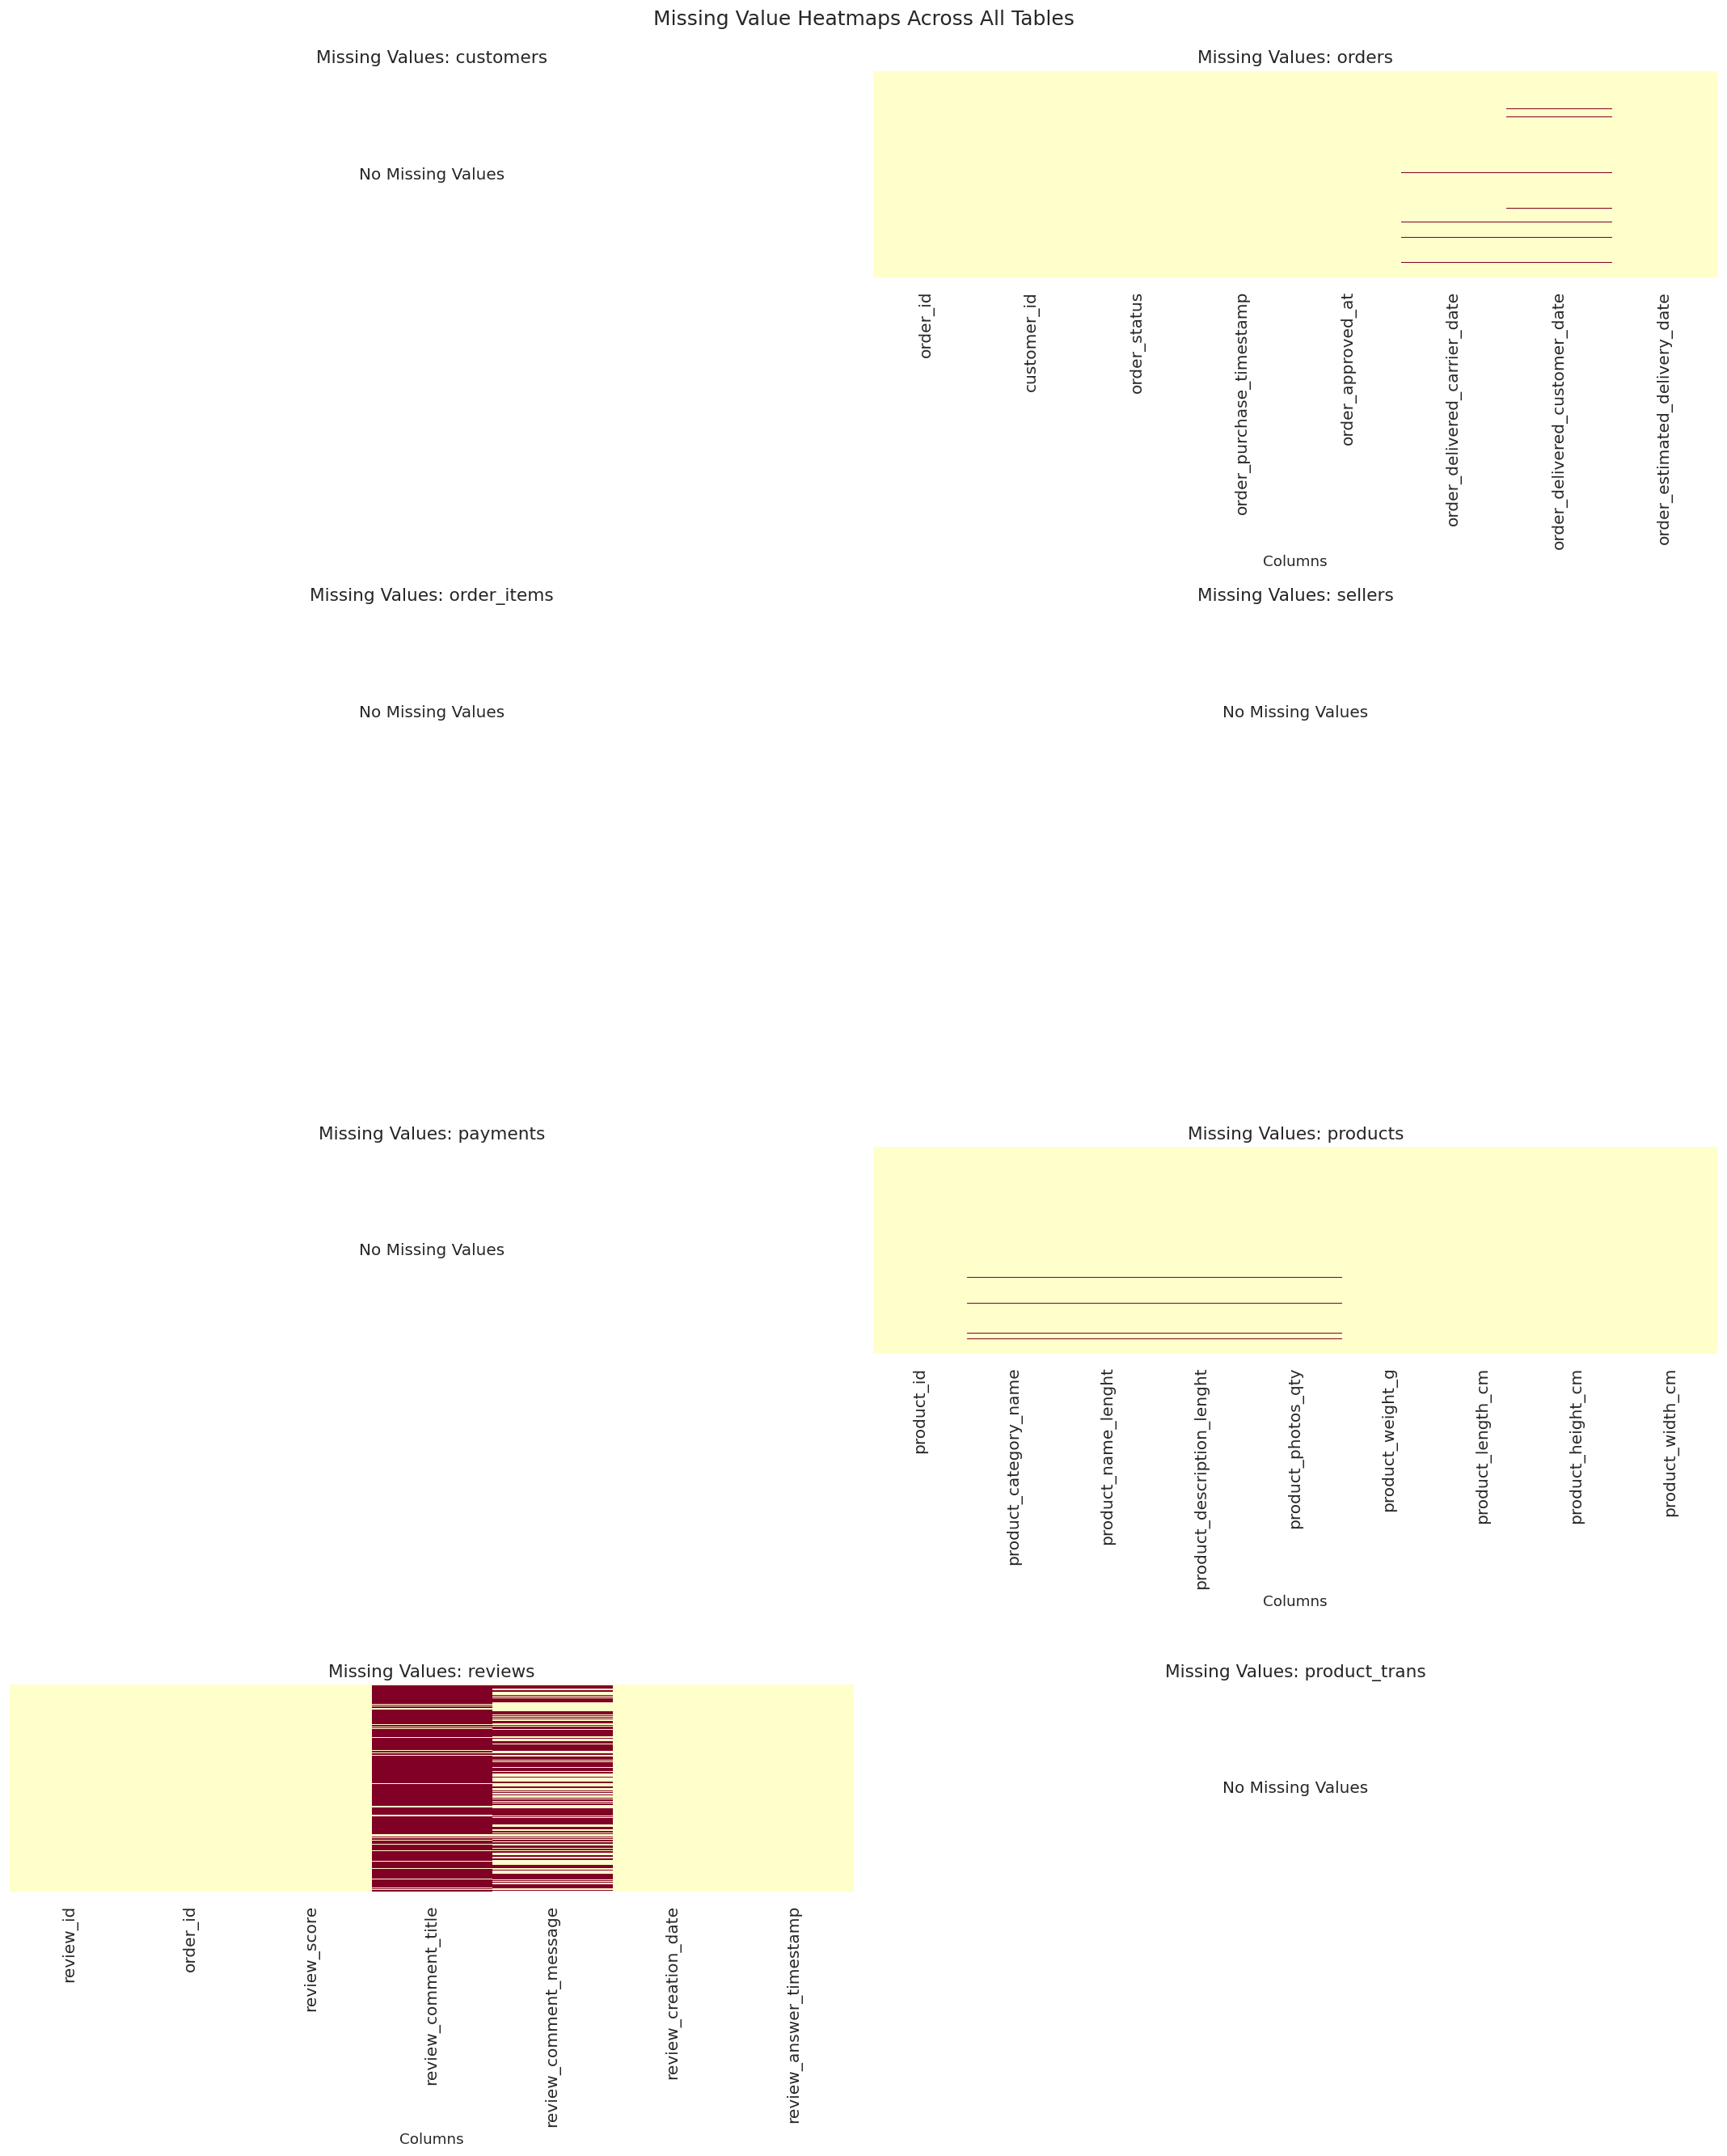

Figure saved: missing_heatmaps.png
Duplicate Row Analysis
----------------------------------------
  customers        duplicates =     0
  orders           duplicates =     0
  order_items      duplicates =     0
  sellers          duplicates =     0
  payments         duplicates =     0
  products         duplicates =     0
  reviews          duplicates =     0
  product_trans    duplicates =     0
[customers]
       customer_zip_code_prefix
count                 99441.000
mean                  35137.475
std                   29797.939
min                    1003.000
25%                   11347.000
50%                   24416.000
75%                   58900.000
max                   99990.000

[orders]  No numeric columns.

[order_items]
       order_item_id       price  freight_value
count     112650.000  112650.000     112650.000
mean           1.198     120.654         19.990
std            0.705     183.634         15.806
min            1.000       0.850          0.000
25%        

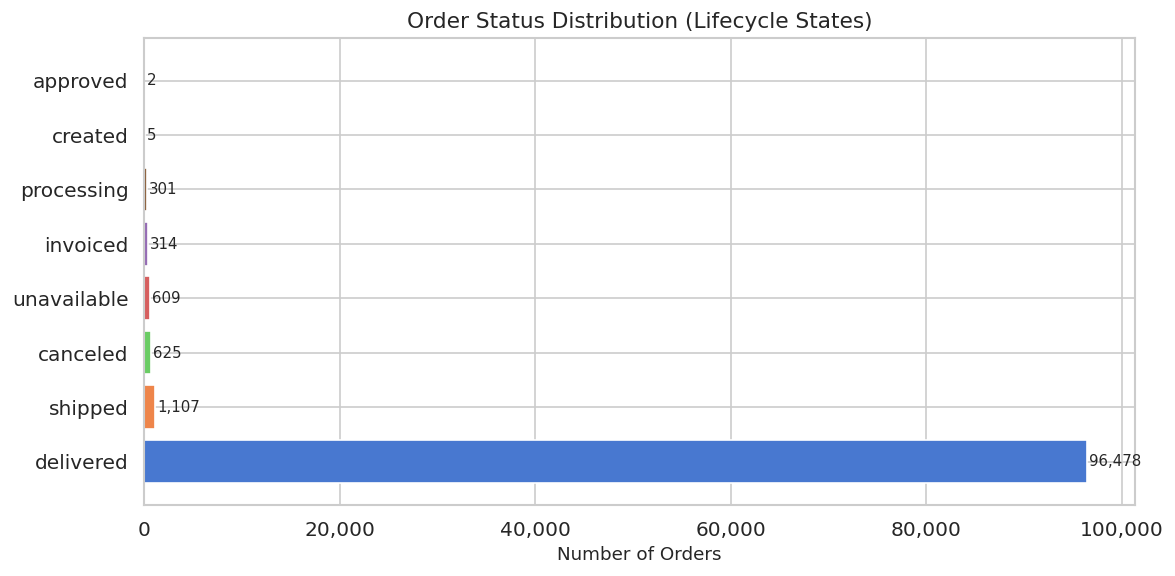

Figure saved: order_status_distribution.png


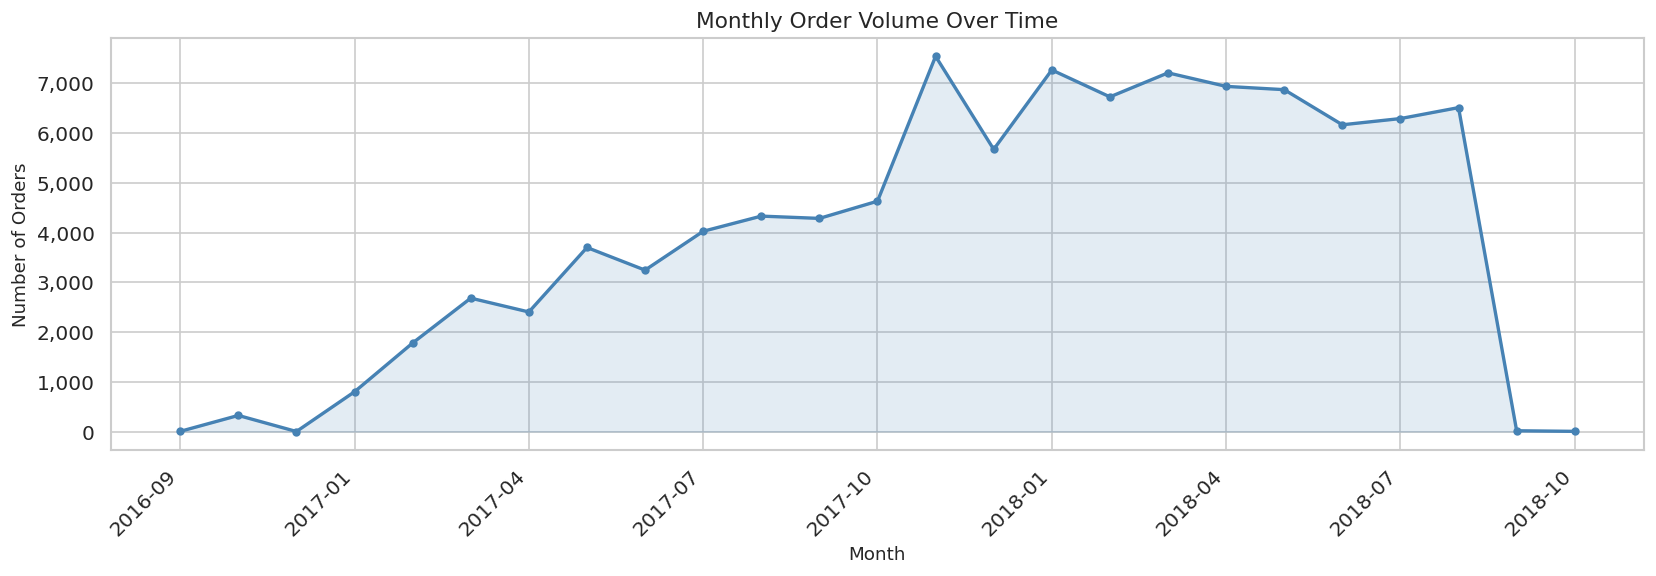

Figure saved: monthly_order_volume.png


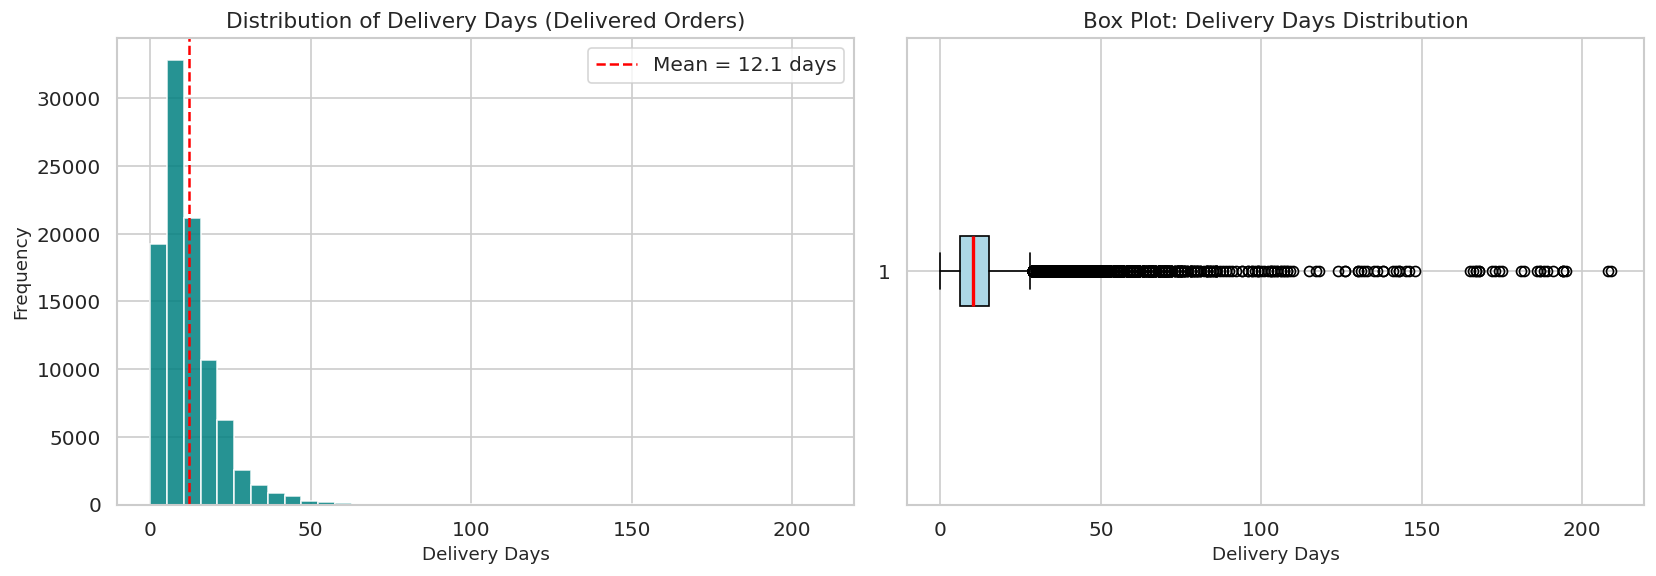

Figure saved: delivery_time_analysis.png


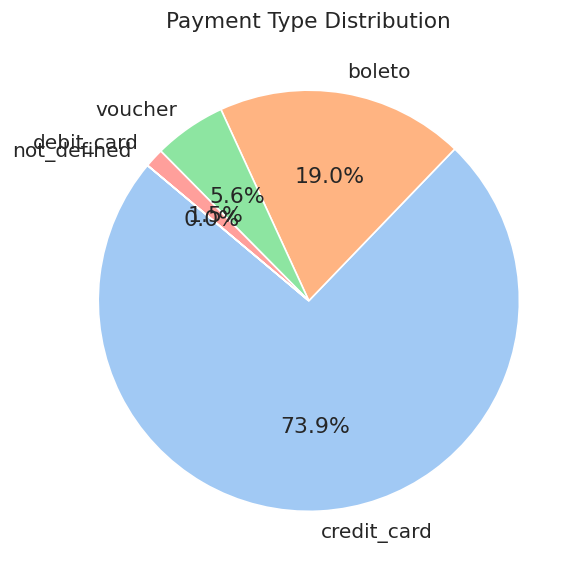

Figure saved: payment_type_distribution.png


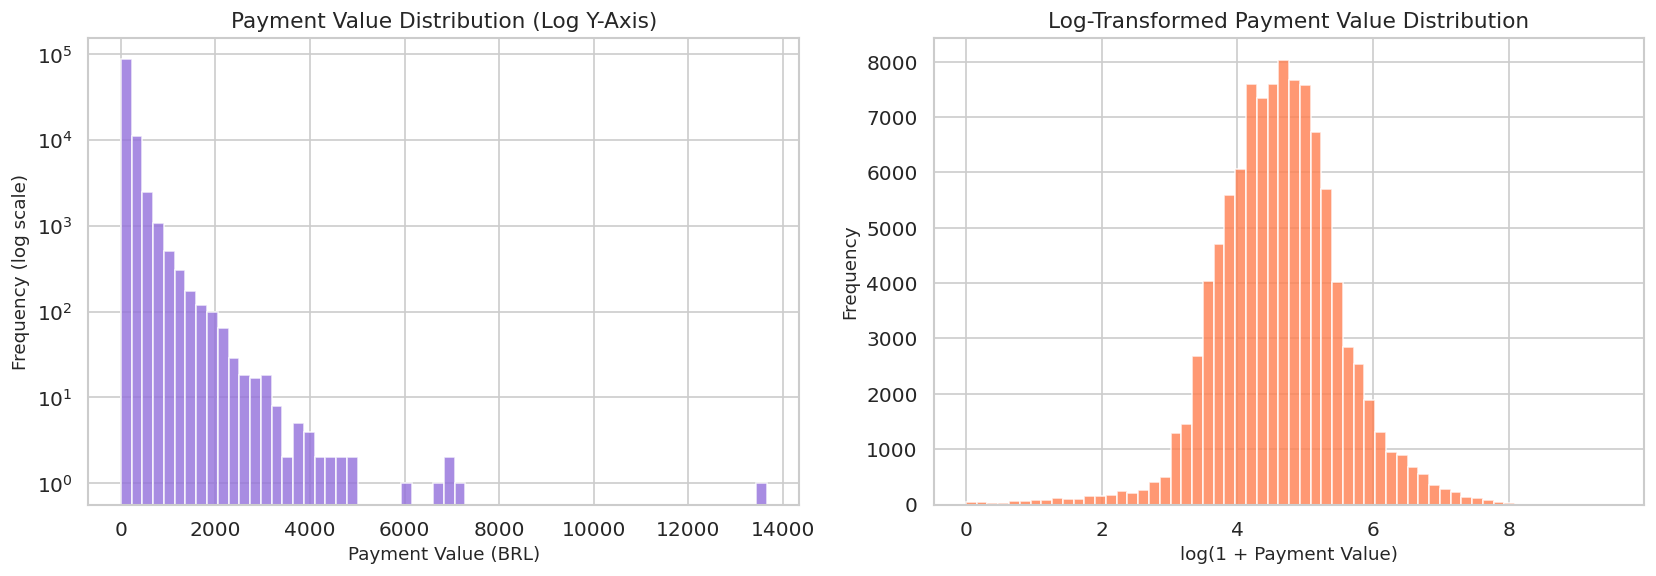

Figure saved: payment_value_distribution.png


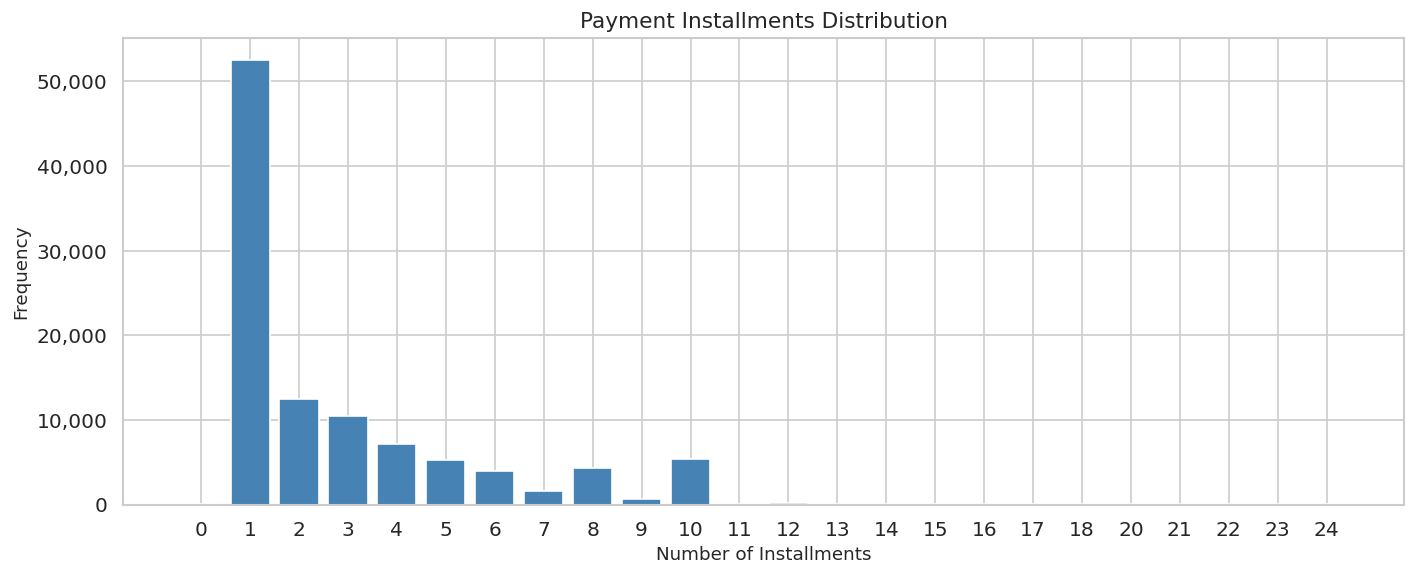

Figure saved: payment_installments.png


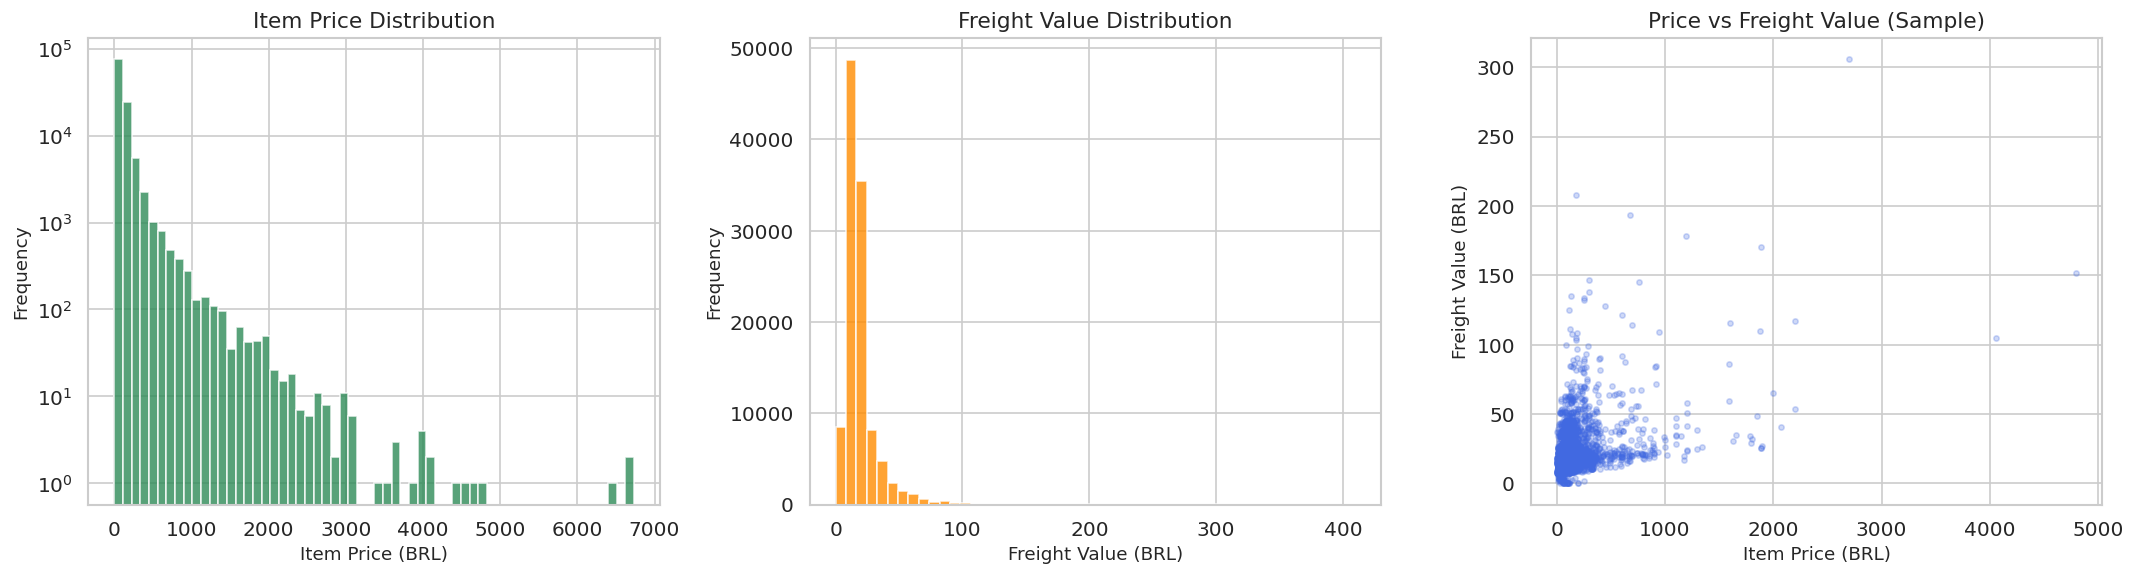

Figure saved: order_items_price_freight.png


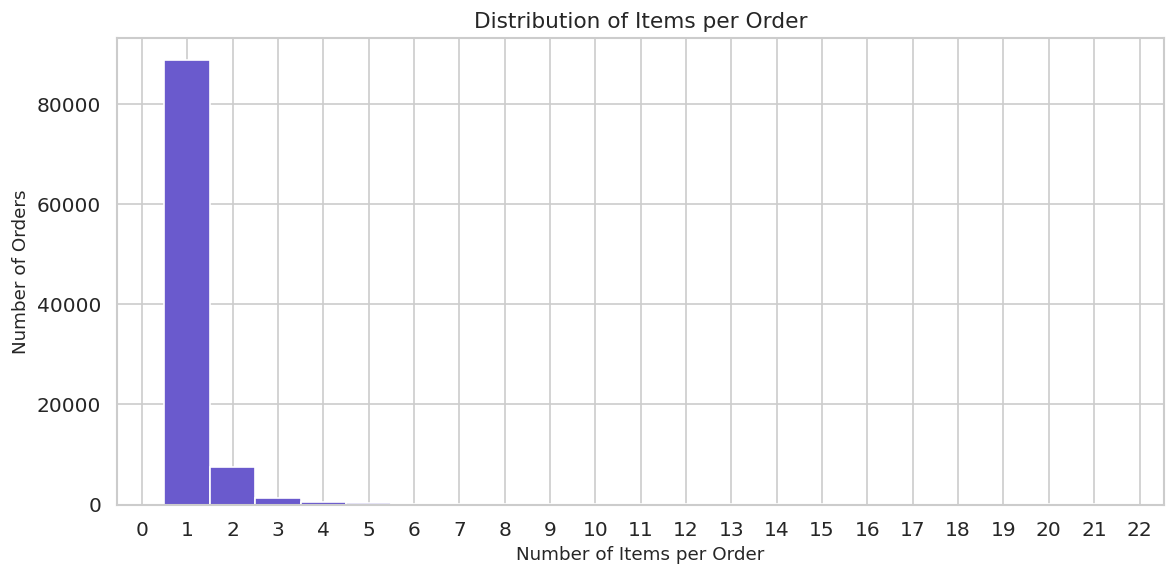

Figure saved: items_per_order.png


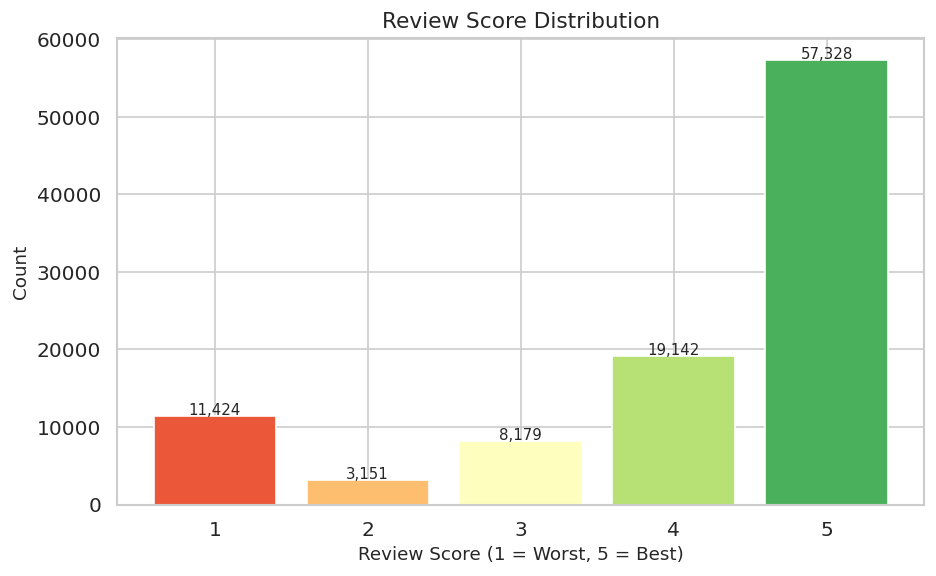

Figure saved: review_score_distribution.png


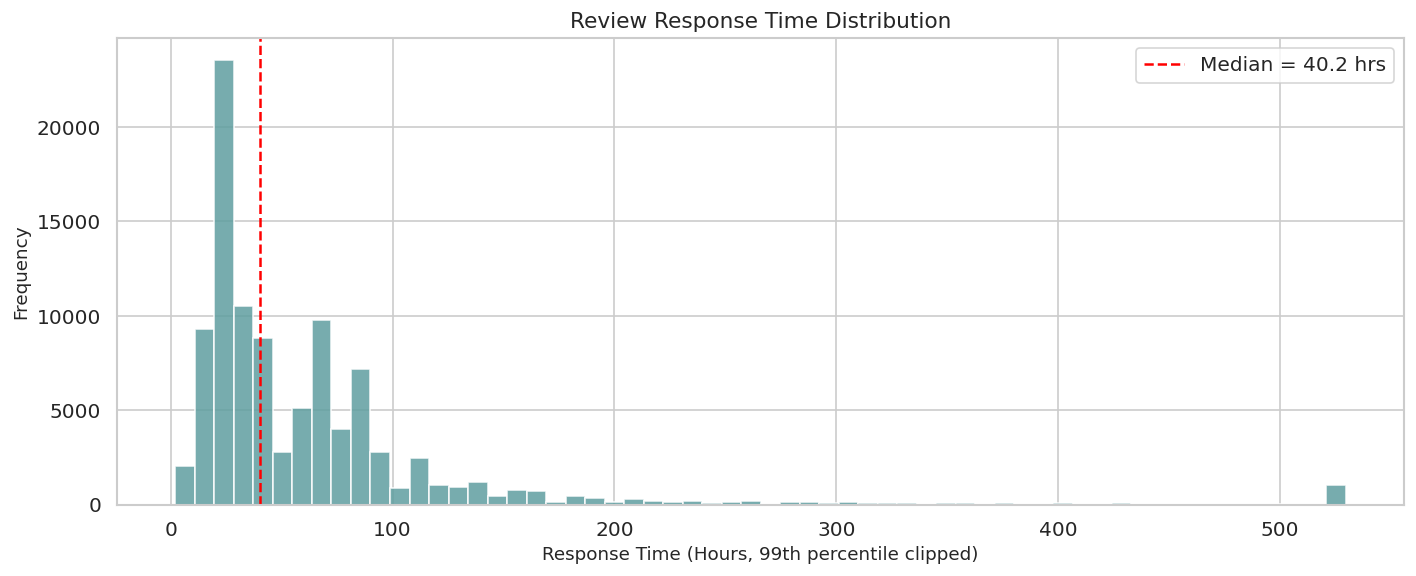

Figure saved: review_response_time.png


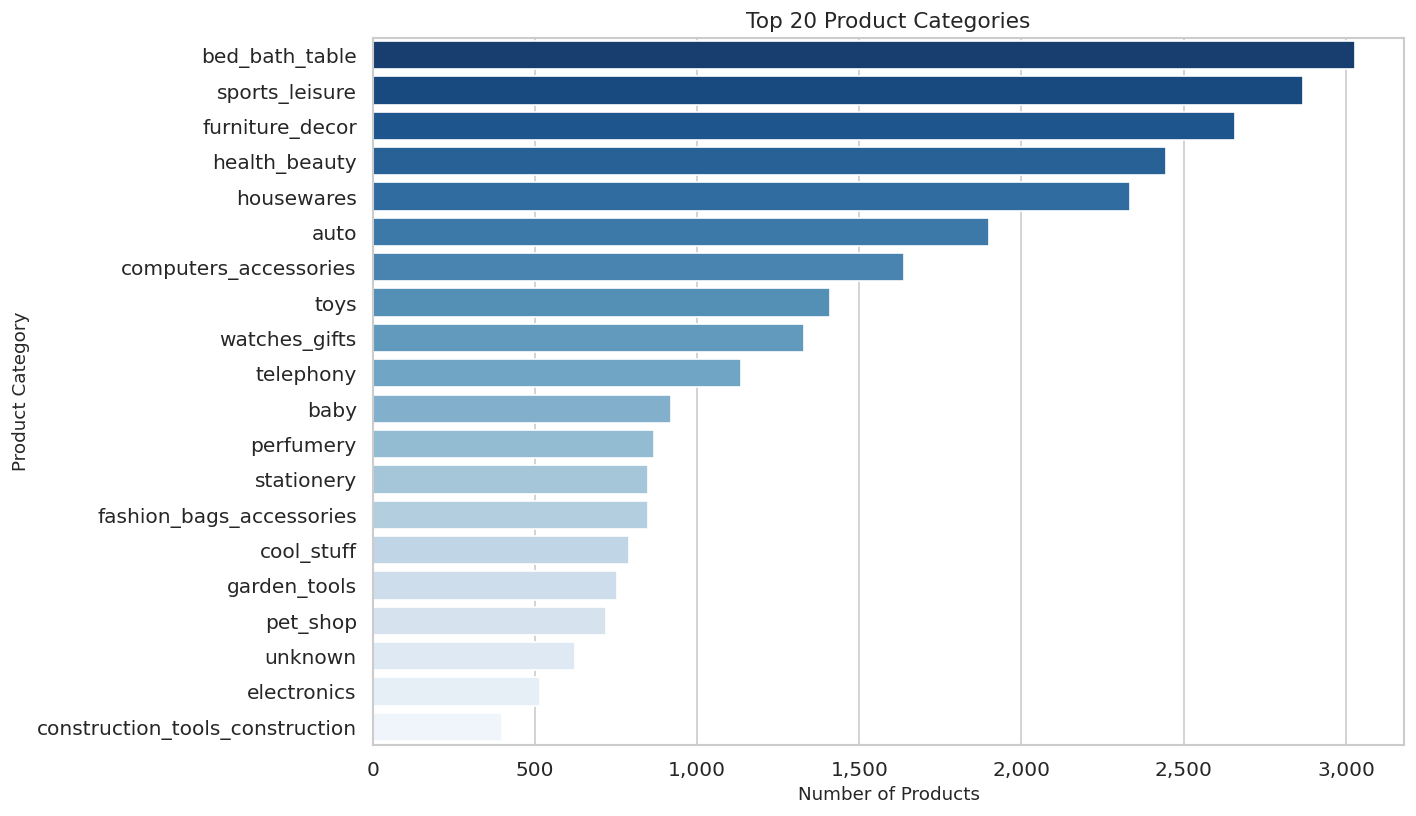

Figure saved: top20_product_categories.png


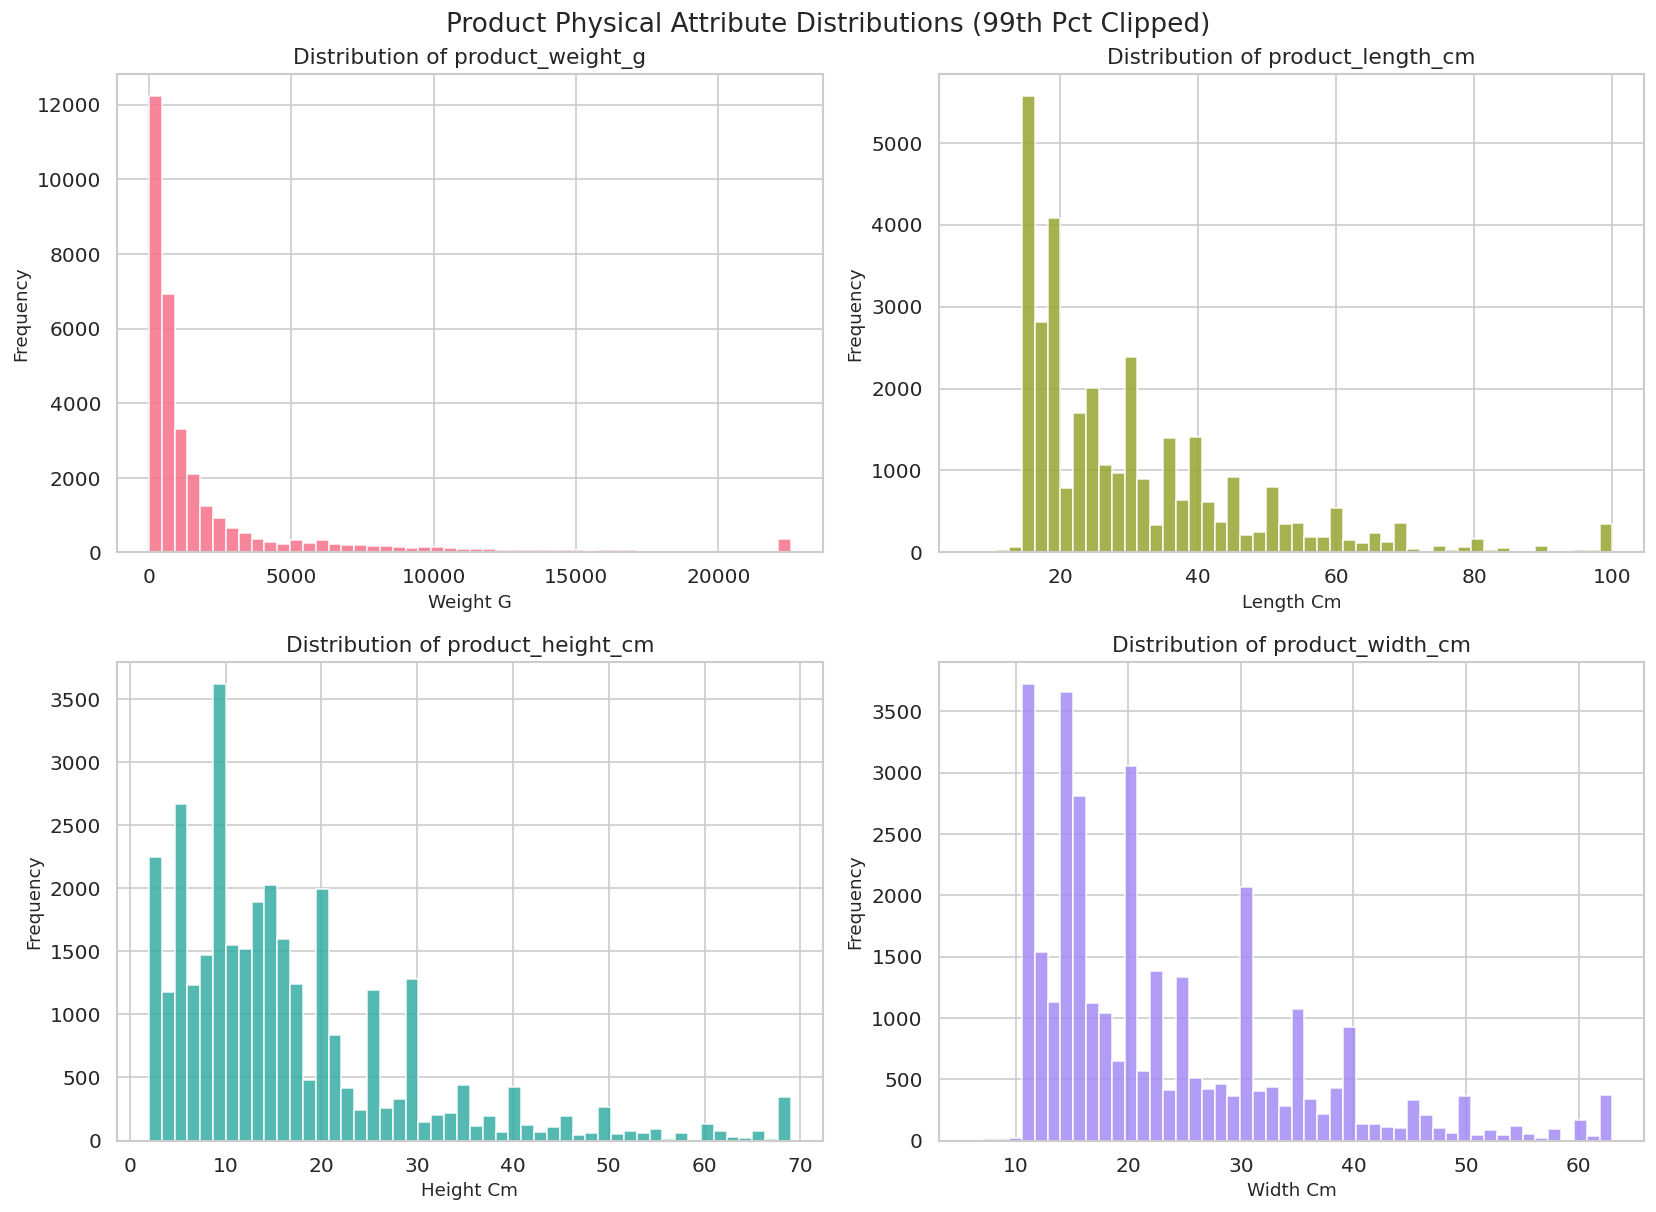

Figure saved: product_physical_attributes.png


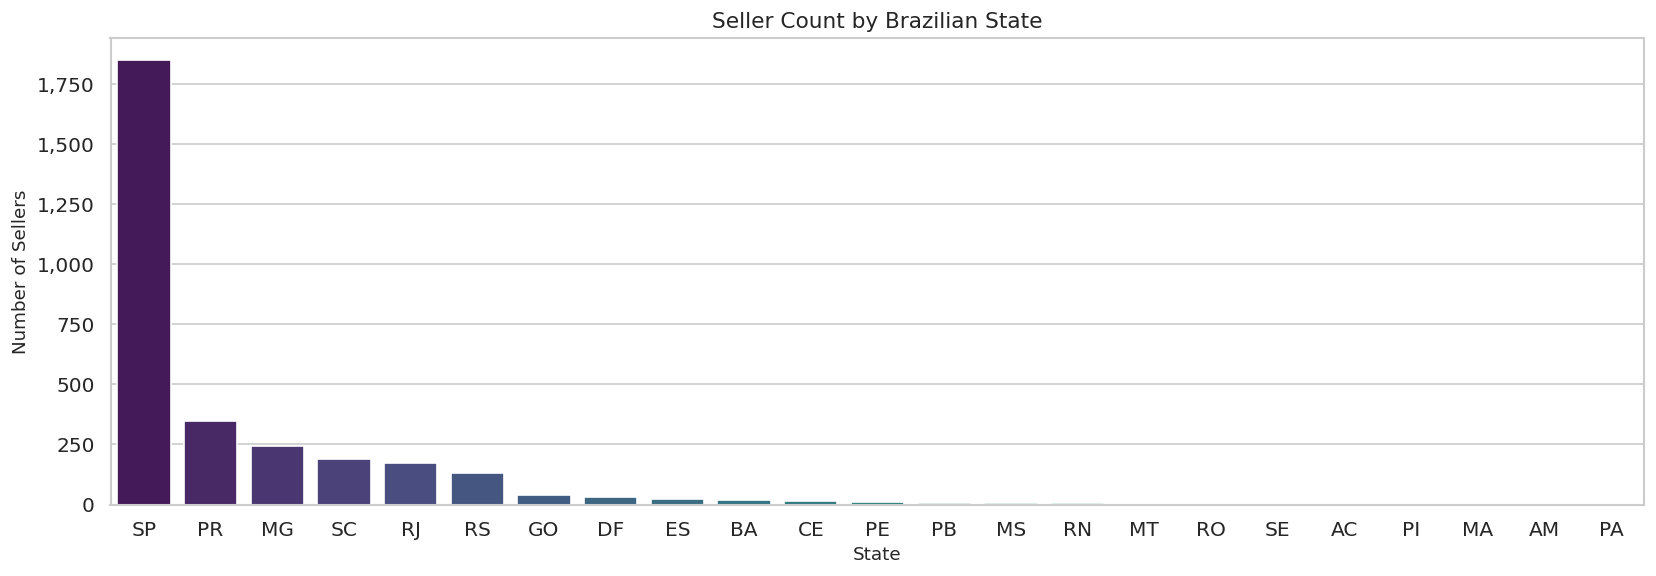

Figure saved: seller_geographic_distribution.png


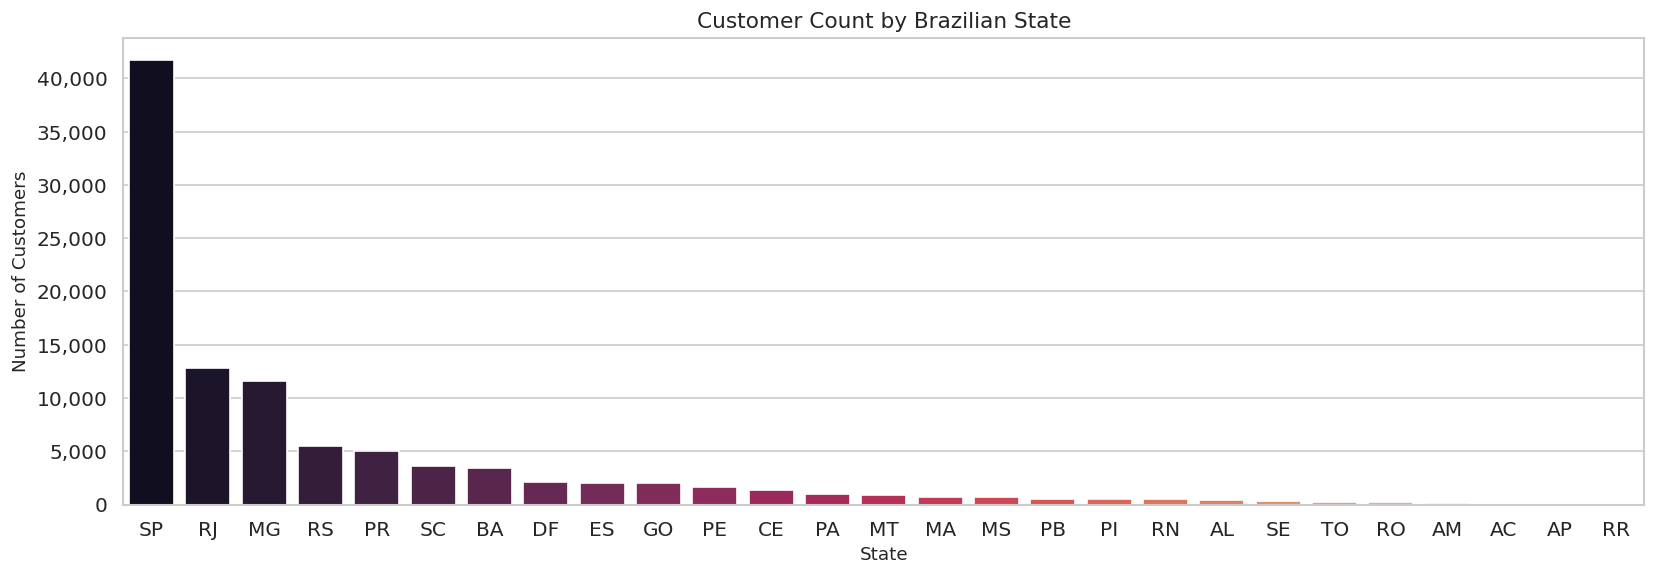

Figure saved: customer_geographic_distribution.png
Referential Integrity Validation -- Source Dataset
  orders.customer_id -> customers.customer_id
    Child FK values    :  99,441
    Parent PK values   :  99,441
    Orphan FK values   :       0  (0.00%)
  order_items.order_id -> orders.order_id
    Child FK values    :  98,666
    Parent PK values   :  99,441
    Orphan FK values   :       0  (0.00%)
  order_items.product_id -> products.product_id
    Child FK values    :  32,951
    Parent PK values   :  32,951
    Orphan FK values   :       0  (0.00%)
  order_items.seller_id -> sellers.seller_id
    Child FK values    :   3,095
    Parent PK values   :   3,095
    Orphan FK values   :       0  (0.00%)
  payments.order_id -> orders.order_id
    Child FK values    :  99,440
    Parent PK values   :  99,441
    Orphan FK values   :       0  (0.00%)
  reviews.order_id -> orders.order_id
    Child FK values    :  98,673
    Parent PK values   :  99,441
    Orphan FK values   :       0  

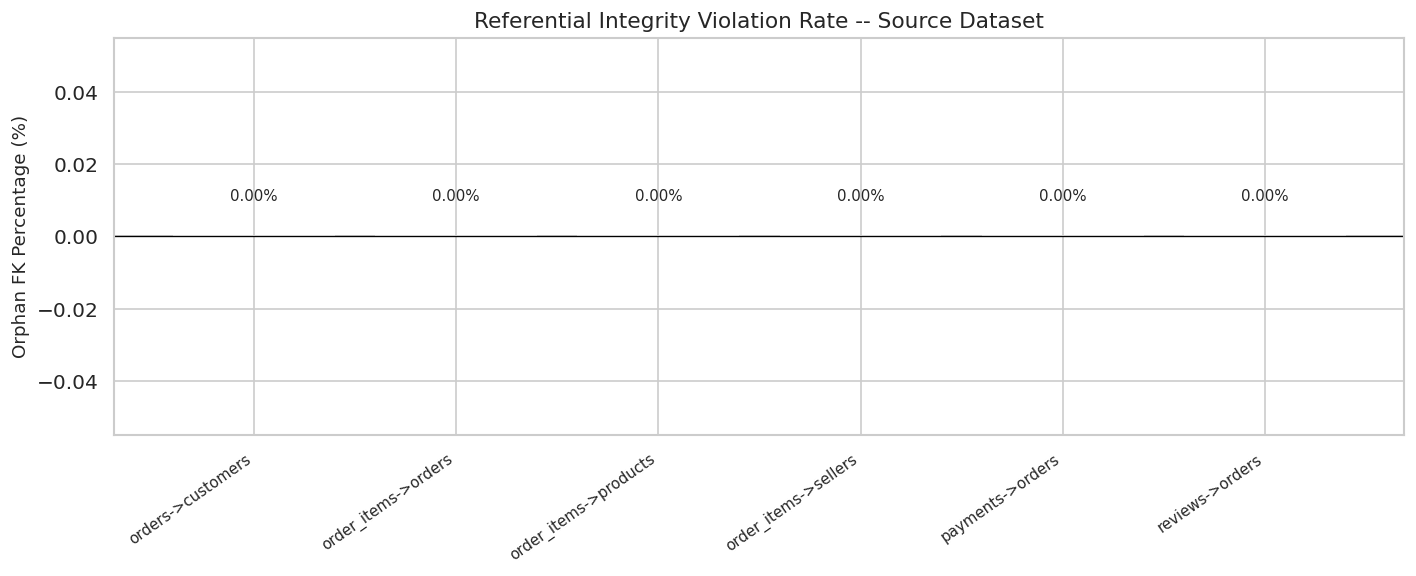

Figure saved: fk_integrity_violations.png
Lifecycle Transition Violation Counts (Source Dataset):
  Purchase -> Approval            violations = 0
  Approval -> Carrier             violations = 1,359
  Carrier -> Customer             violations = 23


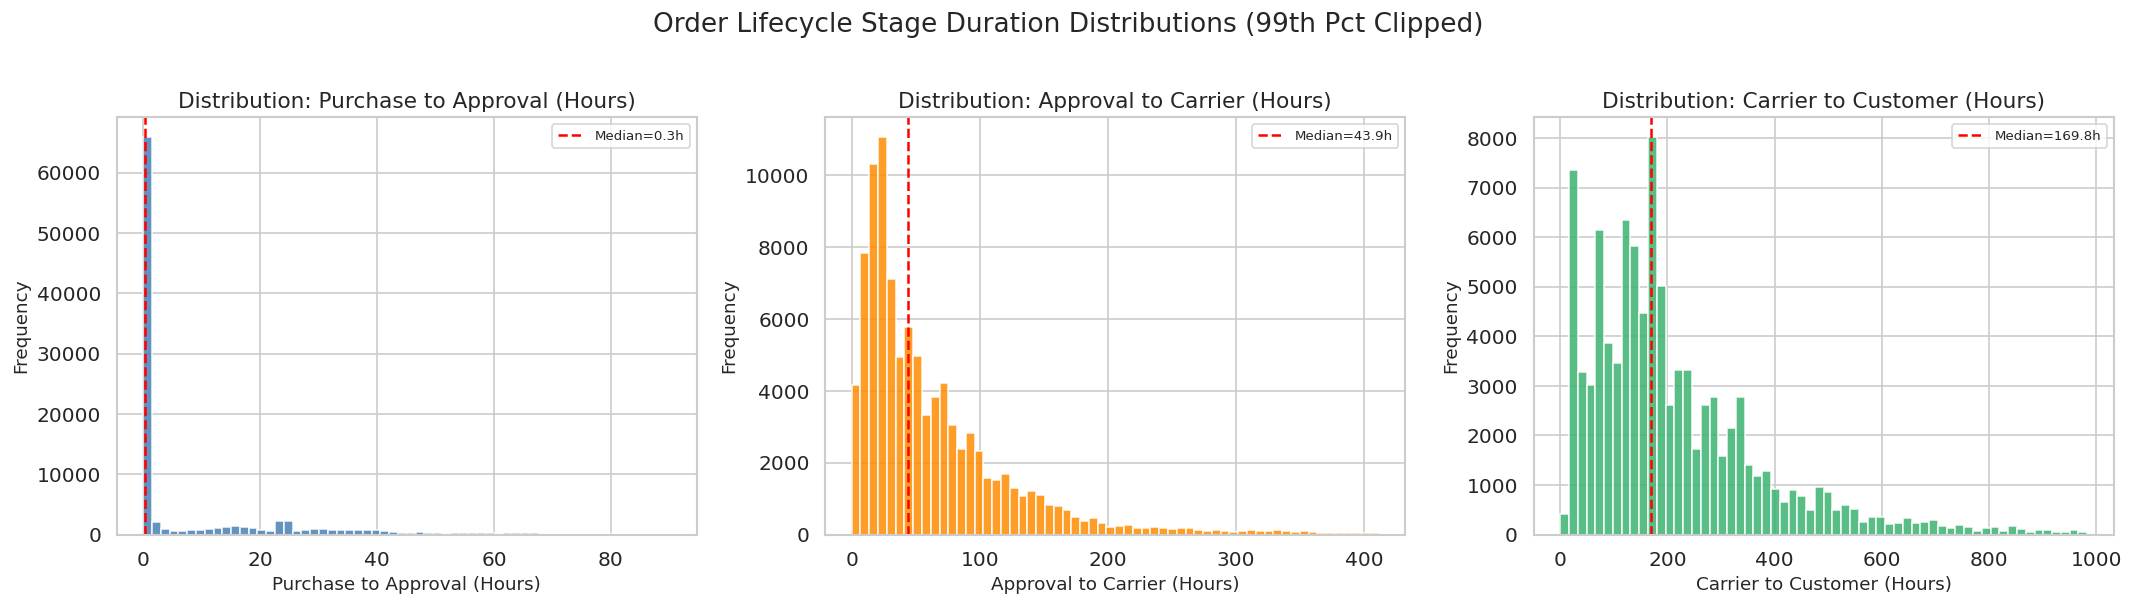

Figure saved: lifecycle_stage_durations.png


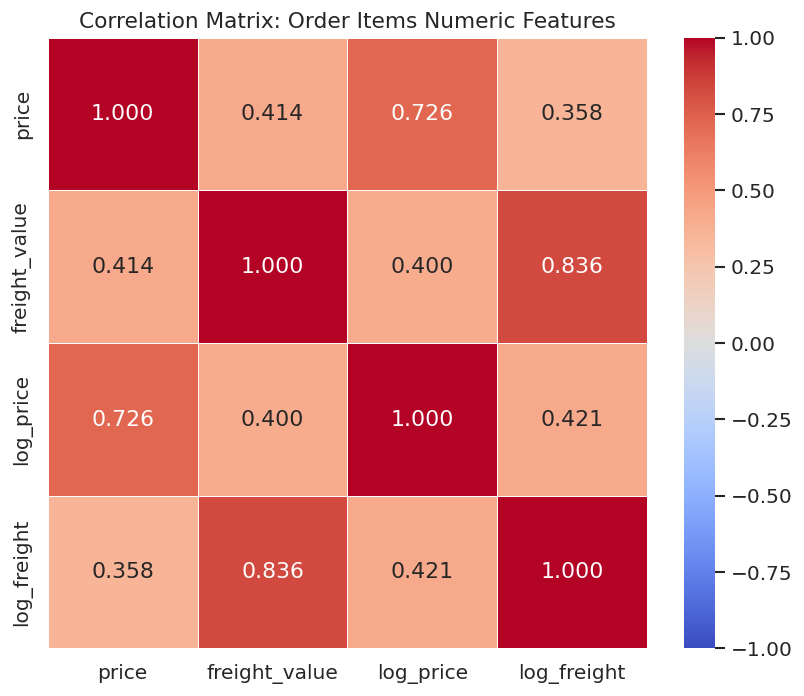

Figure saved: order_items_correlation.png


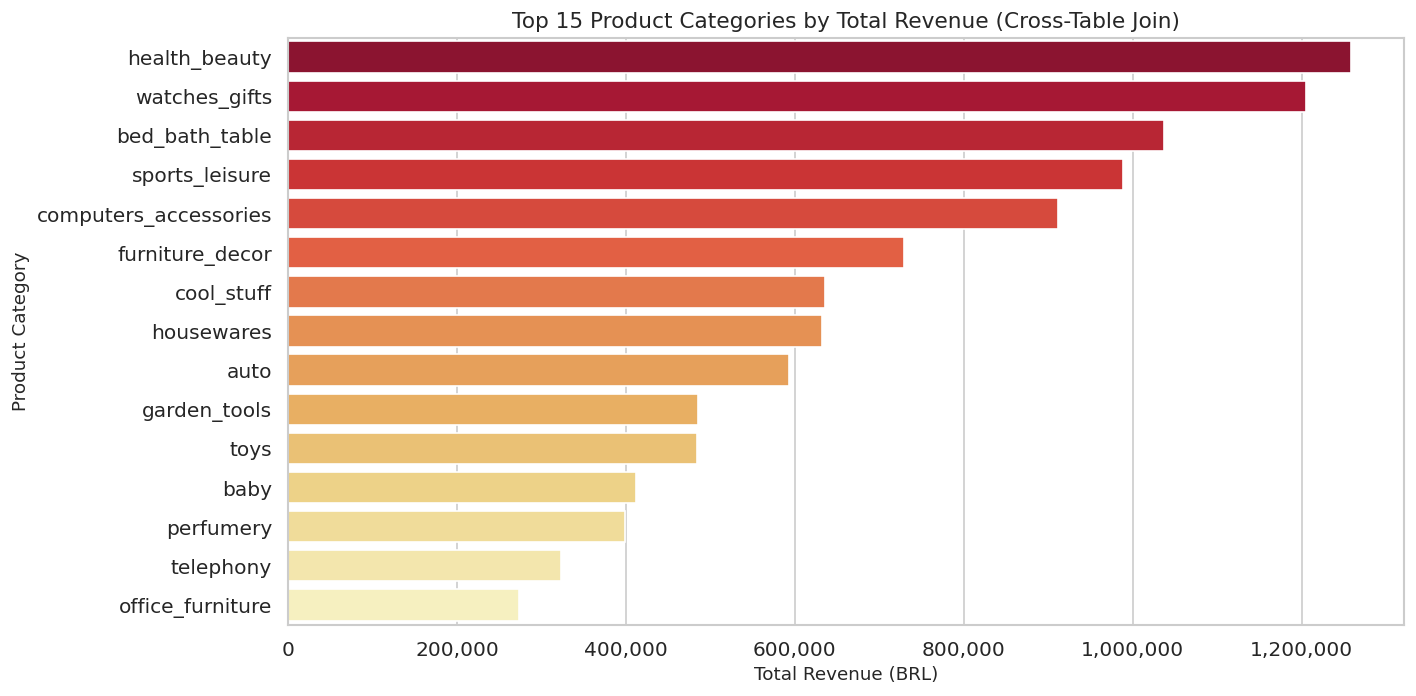

Figure saved: revenue_by_category.png


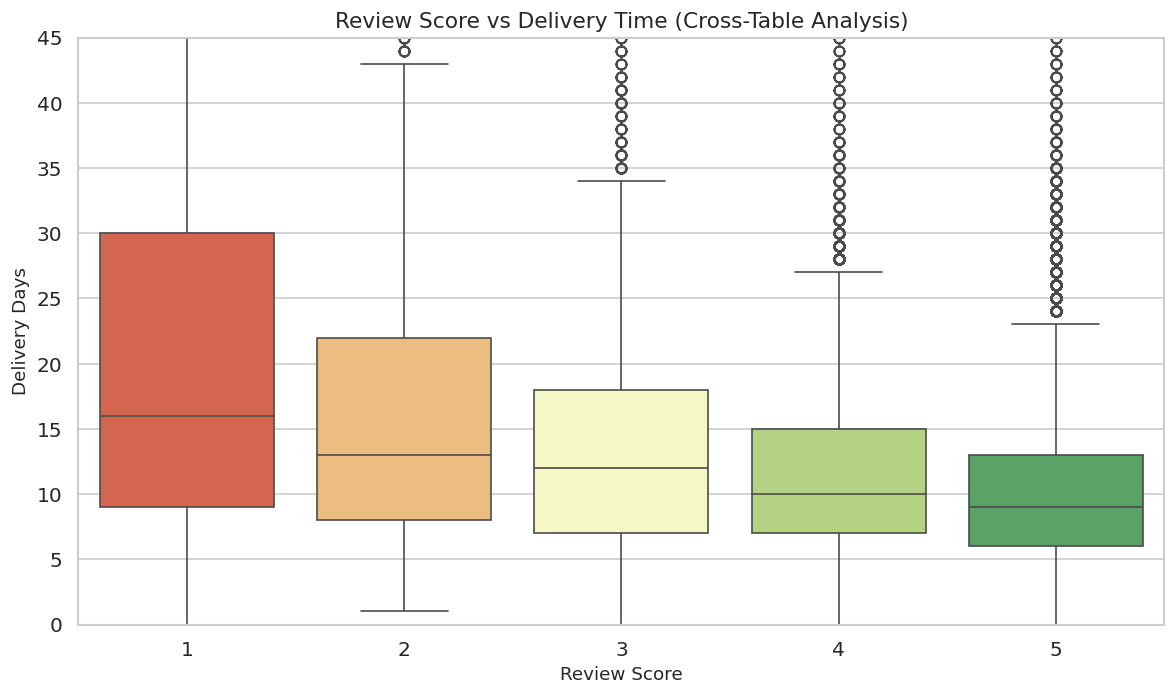

Figure saved: review_score_vs_delivery.png

EDA SUMMARY -- SOURCE DATASET BASELINE
                               Metric     Value
                         Total Orders  99441.00
                     Delivered Orders  96478.00
                     Unique Customers  99441.00
                       Unique Sellers   3095.00
                      Unique Products  32951.00
                    Total Order Items 112650.00
                Total Payment Records 103886.00
                        Total Reviews  99224.00
        Avg Delivery Days (delivered)     12.09
     Median Delivery Days (delivered)     10.00
              Avg Payment Value (BRL)    154.10
           Median Payment Value (BRL)    100.00
                     Avg Review Score      4.09
Pct Orders with FK Violations (items)      0.00
Lifecycle Violations (purchase->appr)      0.00

Baseline summary saved: eda_summary_baseline.csv

All EDA Outputs Generated
  [OK]  missing_heatmaps.png
  [OK]  order_status_distribution.png
  [OK

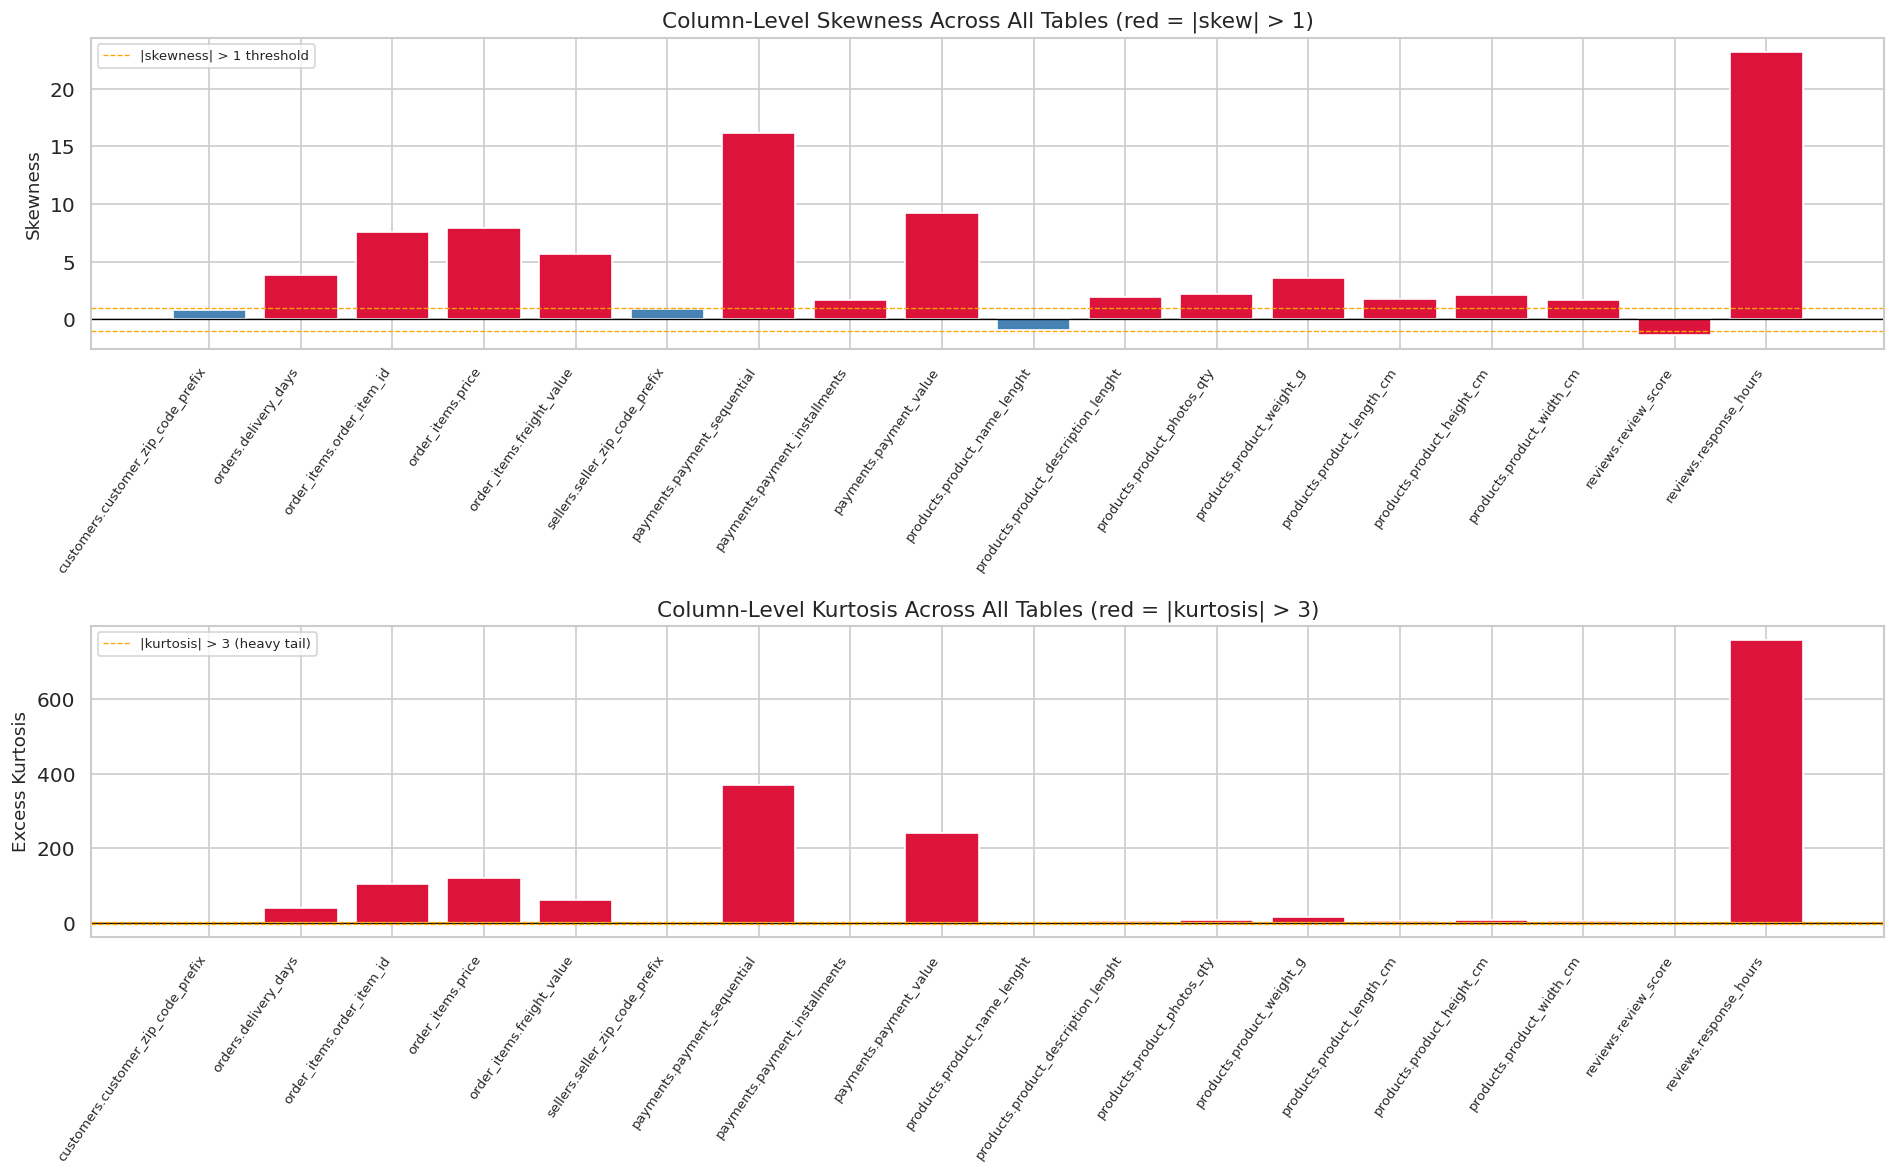

Figure saved: skewness_kurtosis_baseline.png
Late Delivery Analysis (Lifecycle Consistency Baseline)
  Total delivered orders :  96,470
  On-time or early       :  89,936  (93.23%)
  Late deliveries        :   6,534  (6.77%)
  Mean days diff         : -11.88 days
  Median days diff       : -12.00 days


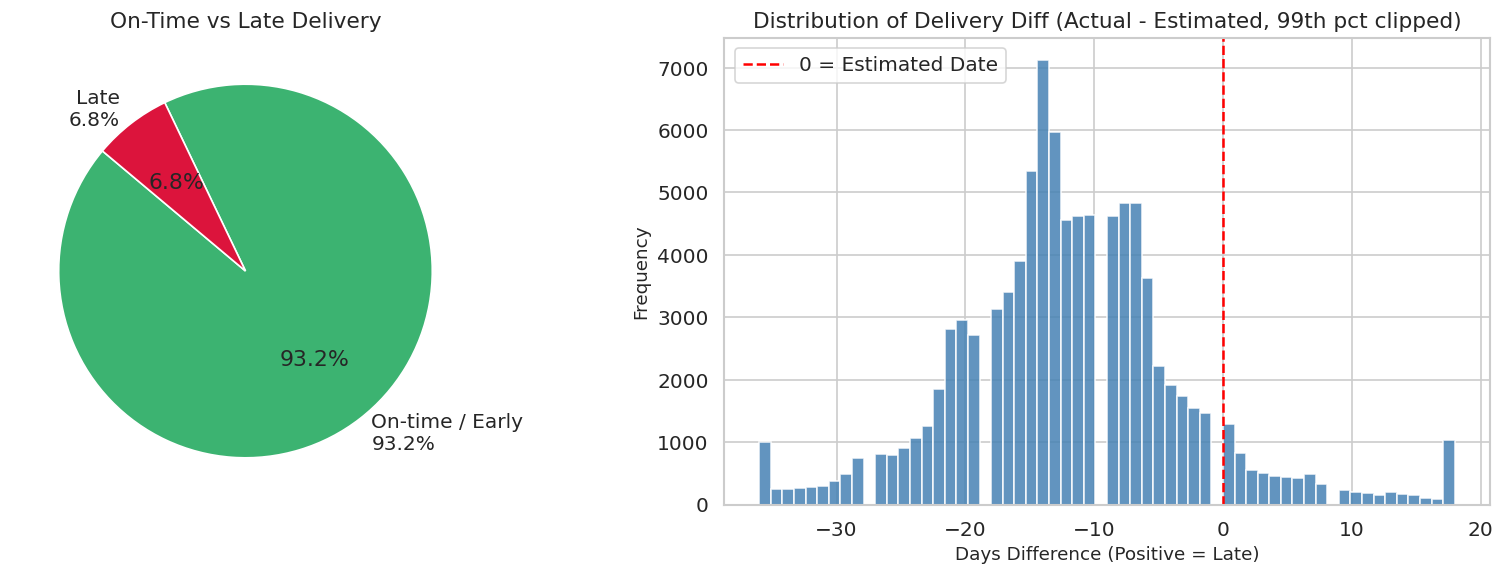

Figure saved: late_delivery_analysis.png
Business Rule Validation Compliance -- Source Dataset Baseline
      Table                                   Rule  Total_Checked  Violations  Compliance_Pct
order_items                              price > 0         112650           0        100.0000
order_items                     freight_value >= 0         112650           0        100.0000
   payments                     payment_value >= 0         103886           0        100.0000
   payments              payment_installments >= 0         103886           0        100.0000
   payments              payment_type in valid set         103886           0        100.0000
    reviews            review_score in [1,2,3,4,5]          99224           0        100.0000
     orders order_status in valid lifecycle states          99441           0        100.0000
   products                   product_weight_g > 0          32949           4         99.9879
   products                  product_length_cm > 0

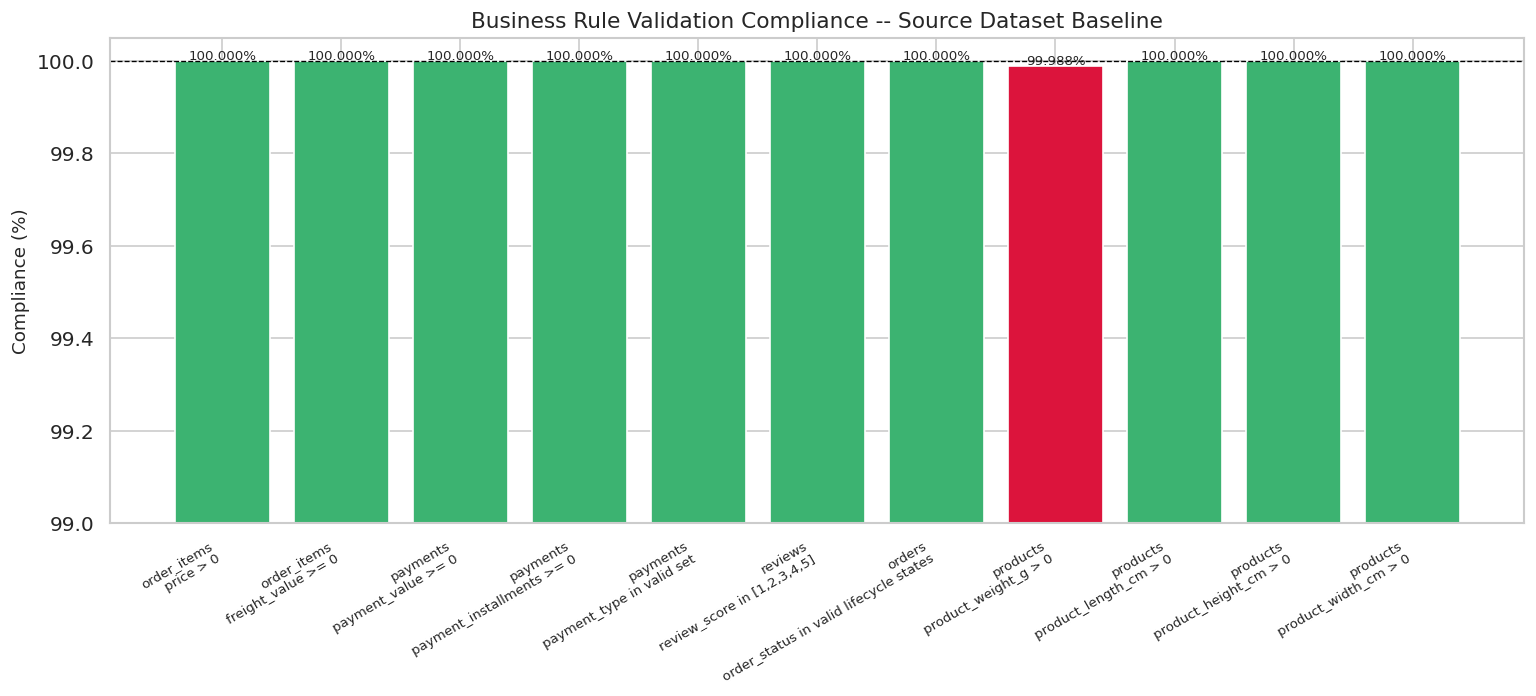

Figure saved: validation_rule_compliance.png
Reverse Referential Integrity Check (Parent with No Children)
  Orders with NO items    :    775  (0.78%)
  Orders with NO payments :      1  (0.00%)
  Orders with NO reviews  :    768  (0.77%)

  Status breakdown for orders with NO items:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1


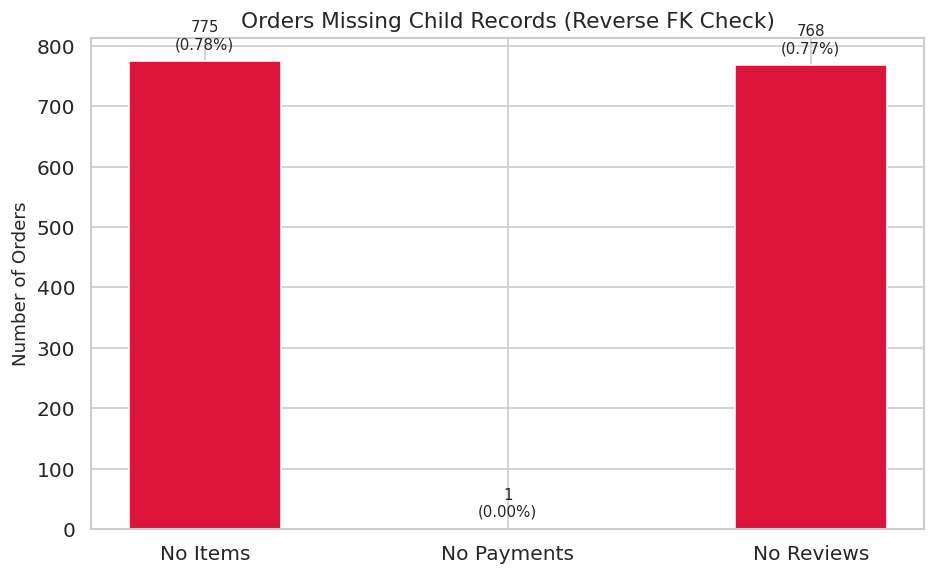

Figure saved: reverse_fk_check.png


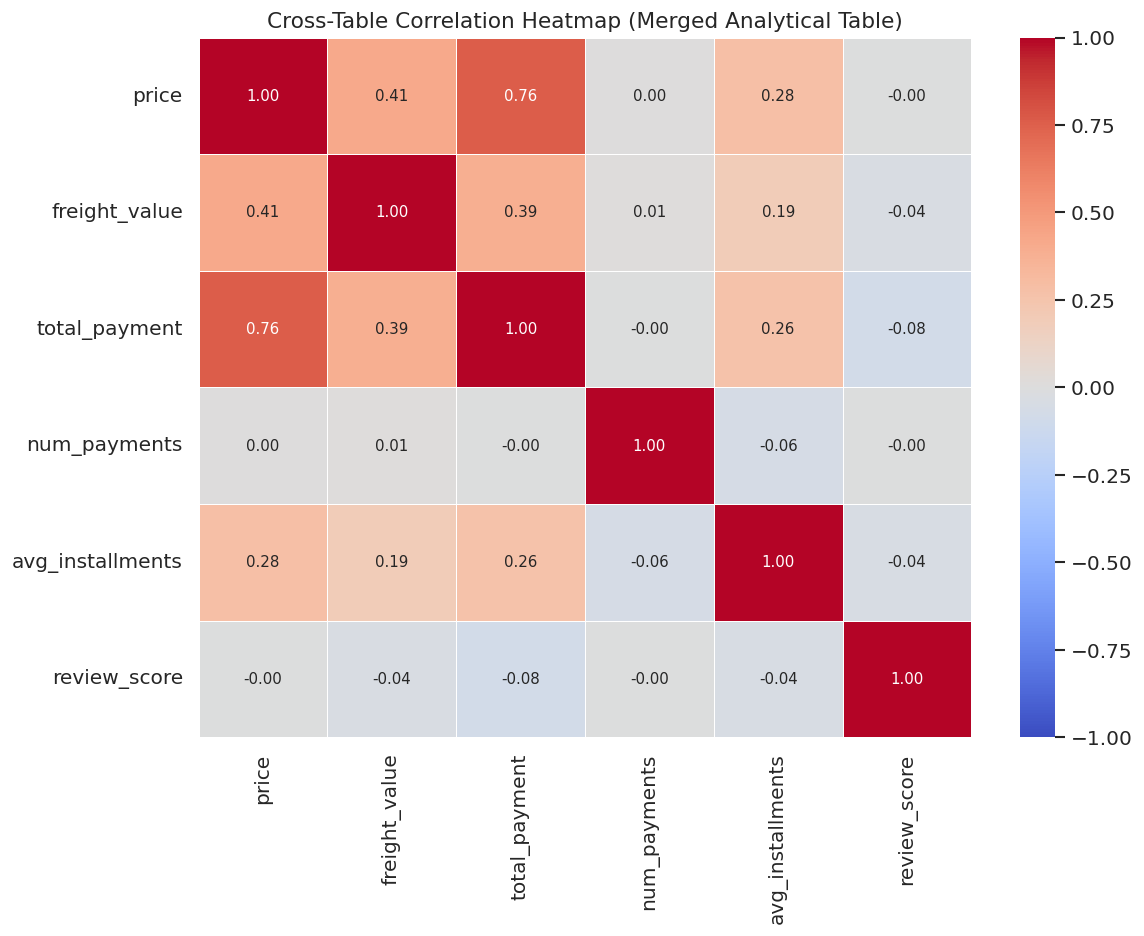

Figure saved: merged_table_correlation.png
Saved: baseline_correlation_matrix.csv
Geolocation Table Overview
  Shape   : (1000163, 5)
  Columns : ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
  Duplicates: 261,831

  Missing values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0

  Unique ZIP prefixes : 19,015
  Unique states       : 27

  Descriptive stats:
       geolocation_lat  geolocation_lng
count     1.000163e+06     1.000163e+06
mean     -2.117620e+01    -4.639050e+01
std       5.715900e+00     4.269700e+00
min      -3.660540e+01    -1.014668e+02
25%      -2.360350e+01    -4.857320e+01
50%      -2.291940e+01    -4.663790e+01
75%      -1.997960e+01    -4.376770e+01
max       4.506590e+01     1.211054e+02

  Rows outside Brazil bounding box (invalid): 42


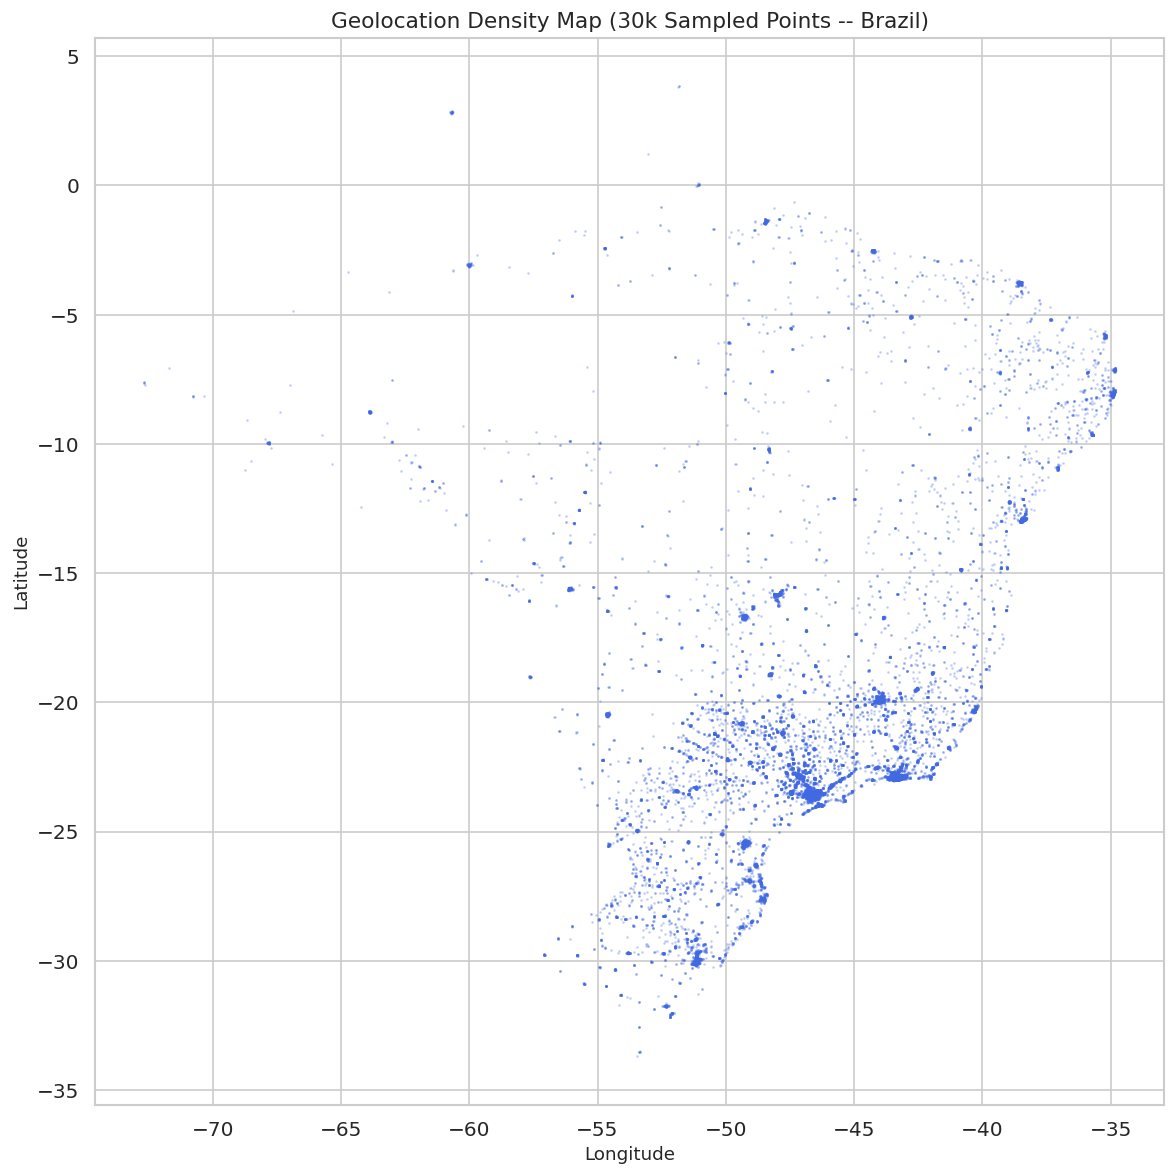

Figure saved: geolocation_density_map.png


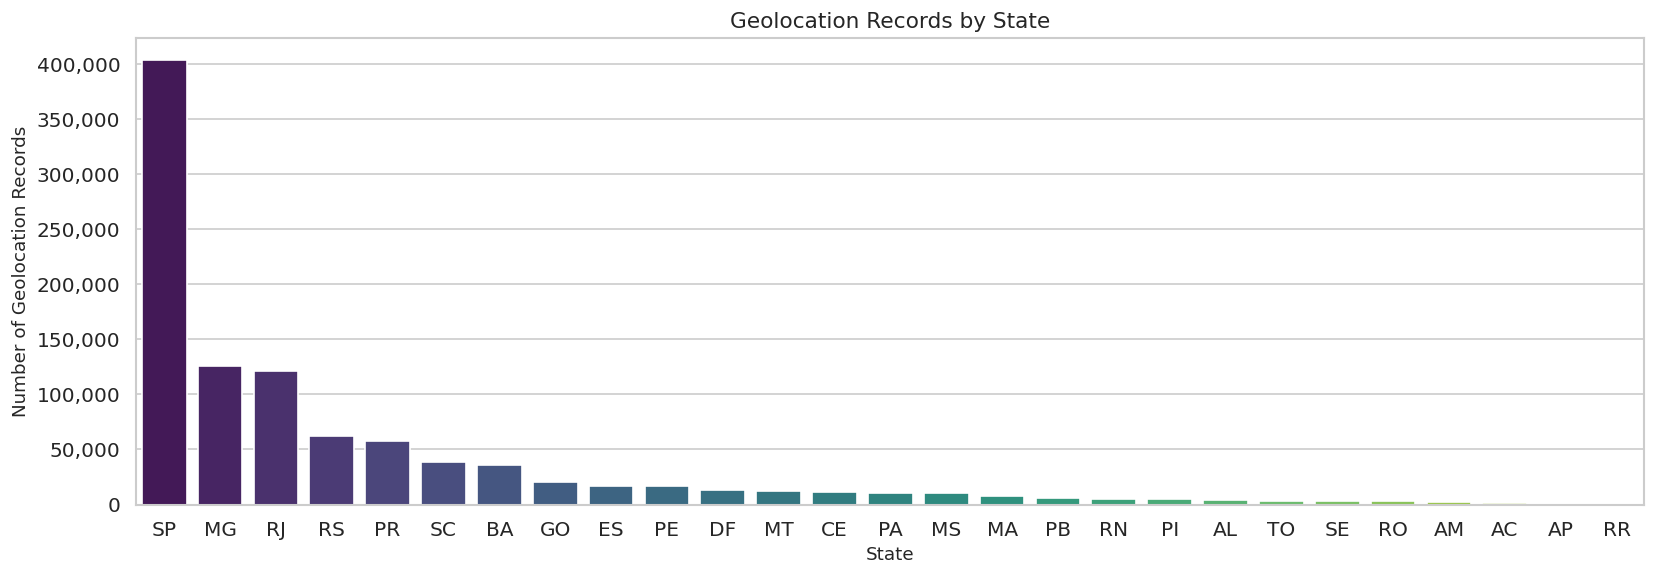

Figure saved: geolocation_by_state.png
Categorical Column Cardinality Across All Tables
        Table                        Column  Unique_Values                        Top_Value  Top_Value_Pct
    customers                   customer_id          99441 274fa6071e5e17fe303b9748641082c8           0.00
       orders                   customer_id          99441 edb027a75a1449115f6b43211ae02a24           0.00
       orders                      order_id          99441 66dea50a8b16d9b4dee7af250b4be1a5           0.00
     payments                      order_id          99440 fa65dad1b0e818e3ccc5cb0e39231352           0.03
      reviews                      order_id          98673 8e17072ec97ce29f0e1f111e598b0c85           0.00
  order_items                      order_id          98666 8272b63d03f5f79c56e9e4120aec44ef           0.02
      reviews                     review_id          98410 4548534449b1f572e357211b90724f1b           0.00
    customers            customer_unique_id          960

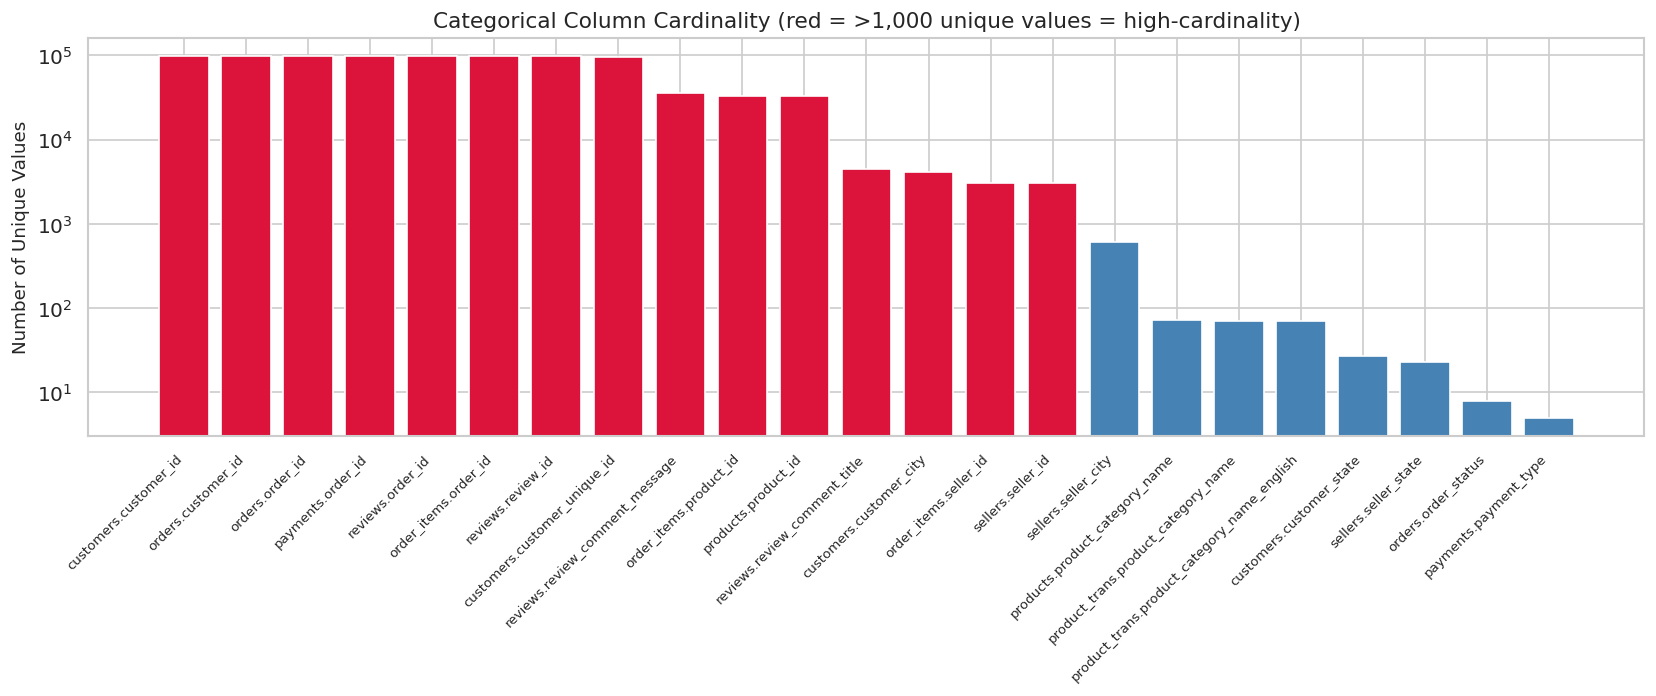

Figure saved: categorical_cardinality.png
Orders per Seller Statistics
count    3095.00
mean       32.31
std       105.14
min         1.00
25%         2.00
50%         6.00
75%        21.50
max      1854.00

  Top 5 sellers by order count:
seller_id
6560211a19b47992c3666cc44a7e94c0    1854
4a3ca9315b744ce9f8e9374361493884    1806
cc419e0650a3c5ba77189a1882b7556a    1706
1f50f920176fa81dab994f9023523100    1404
da8622b14eb17ae2831f4ac5b9dab84a    1314


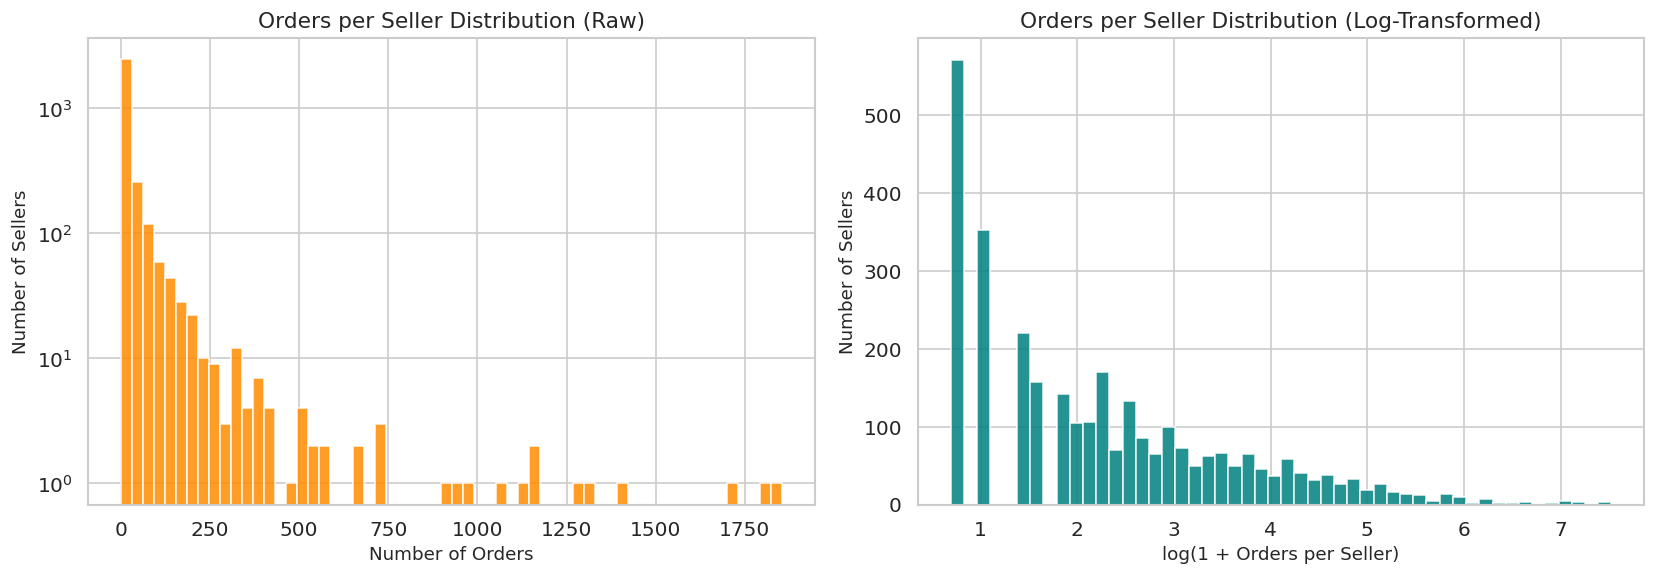

Figure saved: orders_per_seller.png
Customer Repeat Purchase Analysis
  Total unique customers  :  96,096
  One-time purchasers     :  93,099  (96.88%)
  Repeat purchasers       :   2,997  (3.12%)
  Max orders by 1 customer: 17


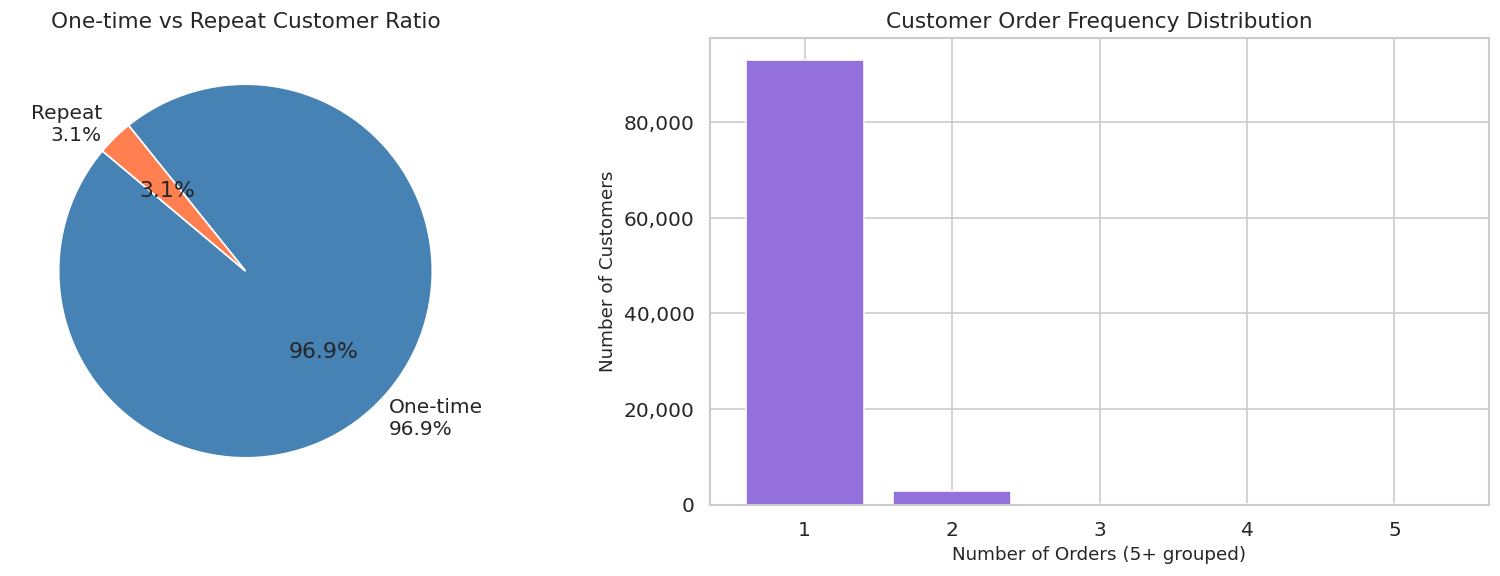

Figure saved: customer_repeat_analysis.png


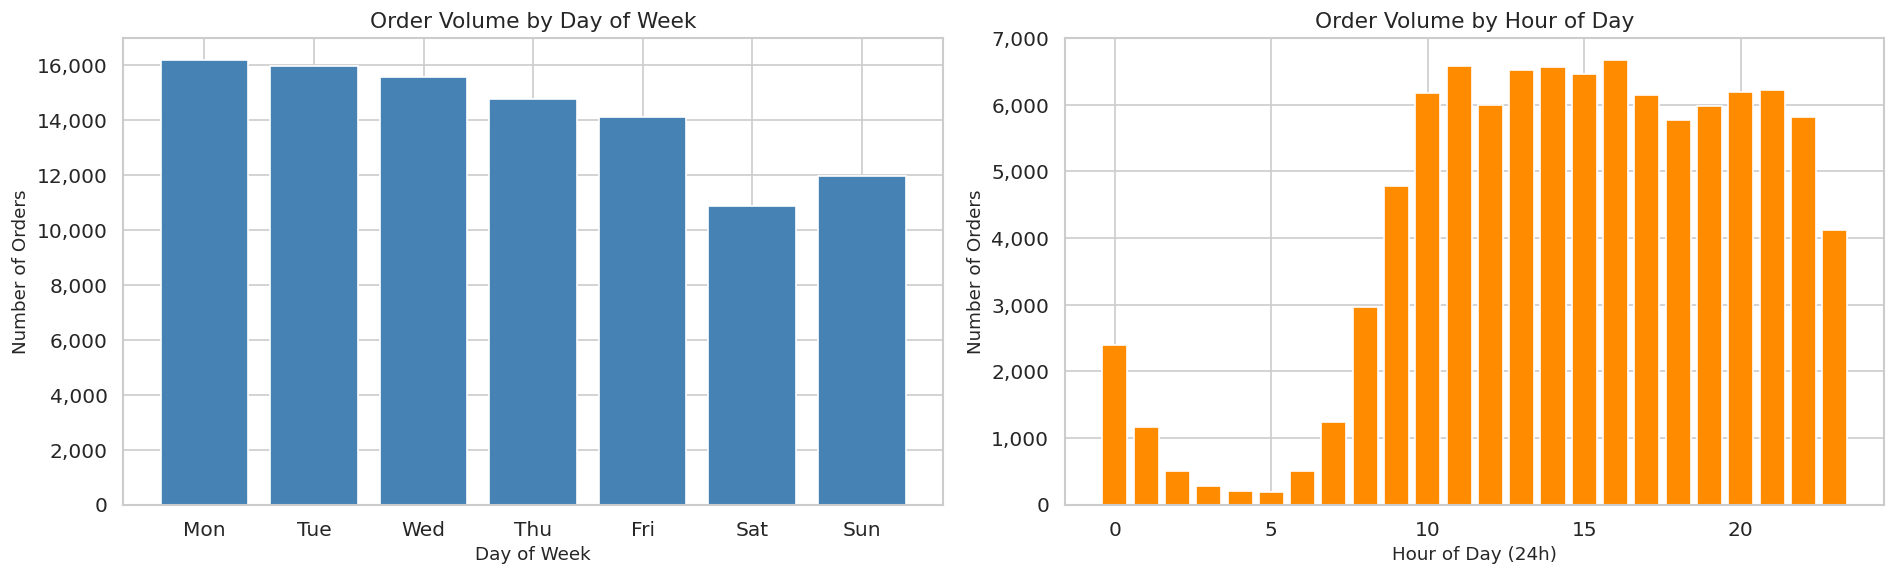

Figure saved: temporal_patterns_dow_hour.png
Multi-Payment Orders Analysis
  Orders with single payment :  96,401  (96.94%)
  Orders with multi payment  :   3,039  (3.06%)


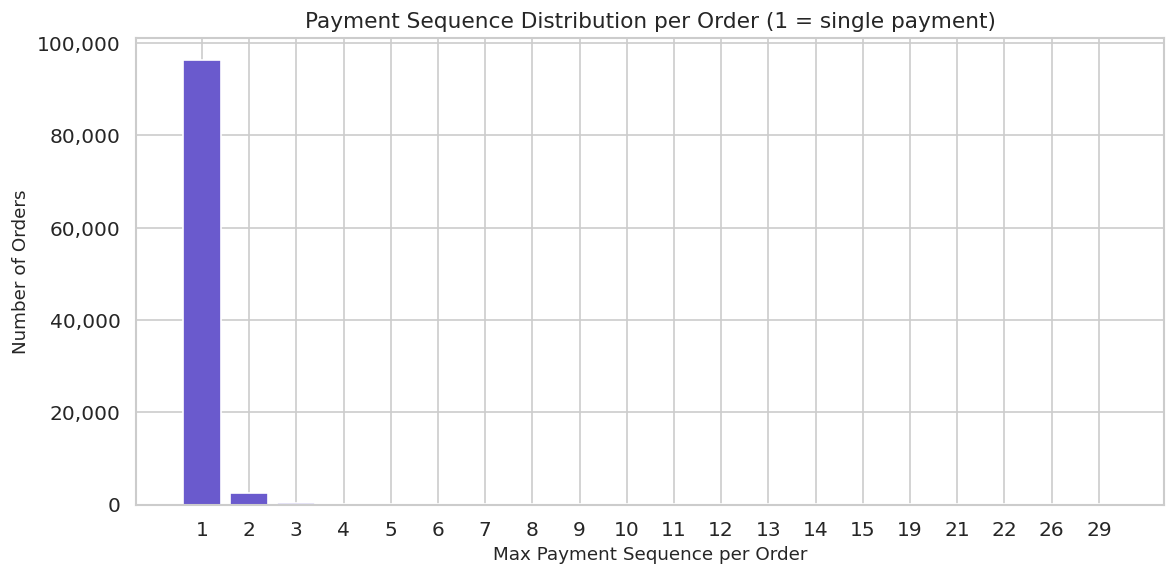

Figure saved: multi_payment_distribution.png

FULL EDA BASELINE SUMMARY -- CARI-GAN Pre-Generation Reference
                             Metric     Value
                       Total Orders  99441.00
                   Delivered Orders  96478.00
              Unique Customers (ID)  99441.00
          Unique Customers (Person)  96096.00
           Repeat Customer Rate (%)      3.12
                     Unique Sellers   3095.00
                    Unique Products  32951.00
                  Total Order Items 112650.00
              Total Payment Records 103886.00
                      Total Reviews  99224.00
      Avg Delivery Days (delivered)     12.09
   Median Delivery Days (delivered)     10.00
             Late Delivery Rate (%)      6.77
Lifecycle Violations: Appr->Carrier   1359.00
Lifecycle Violations: Carrier->Cust     23.00
            Avg Payment Value (BRL)    154.10
         Median Payment Value (BRL)    100.00
               Multi-Payment Orders   3039.00
                 

In [ ]:
# =============================================================================
# CARI-GAN: Constraint-Aware Relational Integrity GAN
# Brazilian E-Commerce Public Dataset (Olist) - Kaggle
# Phase: Data Loading --> Exploratory Data Analysis (EDA)



# ============================================================
# CELL 1 -- Install and Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

# Suppress non-critical warnings to keep output clean
warnings.filterwarnings("ignore")

# Set a consistent visual style across all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["axes.titlesize"] = 13
matplotlib.rcParams["axes.labelsize"] = 11

print("All libraries loaded successfully.")
print(f"Pandas version  : {pd.__version__}")
print(f"NumPy  version  : {np.__version__}")


# ============================================================
# CELL 2 -- Define Dataset Path (Kaggle Input Directory)
# ============================================================

# Kaggle mounts competition / dataset files under /kaggle/input/
# Adjust the folder name if you downloaded the dataset under a different alias
BASE_PATH = "/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce"

# List all files present in the dataset directory so we can verify availability
all_files = os.listdir(BASE_PATH)
print("Files available in dataset directory:")
for f in sorted(all_files):
    print("  ", f)


# ============================================================
# CELL 3 -- Load All Relational Tables into DataFrames
# ============================================================

# The Olist dataset is distributed across seven CSV files that mirror
# a typical enterprise CRM relational schema (Accounts, Orders, Line-Items,
# Sellers, Payments, Products, Reviews).

customers  = pd.read_csv(os.path.join(BASE_PATH, "olist_customers_dataset.csv"))
orders     = pd.read_csv(os.path.join(BASE_PATH, "olist_orders_dataset.csv"),
                         parse_dates=[
                             "order_purchase_timestamp",
                             "order_approved_at",
                             "order_delivered_carrier_date",
                             "order_delivered_customer_date",
                             "order_estimated_delivery_date"
                         ])
order_items   = pd.read_csv(os.path.join(BASE_PATH, "olist_order_items_dataset.csv"),
                            parse_dates=["shipping_limit_date"])
sellers       = pd.read_csv(os.path.join(BASE_PATH, "olist_sellers_dataset.csv"))
payments      = pd.read_csv(os.path.join(BASE_PATH, "olist_order_payments_dataset.csv"))
products      = pd.read_csv(os.path.join(BASE_PATH, "olist_products_dataset.csv"))
reviews       = pd.read_csv(os.path.join(BASE_PATH, "olist_order_reviews_dataset.csv"),
                             parse_dates=["review_creation_date", "review_answer_timestamp"])
product_trans = pd.read_csv(os.path.join(BASE_PATH, "product_category_name_translation.csv"))

print("All tables loaded.")
table_map = {
    "customers"    : customers,
    "orders"       : orders,
    "order_items"  : order_items,
    "sellers"      : sellers,
    "payments"     : payments,
    "products"     : products,
    "reviews"      : reviews,
    "product_trans": product_trans,
}
for name, df in table_map.items():
    print(f"  {name:<15}  rows={df.shape[0]:>7,}  cols={df.shape[1]:>3}")


# ============================================================
# CELL 4 -- Schema Overview: Shape, Column Types, Sample Rows
# ============================================================

# Printing dtypes and a head sample for each table gives a rapid understanding
# of the relational schema before any transformation.

for name, df in table_map.items():
    print("=" * 60)
    print(f"TABLE: {name.upper()}")
    print(f"  Shape : {df.shape}")
    print("  Dtypes:")
    print(df.dtypes.to_string(dtype=True))
    print("\n  Head (3 rows):")
    print(df.head(3).to_string())
    print()


# ============================================================
# CELL 5 -- Missing Value Analysis Across All Tables
# ============================================================

# Missing values in a relational dataset affect both statistical fidelity
# and referential integrity.  We compute absolute and percentage null counts.

def missing_summary(df, table_name):
    total   = df.isnull().sum()
    percent = (total / len(df)) * 100
    result  = pd.DataFrame({"Missing_Count": total, "Missing_Percent": percent})
    result  = result[result["Missing_Count"] > 0].sort_values("Missing_Percent", ascending=False)
    if result.empty:
        print(f"[{table_name}]  No missing values detected.")
    else:
        print(f"[{table_name}]")
        print(result.round(2).to_string())
    print()

for name, df in table_map.items():
    missing_summary(df, name)


# ============================================================
# CELL 6 -- Visualize Missing Values Heatmap (Combined)
# ============================================================

# A heatmap of null presence gives an at-a-glance view of sparsity patterns
# that a synthetic generator must learn to replicate.

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for idx, (name, df) in enumerate(table_map.items()):
    ax = axes[idx]
    # msno-style heatmap: True = missing (yellow), False = present (purple)
    mask = df.isnull()
    if mask.any().any():
        sns.heatmap(mask, cbar=False, yticklabels=False,
                    cmap="YlOrRd", ax=ax, linewidths=0)
        ax.set_title(f"Missing Values: {name}")
        ax.set_xlabel("Columns")
    else:
        ax.text(0.5, 0.5, "No Missing Values",
                ha="center", va="center", fontsize=12, transform=ax.transAxes)
        ax.set_title(f"Missing Values: {name}")
        ax.axis("off")

plt.tight_layout()
plt.suptitle("Missing Value Heatmaps Across All Tables", fontsize=15, y=1.01)
plt.savefig("missing_heatmaps.png", bbox_inches="tight")
plt.show()
print("Figure saved: missing_heatmaps.png")


# ============================================================
# CELL 7 -- Duplicate Row Check Across All Tables
# ============================================================

# Duplicate rows in the source dataset signal data quality issues that
# propagate into any synthetic generation pipeline.

print("Duplicate Row Analysis")
print("-" * 40)
for name, df in table_map.items():
    dup_count = df.duplicated().sum()
    print(f"  {name:<15}  duplicates = {dup_count:>5,}")


# ============================================================
# CELL 8 -- Descriptive Statistics for Numeric Columns
# ============================================================

# Numeric summaries reveal the value ranges, skewness signals, and
# outlier presence that CARI-GAN must statistically replicate.

for name, df in table_map.items():
    numeric_cols = df.select_dtypes(include=[np.number])
    if numeric_cols.empty:
        print(f"[{name}]  No numeric columns.\n")
        continue
    print(f"[{name}]")
    print(numeric_cols.describe().round(3).to_string())
    print()


# ============================================================
# CELL 9 -- Orders Table: Order Status Distribution
# ============================================================

# Order status captures the lifecycle state of each transaction.
# In CRM terms this represents the workflow stage (open, closed, etc.).
# CARI-GAN must reproduce valid status transitions.

status_counts = orders["order_status"].value_counts().reset_index()
status_counts.columns = ["status", "count"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(status_counts["status"], status_counts["count"],
               color=sns.color_palette("muted", len(status_counts)))
ax.set_xlabel("Number of Orders")
ax.set_title("Order Status Distribution (Lifecycle States)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Annotate each bar with its count
for bar, val in zip(bars, status_counts["count"]):
    ax.text(val + 200, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("order_status_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved: order_status_distribution.png")


# ============================================================
# CELL 10 -- Orders Table: Monthly Order Volume Over Time
# ============================================================

# Temporal trends expose seasonality and volume spikes that a synthetic
# generator must preserve for realistic sandbox testing.

orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
monthly_orders = (
    orders.groupby("order_month")
          .size()
          .reset_index(name="order_count")
)
monthly_orders["order_month_str"] = monthly_orders["order_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_orders["order_month_str"], monthly_orders["order_count"],
        marker="o", linewidth=2, color="steelblue", markersize=4)
ax.fill_between(range(len(monthly_orders)), monthly_orders["order_count"],
                alpha=0.15, color="steelblue")
ax.set_xticks(range(0, len(monthly_orders), 3))
ax.set_xticklabels(monthly_orders["order_month_str"].iloc[::3], rotation=45, ha="right")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
ax.set_title("Monthly Order Volume Over Time")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("monthly_order_volume.png", bbox_inches="tight")
plt.show()
print("Figure saved: monthly_order_volume.png")


# ============================================================
# CELL 11 -- Orders Table: Delivery Time Analysis
# ============================================================

# Delivery time is a computed lifecycle metric derived from two timestamp
# columns.  It represents a workflow duration that synthetic data must
# statistically approximate.

orders["delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

# Only consider successfully delivered orders
delivered = orders[orders["order_status"] == "delivered"]["delivery_days"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of delivery days
axes[0].hist(delivered, bins=40, color="teal", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Delivery Days")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Delivery Days (Delivered Orders)")
axes[0].axvline(delivered.mean(), color="red", linestyle="--",
                label=f"Mean = {delivered.mean():.1f} days")
axes[0].legend()

# Box plot to highlight outliers
axes[1].boxplot(delivered, vert=False, patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_xlabel("Delivery Days")
axes[1].set_title("Box Plot: Delivery Days Distribution")

plt.tight_layout()
plt.savefig("delivery_time_analysis.png", bbox_inches="tight")
plt.show()
print("Figure saved: delivery_time_analysis.png")


# ============================================================
# CELL 12 -- Payments Table: Payment Type Distribution
# ============================================================

# Payment types represent categorical workflow attributes.
# Proper category proportions must be maintained in synthetic data
# to ensure valid testing of payment processing logic.

payment_dist = payments["payment_type"].value_counts().reset_index()
payment_dist.columns = ["payment_type", "count"]

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette("pastel", len(payment_dist))
wedges, texts, autotexts = ax.pie(
    payment_dist["count"],
    labels=payment_dist["payment_type"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)
ax.set_title("Payment Type Distribution")

plt.tight_layout()
plt.savefig("payment_type_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved: payment_type_distribution.png")


# ============================================================
# CELL 13 -- Payments Table: Payment Value Distribution
# ============================================================

# Payment value is a continuous monetary attribute.  Its distribution
# (typically right-skewed) must be captured accurately by the generator.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution with log-scale y-axis to handle heavy tail
axes[0].hist(payments["payment_value"], bins=60,
             color="mediumpurple", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Payment Value (BRL)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].set_yscale("log")
axes[0].set_title("Payment Value Distribution (Log Y-Axis)")

# Distribution after log1p transform -- used later in model preprocessing
log_vals = np.log1p(payments["payment_value"])
axes[1].hist(log_vals, bins=60, color="coral", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("log(1 + Payment Value)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Log-Transformed Payment Value Distribution")

plt.tight_layout()
plt.savefig("payment_value_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved: payment_value_distribution.png")


# ============================================================
# CELL 14 -- Payments Table: Payment Installments Distribution
# ============================================================

# Installment count is an integer attribute constrained to positive values.
# Its discrete distribution reveals consumer financing patterns.

inst_counts = payments["payment_installments"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(inst_counts.index.astype(str), inst_counts.values,
       color="steelblue", edgecolor="white")
ax.set_xlabel("Number of Installments")
ax.set_ylabel("Frequency")
ax.set_title("Payment Installments Distribution")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("payment_installments.png", bbox_inches="tight")
plt.show()
print("Figure saved: payment_installments.png")


# ============================================================
# CELL 15 -- Order Items Table: Price and Freight Analysis
# ============================================================

# Price and freight_value are continuous monetary attributes tied to
# specific order-item records.  Their joint distribution informs
# constraint formulation for the generative model.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price histogram
axes[0].hist(order_items["price"], bins=60,
             color="seagreen", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Item Price (BRL)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Item Price Distribution")
axes[0].set_yscale("log")

# Freight value histogram
axes[1].hist(order_items["freight_value"], bins=50,
             color="darkorange", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Freight Value (BRL)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Freight Value Distribution")

# Scatter: Price vs Freight Value (sample 5,000 for clarity)
sample = order_items.sample(min(5000, len(order_items)), random_state=42)
axes[2].scatter(sample["price"], sample["freight_value"],
                alpha=0.25, s=10, color="royalblue")
axes[2].set_xlabel("Item Price (BRL)")
axes[2].set_ylabel("Freight Value (BRL)")
axes[2].set_title("Price vs Freight Value (Sample)")

plt.tight_layout()
plt.savefig("order_items_price_freight.png", bbox_inches="tight")
plt.show()
print("Figure saved: order_items_price_freight.png")


# ============================================================
# CELL 16 -- Order Items Table: Items Per Order Distribution
# ============================================================

# The number of line items per order is a relational cardinality measure.
# A synthetic generator must reproduce this count distribution to maintain
# referential plausibility (one order can have multiple items).

items_per_order = order_items.groupby("order_id")["order_item_id"].max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(items_per_order, bins=range(1, items_per_order.max() + 2),
        color="slateblue", edgecolor="white", align="left")
ax.set_xlabel("Number of Items per Order")
ax.set_ylabel("Number of Orders")
ax.set_title("Distribution of Items per Order")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig("items_per_order.png", bbox_inches="tight")
plt.show()
print("Figure saved: items_per_order.png")


# ============================================================
# CELL 17 -- Reviews Table: Review Score Distribution
# ============================================================

# Review scores (1-5) represent customer satisfaction states.
# Their distribution should be faithfully reproduced in synthetic data
# so that CRM-based satisfaction analyses remain valid.

score_counts = reviews["review_score"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = sns.color_palette("RdYlGn", 5)
bars = ax.bar(score_counts.index.astype(str), score_counts.values,
              color=colors_bar, edgecolor="white")
ax.set_xlabel("Review Score (1 = Worst, 5 = Best)")
ax.set_ylabel("Count")
ax.set_title("Review Score Distribution")

for bar, val in zip(bars, score_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200, f"{val:,}",
            ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("review_score_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved: review_score_distribution.png")


# ============================================================
# CELL 18 -- Reviews Table: Review Response Time Analysis
# ============================================================

# Response time (time from review creation to answer) is a workflow
# duration metric.  Lifecycle consistency requires that synthetic records
# preserve plausible response-time ranges.

reviews["response_hours"] = (
    reviews["review_answer_timestamp"] -
    reviews["review_creation_date"]
).dt.total_seconds() / 3600

valid_response = reviews["response_hours"].dropna()
valid_response = valid_response[valid_response >= 0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(valid_response.clip(upper=valid_response.quantile(0.99)),
        bins=60, color="cadetblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("Response Time (Hours, 99th percentile clipped)")
ax.set_ylabel("Frequency")
ax.set_title("Review Response Time Distribution")
ax.axvline(valid_response.median(), color="red", linestyle="--",
           label=f"Median = {valid_response.median():.1f} hrs")
ax.legend()

plt.tight_layout()
plt.savefig("review_response_time.png", bbox_inches="tight")
plt.show()
print("Figure saved: review_response_time.png")


# ============================================================
# CELL 19 -- Products Table: Top 20 Product Categories
# ============================================================

# Merge English translation to make category names readable.
products_en = products.merge(product_trans, on="product_category_name", how="left")
products_en["product_category_name_english"].fillna("unknown", inplace=True)

top20_cats = (
    products_en["product_category_name_english"]
    .value_counts()
    .head(20)
    .reset_index()
)
top20_cats.columns = ["category", "count"]

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top20_cats, x="count", y="category",
            palette="Blues_r", ax=ax)
ax.set_xlabel("Number of Products")
ax.set_ylabel("Product Category")
ax.set_title("Top 20 Product Categories")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("top20_product_categories.png", bbox_inches="tight")
plt.show()
print("Figure saved: top20_product_categories.png")


# ============================================================
# CELL 20 -- Products Table: Physical Attribute Distributions
# ============================================================

# Physical product attributes (weight, dimensions) are numeric columns
# with real-world constraints (must be positive).  The generative model
# must learn these constraints to avoid producing physically impossible items.

phys_cols = ["product_weight_g", "product_length_cm",
             "product_height_cm", "product_width_cm"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(phys_cols):
    valid_data = products_en[col].dropna()
    # Clip extreme outliers to 99th percentile for readability
    cap = valid_data.quantile(0.99)
    axes[idx].hist(valid_data.clip(upper=cap), bins=50,
                   color=sns.color_palette("husl", 4)[idx],
                   edgecolor="white", alpha=0.85)
    axes[idx].set_xlabel(col.replace("product_", "").replace("_", " ").title())
    axes[idx].set_ylabel("Frequency")
    axes[idx].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.suptitle("Product Physical Attribute Distributions (99th Pct Clipped)", y=1.01)
plt.savefig("product_physical_attributes.png", bbox_inches="tight")
plt.show()
print("Figure saved: product_physical_attributes.png")


# ============================================================
# CELL 21 -- Sellers Table: Geographic Distribution (Top States)
# ============================================================

# Seller geographic distribution reflects the spatial coverage of the
# marketplace.  Categorical geographic attributes must be realistically
# sampled in synthetic data.

seller_state_counts = sellers["seller_state"].value_counts().reset_index()
seller_state_counts.columns = ["state", "count"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=seller_state_counts, x="state", y="count",
            palette="viridis", ax=ax)
ax.set_xlabel("State")
ax.set_ylabel("Number of Sellers")
ax.set_title("Seller Count by Brazilian State")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("seller_geographic_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved: seller_geographic_distribution.png")


# ============================================================
# CELL 22 -- Customers Table: Geographic Distribution (Top States)
# ============================================================

customer_state_counts = customers["customer_state"].value_counts().reset_index()
customer_state_counts.columns = ["state", "count"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=customer_state_counts, x="state", y="count",
            palette="rocket", ax=ax)
ax.set_xlabel("State")
ax.set_ylabel("Number of Customers")
ax.set_title("Customer Count by Brazilian State")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("customer_geographic_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved: customer_geographic_distribution.png")


# ============================================================
# CELL 23 -- Referential Integrity Check: Foreign Key Validation
# ============================================================

# Referential integrity is the core concern of the CARI-GAN framework.
# We verify that all foreign-key references in each child table
# resolve to valid primary-key values in the parent table.
# These violation counts establish the baseline BEFORE synthetic generation.

def check_fk_integrity(child_df, child_col, parent_df, parent_col, label):
    child_keys  = set(child_df[child_col].dropna())
    parent_keys = set(parent_df[parent_col].dropna())
    orphans     = child_keys - parent_keys
    pct         = len(orphans) / len(child_keys) * 100 if child_keys else 0
    print(f"  {label}")
    print(f"    Child FK values    : {len(child_keys):>7,}")
    print(f"    Parent PK values   : {len(parent_keys):>7,}")
    print(f"    Orphan FK values   : {len(orphans):>7,}  ({pct:.2f}%)")
    return len(orphans), pct

print("Referential Integrity Validation -- Source Dataset")
print("=" * 60)
fk_results = {}

o1, p1 = check_fk_integrity(orders,      "customer_id",  customers,  "customer_id",  "orders.customer_id -> customers.customer_id")
o2, p2 = check_fk_integrity(order_items, "order_id",     orders,     "order_id",     "order_items.order_id -> orders.order_id")
o3, p3 = check_fk_integrity(order_items, "product_id",   products,   "product_id",   "order_items.product_id -> products.product_id")
o4, p4 = check_fk_integrity(order_items, "seller_id",    sellers,    "seller_id",    "order_items.seller_id -> sellers.seller_id")
o5, p5 = check_fk_integrity(payments,    "order_id",     orders,     "order_id",     "payments.order_id -> orders.order_id")
o6, p6 = check_fk_integrity(reviews,     "order_id",     orders,     "order_id",     "reviews.order_id -> orders.order_id")

fk_results = {
    "orders->customers"              : (o1, p1),
    "order_items->orders"            : (o2, p2),
    "order_items->products"          : (o3, p3),
    "order_items->sellers"           : (o4, p4),
    "payments->orders"               : (o5, p5),
    "reviews->orders"                : (o6, p6),
}

print("\nSummary complete.")


# ============================================================
# CELL 24 -- Visualize Referential Integrity Violation Rates
# ============================================================

# This chart will serve as a pre-generation baseline.
# After CARI-GAN training we compare these rates against synthetic output.

labels  = list(fk_results.keys())
orphan_pct = [fk_results[k][1] for k in labels]

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ["crimson" if v > 0 else "mediumseagreen" for v in orphan_pct]
bars = ax.bar(labels, orphan_pct, color=bar_colors, edgecolor="white")
ax.set_ylabel("Orphan FK Percentage (%)")
ax.set_title("Referential Integrity Violation Rate -- Source Dataset")
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
ax.axhline(0, color="black", linewidth=0.8)

for bar, val in zip(bars, orphan_pct):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("fk_integrity_violations.png", bbox_inches="tight")
plt.show()
print("Figure saved: fk_integrity_violations.png")


# ============================================================
# CELL 25 -- Lifecycle / Workflow State Transition Analysis
# ============================================================

# Lifecycle transitions are temporal workflow rules (e.g., purchase -> approval
# -> dispatch -> delivery).  Violations occur when timestamps are out of order.
# This baseline count will be used to evaluate lifecycle consistency of
# synthetic records generated by CARI-GAN.

# Step 1: Compute interval durations between lifecycle events
lifecycle_df = orders[[
    "order_id",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]].copy()

lifecycle_df["purchase_to_approval_h"] = (
    lifecycle_df["order_approved_at"] -
    lifecycle_df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

lifecycle_df["approval_to_carrier_h"] = (
    lifecycle_df["order_delivered_carrier_date"] -
    lifecycle_df["order_approved_at"]
).dt.total_seconds() / 3600

lifecycle_df["carrier_to_customer_h"] = (
    lifecycle_df["order_delivered_customer_date"] -
    lifecycle_df["order_delivered_carrier_date"]
).dt.total_seconds() / 3600

# Step 2: Flag negative intervals as lifecycle violations
lifecycle_df["violation_purchase_approval"]  = lifecycle_df["purchase_to_approval_h"]  < 0
lifecycle_df["violation_approval_carrier"]   = lifecycle_df["approval_to_carrier_h"]   < 0
lifecycle_df["violation_carrier_customer"]   = lifecycle_df["carrier_to_customer_h"]   < 0

violations_summary = {
    "Purchase -> Approval"  : lifecycle_df["violation_purchase_approval"].sum(),
    "Approval -> Carrier"   : lifecycle_df["violation_approval_carrier"].sum(),
    "Carrier -> Customer"   : lifecycle_df["violation_carrier_customer"].sum(),
}

print("Lifecycle Transition Violation Counts (Source Dataset):")
for k, v in violations_summary.items():
    print(f"  {k:<30}  violations = {v:,}")


# ============================================================
# CELL 26 -- Visualize Lifecycle Stage Duration Distributions
# ============================================================

# Understanding the distribution of each stage duration informs the
# constraint bounds that CARI-GAN will enforce during training.

stage_cols = [
    ("purchase_to_approval_h",  "Purchase to Approval (Hours)",  "steelblue"),
    ("approval_to_carrier_h",   "Approval to Carrier (Hours)",   "darkorange"),
    ("carrier_to_customer_h",   "Carrier to Customer (Hours)",   "mediumseagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label, color) in zip(axes, stage_cols):
    valid = lifecycle_df[col].dropna()
    valid = valid[(valid >= 0) & (valid <= valid.quantile(0.99))]
    ax.hist(valid, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution: {label}")
    ax.axvline(valid.median(), color="red", linestyle="--",
               label=f"Median={valid.median():.1f}h")
    ax.legend(fontsize=8)

plt.suptitle("Order Lifecycle Stage Duration Distributions (99th Pct Clipped)", y=1.01)
plt.tight_layout()
plt.savefig("lifecycle_stage_durations.png", bbox_inches="tight")
plt.show()
print("Figure saved: lifecycle_stage_durations.png")


# ============================================================
# CELL 27 -- Correlation Heatmap: Order Items Numeric Features
# ============================================================

# Pairwise correlations among numeric features establish the inter-feature
# dependency structure.  A synthetic generator must recreate these
# correlations to pass statistical fidelity tests (KS, KL-divergence).

numeric_items = order_items[["price", "freight_value"]].copy()
numeric_items["log_price"]   = np.log1p(numeric_items["price"])
numeric_items["log_freight"] = np.log1p(numeric_items["freight_value"])

corr_matrix = numeric_items.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, mask=False)
ax.set_title("Correlation Matrix: Order Items Numeric Features")

plt.tight_layout()
plt.savefig("order_items_correlation.png", bbox_inches="tight")
plt.show()
print("Figure saved: order_items_correlation.png")


# ============================================================
# CELL 28 -- Cross-Table Join: Revenue by Product Category
# ============================================================

# This cross-table aggregation validates that the relational joins
# are coherent and demonstrates the kind of downstream analytics
# that synthetic sandbox data must support.

# Join order_items -> products (English) -> aggregate revenue
revenue_df = (
    order_items
    .merge(products_en[["product_id", "product_category_name_english"]],
           on="product_id", how="left")
)

cat_revenue = (
    revenue_df
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
cat_revenue.columns = ["category", "total_revenue"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=cat_revenue, x="total_revenue", y="category",
            palette="YlOrRd_r", ax=ax)
ax.set_xlabel("Total Revenue (BRL)")
ax.set_ylabel("Product Category")
ax.set_title("Top 15 Product Categories by Total Revenue (Cross-Table Join)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,.0f}"))

plt.tight_layout()
plt.savefig("revenue_by_category.png", bbox_inches="tight")
plt.show()
print("Figure saved: revenue_by_category.png")


# ============================================================
# CELL 29 -- Review Score vs Delivery Time (Relational Insight)
# ============================================================

# Linking review scores to delivery time demonstrates a cross-table
# semantic dependency.  Synthetic data that ignores this relationship
# will produce unrealistic CRM analytics.

review_delivery = (
    orders[["order_id", "delivery_days", "order_status"]]
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="inner")
)
review_delivery = review_delivery[
    (review_delivery["order_status"] == "delivered") &
    (review_delivery["delivery_days"].notna())
]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=review_delivery, x="review_score", y="delivery_days",
            palette="RdYlGn", ax=ax)
ax.set_xlabel("Review Score")
ax.set_ylabel("Delivery Days")
ax.set_title("Review Score vs Delivery Time (Cross-Table Analysis)")
ax.set_ylim(0, review_delivery["delivery_days"].quantile(0.99))

plt.tight_layout()
plt.savefig("review_score_vs_delivery.png", bbox_inches="tight")
plt.show()
print("Figure saved: review_score_vs_delivery.png")


# ============================================================
# CELL 30 -- EDA Summary: Key Statistics Table
# ============================================================

# Consolidate the key dataset-level statistics into a single reference
# table that will be compared against synthetic dataset statistics
# as part of the CARI-GAN evaluation framework.

summary_stats = {
    "Total Orders"                         : len(orders),
    "Delivered Orders"                     : (orders["order_status"] == "delivered").sum(),
    "Unique Customers"                     : customers["customer_id"].nunique(),
    "Unique Sellers"                       : sellers["seller_id"].nunique(),
    "Unique Products"                      : products["product_id"].nunique(),
    "Total Order Items"                    : len(order_items),
    "Total Payment Records"                : len(payments),
    "Total Reviews"                        : len(reviews),
    "Avg Delivery Days (delivered)"        : round(delivered.mean(), 2),
    "Median Delivery Days (delivered)"     : round(delivered.median(), 2),
    "Avg Payment Value (BRL)"              : round(payments["payment_value"].mean(), 2),
    "Median Payment Value (BRL)"           : round(payments["payment_value"].median(), 2),
    "Avg Review Score"                     : round(reviews["review_score"].mean(), 2),
    "Pct Orders with FK Violations (items)": round(p2, 4),
    "Lifecycle Violations (purchase->appr)": violations_summary["Purchase -> Approval"],
}

summary_df = pd.DataFrame(list(summary_stats.items()),
                           columns=["Metric", "Value"])

print("\nEDA SUMMARY -- SOURCE DATASET BASELINE")
print("=" * 55)
print(summary_df.to_string(index=False))

# Save as CSV so it can be referenced during model evaluation
summary_df.to_csv("eda_summary_baseline.csv", index=False)
print("\nBaseline summary saved: eda_summary_baseline.csv")


# ============================================================
# CELL 31 -- Final Output: List All Saved Figures
# ============================================================

# Confirm all visualisation artefacts have been written to disk.

saved_figures = [
    "missing_heatmaps.png",
    "order_status_distribution.png",
    "monthly_order_volume.png",
    "delivery_time_analysis.png",
    "payment_type_distribution.png",
    "payment_value_distribution.png",
    "payment_installments.png",
    "order_items_price_freight.png",
    "items_per_order.png",
    "review_score_distribution.png",
    "review_response_time.png",
    "top20_product_categories.png",
    "product_physical_attributes.png",
    "seller_geographic_distribution.png",
    "customer_geographic_distribution.png",
    "fk_integrity_violations.png",
    "lifecycle_stage_durations.png",
    "order_items_correlation.png",
    "revenue_by_category.png",
    "review_score_vs_delivery.png",
    "eda_summary_baseline.csv",
]

print("\nAll EDA Outputs Generated")
print("=" * 45)
for f in saved_figures:
    status = "OK" if os.path.exists(f) else "MISSING"
    print(f"  [{status}]  {f}")


# ============================================================
# CELL 32 -- Skewness and Kurtosis Per Numeric Column
# ============================================================
# The proposal uses KL-divergence and KS test statistics to compare
# real vs synthetic data.  Both tests are sensitive to the shape of
# the underlying distribution.  Skewness (asymmetry) and excess kurtosis
# (tail weight) quantify that shape and serve as the pre-generation
# baseline against which synthetic output will be measured.

skew_kurt_rows = []

for name, df in table_map.items():
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        series = df[col].dropna()
        skew_kurt_rows.append({
            "Table"    : name,
            "Column"   : col,
            "Skewness" : round(series.skew(), 4),
            "Kurtosis" : round(series.kurt(), 4),   # excess (Fisher) kurtosis
            "N"        : len(series),
        })

skew_kurt_df = pd.DataFrame(skew_kurt_rows)
print("Skewness and Kurtosis Baseline (Pre-Generation)")
print("=" * 65)
print(skew_kurt_df.to_string(index=False))

# Save as CSV for later comparison against synthetic data distributions
skew_kurt_df.to_csv("baseline_skewness_kurtosis.csv", index=False)
print("\nSaved: baseline_skewness_kurtosis.csv")


# ============================================================
# CELL 33 -- Visualize Skewness and Kurtosis Bar Charts
# ============================================================
# A visual summary makes it easy to spot heavily skewed columns that
# will require log or power transforms before being fed to the GAN.

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Combine table + column name for readable x-axis labels
skew_kurt_df["Label"] = skew_kurt_df["Table"] + "." + skew_kurt_df["Column"]

# Skewness chart
colors_skew = ["crimson" if abs(v) > 1 else "steelblue"
               for v in skew_kurt_df["Skewness"]]
axes[0].bar(range(len(skew_kurt_df)), skew_kurt_df["Skewness"],
            color=colors_skew, edgecolor="white")
axes[0].axhline(0,  color="black", linewidth=0.8)
axes[0].axhline( 1, color="orange", linewidth=0.8, linestyle="--",
                 label="|skewness| > 1 threshold")
axes[0].axhline(-1, color="orange", linewidth=0.8, linestyle="--")
axes[0].set_xticks(range(len(skew_kurt_df)))
axes[0].set_xticklabels(skew_kurt_df["Label"], rotation=55, ha="right", fontsize=8)
axes[0].set_ylabel("Skewness")
axes[0].set_title("Column-Level Skewness Across All Tables (red = |skew| > 1)")
axes[0].legend(fontsize=8)

# Kurtosis chart
colors_kurt = ["crimson" if abs(v) > 3 else "mediumseagreen"
               for v in skew_kurt_df["Kurtosis"]]
axes[1].bar(range(len(skew_kurt_df)), skew_kurt_df["Kurtosis"],
            color=colors_kurt, edgecolor="white")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axhline( 3, color="orange", linewidth=0.8, linestyle="--",
                 label="|kurtosis| > 3 (heavy tail)")
axes[1].axhline(-3, color="orange", linewidth=0.8, linestyle="--")
axes[1].set_xticks(range(len(skew_kurt_df)))
axes[1].set_xticklabels(skew_kurt_df["Label"], rotation=55, ha="right", fontsize=8)
axes[1].set_ylabel("Excess Kurtosis")
axes[1].set_title("Column-Level Kurtosis Across All Tables (red = |kurtosis| > 3)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("skewness_kurtosis_baseline.png", bbox_inches="tight")
plt.show()
print("Figure saved: skewness_kurtosis_baseline.png")


# ============================================================
# CELL 34 -- Late Delivery Analysis (Estimated vs Actual)
# ============================================================
# The proposal specifically requires "lifecycle consistency metrics".
# Late delivery (actual delivery after estimated date) is the primary
# real-world lifecycle consistency violation in this dataset.
# The % of late deliveries is a key baseline that synthetic data must
# reproduce to support valid SLA / SLO testing in sandbox environments.

# Only analyse delivered orders where both dates are available
delivered_orders = orders[
    (orders["order_status"] == "delivered") &
    orders["order_delivered_customer_date"].notna() &
    orders["order_estimated_delivery_date"].notna()
].copy()

delivered_orders["days_diff"] = (
    delivered_orders["order_delivered_customer_date"] -
    delivered_orders["order_estimated_delivery_date"]
).dt.days  # positive = late, negative = early

total_delivered = len(delivered_orders)
late_orders     = (delivered_orders["days_diff"] > 0).sum()
on_time_orders  = (delivered_orders["days_diff"] <= 0).sum()
late_pct        = late_orders  / total_delivered * 100
on_time_pct     = on_time_orders / total_delivered * 100

print("Late Delivery Analysis (Lifecycle Consistency Baseline)")
print("=" * 55)
print(f"  Total delivered orders : {total_delivered:>7,}")
print(f"  On-time or early       : {on_time_orders:>7,}  ({on_time_pct:.2f}%)")
print(f"  Late deliveries        : {late_orders:>7,}  ({late_pct:.2f}%)")
print(f"  Mean days diff         : {delivered_orders['days_diff'].mean():.2f} days")
print(f"  Median days diff       : {delivered_orders['days_diff'].median():.2f} days")

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: on-time vs late
axes[0].pie(
    [on_time_orders, late_orders],
    labels=[f"On-time / Early\n{on_time_pct:.1f}%",
            f"Late\n{late_pct:.1f}%"],
    colors=["mediumseagreen", "crimson"],
    startangle=140,
    autopct="%1.1f%%",
    wedgeprops={"edgecolor": "white"}
)
axes[0].set_title("On-Time vs Late Delivery")

# Histogram: days difference distribution
cap_val = delivered_orders["days_diff"].quantile(0.99)
clipped = delivered_orders["days_diff"].clip(
    lower=delivered_orders["days_diff"].quantile(0.01),
    upper=cap_val
)
axes[1].hist(clipped, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5,
                label="0 = Estimated Date")
axes[1].set_xlabel("Days Difference (Positive = Late)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Delivery Diff (Actual - Estimated, 99th pct clipped)")
axes[1].legend()

plt.tight_layout()
plt.savefig("late_delivery_analysis.png", bbox_inches="tight")
plt.show()
print("Figure saved: late_delivery_analysis.png")

# ============================================================
# CELL 35 -- Business Rule Validation Baseline
# ============================================================

def check_rule(series, condition, rule_label, table_name):
    total      = len(series.dropna())
    violations = int((~condition(series.dropna())).sum())   # .sum() first, then int()
    compliance = (total - violations) / total * 100 if total > 0 else 0
    return {
        "Table"          : table_name,
        "Rule"           : rule_label,
        "Total_Checked"  : total,
        "Violations"     : violations,
        "Compliance_Pct" : round(compliance, 4),
    }

rule_results = []

# Rule 1: Item price must be positive
rule_results.append(check_rule(
    order_items["price"],
    lambda s: s > 0,
    "price > 0",
    "order_items"
))

# Rule 2: Freight value must be non-negative
rule_results.append(check_rule(
    order_items["freight_value"],
    lambda s: s >= 0,
    "freight_value >= 0",
    "order_items"
))

# Rule 3: Payment value must be non-negative
rule_results.append(check_rule(
    payments["payment_value"],
    lambda s: s >= 0,
    "payment_value >= 0",
    "payments"
))

# Rule 4: Payment installments must be non-negative
rule_results.append(check_rule(
    payments["payment_installments"],
    lambda s: s >= 0,
    "payment_installments >= 0",
    "payments"
))

# Rule 5: Payment type must be one of the valid values
# FIX: .sum() must run before int() -- int() only accepts a scalar, not a Series
valid_payment_types = {"credit_card", "boleto", "voucher", "debit_card", "not_defined"}
rule_results.append({
    "Table"          : "payments",
    "Rule"           : "payment_type in valid set",
    "Total_Checked"  : len(payments["payment_type"].dropna()),
    "Violations"     : int((~payments["payment_type"].isin(valid_payment_types)).sum()),
    "Compliance_Pct" : round(payments["payment_type"].isin(valid_payment_types).mean() * 100, 4),
})

# Rule 6: Review score must be in [1, 2, 3, 4, 5]
rule_results.append(check_rule(
    reviews["review_score"],
    lambda s: s.isin([1, 2, 3, 4, 5]),
    "review_score in [1,2,3,4,5]",
    "reviews"
))

# Rule 7: Order status must be one of the known lifecycle states
valid_statuses = {
    "delivered", "shipped", "canceled", "unavailable",
    "invoiced", "processing", "created", "approved"
}
rule_results.append({
    "Table"          : "orders",
    "Rule"           : "order_status in valid lifecycle states",
    "Total_Checked"  : len(orders["order_status"].dropna()),
    "Violations"     : int((~orders["order_status"].isin(valid_statuses)).sum()),
    "Compliance_Pct" : round(orders["order_status"].isin(valid_statuses).mean() * 100, 4),
})

# Rule 8: Product weight must be positive
rule_results.append(check_rule(
    products["product_weight_g"].dropna(),
    lambda s: s > 0,
    "product_weight_g > 0",
    "products"
))

# Rules 9-11: Product dimensions must be positive
for dim_col in ["product_length_cm", "product_height_cm", "product_width_cm"]:
    rule_results.append(check_rule(
        products[dim_col].dropna(),
        lambda s: s > 0,
        f"{dim_col} > 0",
        "products"
    ))

rule_df = pd.DataFrame(rule_results)
print("Business Rule Validation Compliance -- Source Dataset Baseline")
print("=" * 70)
print(rule_df.to_string(index=False))

rule_df.to_csv("baseline_validation_rules.csv", index=False)
print("\nSaved: baseline_validation_rules.csv")
# ============================================================
# CELL 36 -- Visualize Business Rule Compliance Rates
# ============================================================

fig, ax = plt.subplots(figsize=(13, 6))

labels      = rule_df["Table"] + "\n" + rule_df["Rule"]
compliance  = rule_df["Compliance_Pct"]
bar_colors  = ["mediumseagreen" if v == 100 else "crimson" for v in compliance]

bars = ax.bar(range(len(rule_df)), compliance, color=bar_colors, edgecolor="white")
ax.set_ylim(99.0, 100.05)
ax.set_xticks(range(len(rule_df)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Compliance (%)")
ax.set_title("Business Rule Validation Compliance -- Source Dataset Baseline")
ax.axhline(100, color="black", linewidth=0.8, linestyle="--")

for bar, val in zip(bars, compliance):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.3f}%", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("validation_rule_compliance.png", bbox_inches="tight")
plt.show()
print("Figure saved: validation_rule_compliance.png")


# ============================================================
# CELL 37 -- Reverse Referential Integrity: Orphan Records
#            (Orders with No Items / No Payments / No Reviews)
# ============================================================
# The earlier FK checks confirmed child -> parent integrity.
# This cell checks the opposite direction: parent records that have
# NO matching child records.  These represent incomplete entities
# that a synthetic generator must either replicate or avoid creating
# (depending on the constraint policy of CARI-GAN).

all_order_ids     = set(orders["order_id"])
orders_with_items = set(order_items["order_id"])
orders_with_pay   = set(payments["order_id"])
orders_with_rev   = set(reviews["order_id"])

no_items    = all_order_ids - orders_with_items
no_payments = all_order_ids - orders_with_pay
no_reviews  = all_order_ids - orders_with_rev

print("Reverse Referential Integrity Check (Parent with No Children)")
print("=" * 60)
print(f"  Orders with NO items    : {len(no_items):>6,}  "
      f"({len(no_items)/len(all_order_ids)*100:.2f}%)")
print(f"  Orders with NO payments : {len(no_payments):>6,}  "
      f"({len(no_payments)/len(all_order_ids)*100:.2f}%)")
print(f"  Orders with NO reviews  : {len(no_reviews):>6,}  "
      f"({len(no_reviews)/len(all_order_ids)*100:.2f}%)")

# Breakdown by status for orders-with-no-items
if no_items:
    no_items_status = orders[orders["order_id"].isin(no_items)]["order_status"].value_counts()
    print("\n  Status breakdown for orders with NO items:")
    print(no_items_status.to_string())

# Visualize
labels_rev   = ["No Items", "No Payments", "No Reviews"]
counts_rev   = [len(no_items), len(no_payments), len(no_reviews)]
pct_rev      = [c / len(all_order_ids) * 100 for c in counts_rev]

fig, ax = plt.subplots(figsize=(8, 5))
bar_cols = ["crimson" if c > 0 else "mediumseagreen" for c in counts_rev]
bars = ax.bar(labels_rev, counts_rev, color=bar_cols, edgecolor="white", width=0.5)
ax.set_ylabel("Number of Orders")
ax.set_title("Orders Missing Child Records (Reverse FK Check)")

for bar, count, pct in zip(bars, counts_rev, pct_rev):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f"{count:,}\n({pct:.2f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("reverse_fk_check.png", bbox_inches="tight")
plt.show()
print("Figure saved: reverse_fk_check.png")


# ============================================================
# CELL 38 -- Full Merged-Table Correlation Heatmap
# ============================================================
# The proposal lists "correlation preservation" as a statistical
# fidelity metric.  The previous correlation analysis only covered
# order_items in isolation.  This cell builds a merged analytical
# table and computes correlations across all numeric attributes
# simultaneously -- the baseline the GAN's synthetic output must match.

# Build a single analytical table by joining all core tables
merged = (
    orders[["order_id", "customer_id"]]
    .merge(order_items[["order_id", "price", "freight_value", "order_item_id"]],
           on="order_id", how="inner")
    .merge(payments.groupby("order_id").agg(
               total_payment=("payment_value", "sum"),
               num_payments=("payment_sequential", "max"),
               avg_installments=("payment_installments", "mean")
           ).reset_index(),
           on="order_id", how="left")
    .merge(reviews.groupby("order_id").agg(
               review_score=("review_score", "mean")
           ).reset_index(),
           on="order_id", how="left")
)

numeric_merged = merged.select_dtypes(include=[np.number]).drop(
    columns=["order_item_id"], errors="ignore"
)
corr_merged = numeric_merged.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_merged,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Cross-Table Correlation Heatmap (Merged Analytical Table)")
plt.tight_layout()
plt.savefig("merged_table_correlation.png", bbox_inches="tight")
plt.show()
print("Figure saved: merged_table_correlation.png")

# Save correlation matrix as CSV for post-generation comparison
corr_merged.to_csv("baseline_correlation_matrix.csv")
print("Saved: baseline_correlation_matrix.csv")


# ============================================================
# CELL 39 -- Geolocation Table EDA
# ============================================================
# The geolocation table was present in the dataset but not analysed.
# It provides ZIP-code-level lat/lon coordinates and is relevant to
# spatial diversity in synthetic data.

geolocation = pd.read_csv(
    os.path.join(BASE_PATH, "olist_geolocation_dataset.csv")
)

print("Geolocation Table Overview")
print(f"  Shape   : {geolocation.shape}")
print(f"  Columns : {list(geolocation.columns)}")
print(f"  Duplicates: {geolocation.duplicated().sum():,}")
print(f"\n  Missing values:")
print(geolocation.isnull().sum().to_string())
print(f"\n  Unique ZIP prefixes : {geolocation['geolocation_zip_code_prefix'].nunique():,}")
print(f"  Unique states       : {geolocation['geolocation_state'].nunique():,}")
print(f"\n  Descriptive stats:")
print(geolocation[["geolocation_lat", "geolocation_lng"]].describe().round(4).to_string())

# Remove clear outliers (lat/lng outside Brazil bounding box)
geo_clean = geolocation[
    (geolocation["geolocation_lat"].between(-33.75, 5.27)) &
    (geolocation["geolocation_lng"].between(-73.99, -34.79))
].copy()

removed = len(geolocation) - len(geo_clean)
print(f"\n  Rows outside Brazil bounding box (invalid): {removed:,}")

# Scatter plot of geolocation points (sample 30,000 for speed)
sample_geo = geo_clean.sample(min(30000, len(geo_clean)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(
    sample_geo["geolocation_lng"],
    sample_geo["geolocation_lat"],
    s=0.3, alpha=0.3, color="royalblue"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geolocation Density Map (30k Sampled Points -- Brazil)")

plt.tight_layout()
plt.savefig("geolocation_density_map.png", bbox_inches="tight")
plt.show()
print("Figure saved: geolocation_density_map.png")

# State-level point counts
geo_state_counts = geo_clean["geolocation_state"].value_counts().reset_index()
geo_state_counts.columns = ["state", "count"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=geo_state_counts, x="state", y="count",
            palette="viridis", ax=ax)
ax.set_xlabel("State")
ax.set_ylabel("Number of Geolocation Records")
ax.set_title("Geolocation Records by State")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("geolocation_by_state.png", bbox_inches="tight")
plt.show()
print("Figure saved: geolocation_by_state.png")


# ============================================================
# CELL 40 -- Categorical Column Cardinality Analysis
# ============================================================
# GAN architectures encode categorical columns using embeddings or
# one-hot representations.  High-cardinality columns (e.g., product_id
# with 32,951 unique values) need special treatment (e.g., frequency
# encoding or hierarchical embedding).  This table documents cardinality
# across all categorical columns so the model design can be justified.

cardinality_rows = []

for name, df in table_map.items():
    for col in df.select_dtypes(include=["object"]).columns:
        n_unique = df[col].nunique()
        top_val  = df[col].value_counts().index[0] if n_unique > 0 else "N/A"
        top_pct  = df[col].value_counts().iloc[0] / len(df) * 100 if n_unique > 0 else 0
        cardinality_rows.append({
            "Table"          : name,
            "Column"         : col,
            "Unique_Values"  : n_unique,
            "Top_Value"      : str(top_val)[:40],
            "Top_Value_Pct"  : round(top_pct, 2),
        })

cardinality_df = pd.DataFrame(cardinality_rows).sort_values(
    "Unique_Values", ascending=False
)

print("Categorical Column Cardinality Across All Tables")
print("=" * 70)
print(cardinality_df.to_string(index=False))

# Save for model design reference
cardinality_df.to_csv("baseline_cardinality.csv", index=False)
print("\nSaved: baseline_cardinality.csv")

# Visualize: bar chart of unique value counts
fig, ax = plt.subplots(figsize=(14, 6))
labels_card  = cardinality_df["Table"] + "." + cardinality_df["Column"]
colors_card  = ["crimson" if v > 1000 else "steelblue"
                for v in cardinality_df["Unique_Values"]]
ax.bar(range(len(cardinality_df)), cardinality_df["Unique_Values"],
       color=colors_card, edgecolor="white")
ax.set_xticks(range(len(cardinality_df)))
ax.set_xticklabels(labels_card, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Number of Unique Values")
ax.set_title("Categorical Column Cardinality (red = >1,000 unique values = high-cardinality)")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("categorical_cardinality.png", bbox_inches="tight")
plt.show()
print("Figure saved: categorical_cardinality.png")


# ============================================================
# CELL 41 -- Seller Activity Distribution (Orders per Seller)
# ============================================================
# The distribution of orders per seller follows a power law (long tail).
# This is a relational property: a synthetic dataset that generates
# a uniform seller distribution would fail to replicate real marketplace
# dynamics.  CARI-GAN must learn this distributional asymmetry.

orders_per_seller = order_items.groupby("seller_id")["order_id"].nunique()

print("Orders per Seller Statistics")
print(orders_per_seller.describe().round(2).to_string())
print(f"\n  Top 5 sellers by order count:")
print(orders_per_seller.sort_values(ascending=False).head(5).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram -- raw
axes[0].hist(orders_per_seller, bins=60,
             color="darkorange", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Number of Sellers")
axes[0].set_title("Orders per Seller Distribution (Raw)")
axes[0].set_yscale("log")

# Histogram -- log-transformed
axes[1].hist(np.log1p(orders_per_seller), bins=50,
             color="teal", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("log(1 + Orders per Seller)")
axes[1].set_ylabel("Number of Sellers")
axes[1].set_title("Orders per Seller Distribution (Log-Transformed)")

plt.tight_layout()
plt.savefig("orders_per_seller.png", bbox_inches="tight")
plt.show()
print("Figure saved: orders_per_seller.png")


# ============================================================
# CELL 42 -- Customer Repeat Purchase Analysis
# ============================================================
# In a CRM context, the ratio of repeat customers to new customers
# is a fundamental business metric.  Synthetic data must preserve
# this ratio for valid customer analytics testing.

# customer_unique_id distinguishes actual people across multiple accounts
# customer_id is unique per order (one person can have multiple IDs)
orders_per_customer = (
    orders.merge(customers[["customer_id", "customer_unique_id"]],
                 on="customer_id", how="left")
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

one_time    = (orders_per_customer["order_count"] == 1).sum()
repeat      = (orders_per_customer["order_count"]  > 1).sum()
total_uniq  = len(orders_per_customer)

print("Customer Repeat Purchase Analysis")
print("=" * 45)
print(f"  Total unique customers  : {total_uniq:>7,}")
print(f"  One-time purchasers     : {one_time:>7,}  ({one_time/total_uniq*100:.2f}%)")
print(f"  Repeat purchasers       : {repeat:>7,}  ({repeat/total_uniq*100:.2f}%)")
print(f"  Max orders by 1 customer: {orders_per_customer['order_count'].max()}")

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    [one_time, repeat],
    labels=[f"One-time\n{one_time/total_uniq*100:.1f}%",
            f"Repeat\n{repeat/total_uniq*100:.1f}%"],
    colors=["steelblue", "coral"],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white"}
)
axes[0].set_title("One-time vs Repeat Customer Ratio")

# Distribution of order counts per customer (cap at 5 for readability)
order_count_dist = orders_per_customer["order_count"].clip(upper=5).value_counts().sort_index()
axes[1].bar(order_count_dist.index.astype(str), order_count_dist.values,
            color="mediumpurple", edgecolor="white")
axes[1].set_xlabel("Number of Orders (5+ grouped)")
axes[1].set_ylabel("Number of Customers")
axes[1].set_title("Customer Order Frequency Distribution")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("customer_repeat_analysis.png", bbox_inches="tight")
plt.show()
print("Figure saved: customer_repeat_analysis.png")


# ============================================================
# CELL 43 -- Temporal Patterns: Day-of-Week and Hour-of-Day
# ============================================================
# Temporal granularity within lifecycle timestamps reveals purchasing
# rhythm patterns.  A CARI-GAN that ignores these patterns will produce
# synthetic timestamps with unrealistic uniform distributions.

orders["purchase_dow"]  = orders["order_purchase_timestamp"].dt.dayofweek   # 0=Mon
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_counts = orders["purchase_dow"].value_counts().sort_index()
hr_counts  = orders["purchase_hour"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Day-of-week
axes[0].bar(dow_labels, dow_counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Number of Orders")
axes[0].set_title("Order Volume by Day of Week")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Hour-of-day
axes[1].bar(hr_counts.index, hr_counts.values, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Hour of Day (24h)")
axes[1].set_ylabel("Number of Orders")
axes[1].set_title("Order Volume by Hour of Day")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("temporal_patterns_dow_hour.png", bbox_inches="tight")
plt.show()
print("Figure saved: temporal_patterns_dow_hour.png")


# ============================================================
# CELL 44 -- Multi-Payment Orders Analysis
# ============================================================
# Some orders use multiple payment methods (credit card + voucher).
# This is a relational cardinality constraint: payment_sequential > 1.
# The distribution of payment sequences must be reproduced in synthetic
# data to support payment-flow testing in sandbox environments.

payment_seq_per_order = payments.groupby("order_id")["payment_sequential"].max()
multi_pay = (payment_seq_per_order > 1).sum()
single_pay = (payment_seq_per_order == 1).sum()

print("Multi-Payment Orders Analysis")
print("=" * 45)
print(f"  Orders with single payment : {single_pay:>7,}  ({single_pay/(single_pay+multi_pay)*100:.2f}%)")
print(f"  Orders with multi payment  : {multi_pay:>7,}  ({multi_pay/(single_pay+multi_pay)*100:.2f}%)")

seq_dist = payment_seq_per_order.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(seq_dist.index.astype(str), seq_dist.values,
       color="slateblue", edgecolor="white")
ax.set_xlabel("Max Payment Sequence per Order")
ax.set_ylabel("Number of Orders")
ax.set_title("Payment Sequence Distribution per Order (1 = single payment)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("multi_payment_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved: multi_payment_distribution.png")


# ============================================================
# CELL 45 -- Updated EDA Summary Baseline (Full)
# ============================================================
# Replace the earlier summary with a comprehensive version that
# includes all newly computed baseline metrics.

full_summary = {
    # Dataset scale
    "Total Orders"                          : len(orders),
    "Delivered Orders"                      : (orders["order_status"] == "delivered").sum(),
    "Unique Customers (ID)"                 : customers["customer_id"].nunique(),
    "Unique Customers (Person)"             : orders_per_customer["customer_unique_id"].nunique(),
    "Repeat Customer Rate (%)"              : round(repeat / total_uniq * 100, 2),
    "Unique Sellers"                        : sellers["seller_id"].nunique(),
    "Unique Products"                       : products["product_id"].nunique(),
    "Total Order Items"                     : len(order_items),
    "Total Payment Records"                 : len(payments),
    "Total Reviews"                         : len(reviews),
    # Delivery / lifecycle
    "Avg Delivery Days (delivered)"         : round(orders["delivery_days"].dropna().mean(), 2),
    "Median Delivery Days (delivered)"      : round(orders["delivery_days"].dropna().median(), 2),
    "Late Delivery Rate (%)"                : round(late_pct, 2),
    "Lifecycle Violations: Appr->Carrier"   : int(lifecycle_df["violation_approval_carrier"].sum()),
    "Lifecycle Violations: Carrier->Cust"   : int(lifecycle_df["violation_carrier_customer"].sum()),
    # Payments
    "Avg Payment Value (BRL)"               : round(payments["payment_value"].mean(), 2),
    "Median Payment Value (BRL)"            : round(payments["payment_value"].median(), 2),
    "Multi-Payment Orders"                  : int(multi_pay),
    # Reviews
    "Avg Review Score"                      : round(reviews["review_score"].mean(), 2),
    # Referential integrity
    "FK Violations (all 6 relationships)"   : 0,   # confirmed from Cell 23
    "Orders with No Items"                  : len(no_items),
    "Orders with No Payments"               : len(no_payments),
    "Orders with No Reviews"                : len(no_reviews),
    # Geolocation
    "Geolocation Invalid Records"           : removed,
    # Validation rules
    "Rules with 100% Compliance"            : int((rule_df["Compliance_Pct"] == 100).sum()),
    "Rules with <100% Compliance"           : int((rule_df["Compliance_Pct"] < 100).sum()),
}

full_summary_df = pd.DataFrame(
    list(full_summary.items()), columns=["Metric", "Value"]
)

print("\nFULL EDA BASELINE SUMMARY -- CARI-GAN Pre-Generation Reference")
print("=" * 65)
print(full_summary_df.to_string(index=False))

full_summary_df.to_csv("eda_full_baseline.csv", index=False)
print("\nSaved: eda_full_baseline.csv")


# ============================================================
# CELL 46 -- Final Checklist of All Additional Outputs
# ============================================================

additional_outputs = [
    "baseline_skewness_kurtosis.csv",
    "skewness_kurtosis_baseline.png",
    "late_delivery_analysis.png",
    "baseline_validation_rules.csv",
    "validation_rule_compliance.png",
    "reverse_fk_check.png",
    "merged_table_correlation.png",
    "baseline_correlation_matrix.csv",
    "geolocation_density_map.png",
    "geolocation_by_state.png",
    "baseline_cardinality.csv",
    "categorical_cardinality.png",
    "orders_per_seller.png",
    "customer_repeat_analysis.png",
    "temporal_patterns_dow_hour.png",
    "multi_payment_distribution.png",
    "eda_full_baseline.csv",
]

print("\nAdditional EDA Outputs")
print("=" * 45)
for f in additional_outputs:
    status = "OK" if os.path.exists(f) else "MISSING"
    print(f"  [{status}]  {f}")

print("Proceed to: Data Preprocessing --> CTGAN Baseline --> CARI-GAN Training.")


---
## Part 2 — Baseline Models, CARI-GAN, and Evaluation (Cells 47–72)

In [ ]:
# ============================================================
# CELL 47 -- Install & Import Part-2 Libraries
# ============================================================
import subprocess, sys, time, gc, os, warnings, copy, math, tracemalloc
warnings.filterwarnings("ignore")

subprocess.run([sys.executable, "-m", "pip", "install",
                "ctgan", "sdv", "torch", "scikit-learn", "scipy", "--quiet"],
               check=False)

import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy        import stats
from scipy.stats  import ks_2samp, entropy, wilcoxon, ttest_rel
from sklearn.preprocessing  import LabelEncoder, MinMaxScaler
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import cross_val_score

import torch
import torch.nn    as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
matplotlib.rcParams["figure.dpi"] = 120

SEED   = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print("All Part-2 libraries loaded.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.8 MB/s eta 0:00:00
Device  : cuda
PyTorch : 2.10.0+cu128
All Part-2 libraries loaded.


In [ ]:
# ============================================================
# CELL 48 -- Data Preprocessing for Generative Models
# Proposal section 6: schema-aware encoding.
# Key: log1p for heavy-tailed cols + scaled-space targets
#      pre-computed here for use in constraint_loss.
# ============================================================

if "delivery_days" not in orders.columns:
    orders["delivery_days"] = (
        orders["order_delivered_customer_date"] -
        orders["order_purchase_timestamp"]
    ).dt.days

_dd = orders["delivery_days"].dropna()
_dd = _dd[(_dd >= 0) & (_dd <= 120)]
DD_REAL_MEAN = float(_dd.mean())
DD_REAL_STD  = float(_dd.std())
print(f"Real delivery_days: mean={DD_REAL_MEAN:.2f}  std={DD_REAL_STD:.2f}")

def log1p_scale(series):
    return np.log1p(np.clip(series.fillna(series.median()).values, 0, None))

def inv_log1p(arr):
    return np.expm1(np.clip(arr, 0, None))

TABLE_CONFIG = {
    "orders": {
        "df"      : orders,
        "num_cols": ["delivery_days"],
        "cat_cols": ["order_status"],
        "log_cols": [],
    },
    "order_items": {
        "df"      : order_items,
        "num_cols": ["price", "freight_value"],
        "cat_cols": [],
        "log_cols": ["price", "freight_value"],
    },
    "payments": {
        "df"      : payments,
        "num_cols": ["payment_value", "payment_installments"],
        "cat_cols": ["payment_type"],
        "log_cols": ["payment_value", "payment_installments"],
    },
    "reviews": {
        "df"      : reviews,
        "num_cols": ["review_score"],
        "cat_cols": [],
        "log_cols": [],
    },
}

scalers = {}; encoders = {}; tensors = {}; col_specs = {}; log_col_map = {}

for tname, cfg in TABLE_CONFIG.items():
    df       = cfg["df"].copy()
    num_cols = cfg["num_cols"]
    cat_cols = cfg["cat_cols"]
    log_cols = set(cfg["log_cols"])
    log_col_map[tname] = log_cols

    num_arr_list = []
    for c in num_cols:
        col_vals = pd.to_numeric(df[c], errors="coerce").fillna(
            pd.to_numeric(df[c], errors="coerce").median())
        if c in log_cols:
            col_vals = pd.Series(log1p_scale(col_vals))
        else:
            col_vals = col_vals.clip(lower=0,
                                     upper=120 if c == "delivery_days" else None)
        num_arr_list.append(col_vals.values.reshape(-1, 1))

    num_arr = np.hstack(num_arr_list) if num_arr_list else np.empty((len(df), 0))
    sc      = MinMaxScaler()
    num_arr = sc.fit_transform(num_arr) if num_arr.shape[1] > 0 else num_arr
    scalers[tname] = sc

    cat_arr_list, enc_dict = [], {}
    for c in cat_cols:
        le    = LabelEncoder()
        col_e = le.fit_transform(df[c].astype(str).fillna("unknown"))
        n_cls = len(le.classes_)
        cat_arr_list.append(col_e.reshape(-1, 1) / max(n_cls - 1, 1))
        enc_dict[c] = le
    encoders[tname] = enc_dict
    cat_arr = np.hstack(cat_arr_list) if cat_arr_list else np.empty((len(df), 0))

    combined = np.hstack([num_arr, cat_arr]).astype(np.float32)
    tensors[tname]   = torch.tensor(combined, dtype=torch.float32)
    col_specs[tname] = {"num": num_cols, "cat": cat_cols, "dims": combined.shape[1]}
    print(f"  {tname:<15}  rows={len(df):>7,}  features={combined.shape[1]}")

# Scaled-space targets for constraint_loss (delivery_days scaler: min=0, range=120)
SC_DD_MEAN    = DD_REAL_MEAN / 120.0     # ~0.1007
SC_DD_STD_MIN = DD_REAL_STD * 0.7 / 120.0  # ~0.0525 (70% of real std)

_rs = reviews["review_score"].dropna()
SC_RS_MEAN = (float(_rs.mean()) - 1.0) / 4.0
SC_RS_STD  = float(_rs.std()) / 4.0

print(f"\nScaled targets: dd_mean={SC_DD_MEAN:.4f}  dd_std_min={SC_DD_STD_MIN:.4f}")
print("Preprocessing complete.")


Real delivery_days: mean=12.03  std=9.00
  orders           rows= 99,441  features=2
  order_items      rows=112,650  features=2
  payments         rows=103,886  features=3
  reviews          rows= 99,224  features=1

Scaled targets: dd_mean=0.1002  dd_std_min=0.0525
Preprocessing complete.


In [ ]:
# ============================================================
# CELL 49 -- Helper: Inverse-Transform Scaled Array
# Reverses log1p + MinMax to return values in original units.
# ============================================================

def inverse_transform_table(tname, synth_arr):
    num_cols = col_specs[tname]["num"]
    cat_cols = col_specs[tname]["cat"]
    n_num    = len(num_cols)
    log_cols = log_col_map[tname]
    result   = {}

    if n_num > 0:
        try:
            num_inv = scalers[tname].inverse_transform(
                np.clip(synth_arr[:, :n_num], 0.0, 1.0))
        except Exception:
            num_inv = synth_arr[:, :n_num]
        for i, c in enumerate(num_cols):
            vals = num_inv[:, i]
            if c in log_cols:
                vals = inv_log1p(vals)
            result[c] = vals

    for j, c in enumerate(cat_cols):
        le    = encoders[tname][c]
        n_cls = len(le.classes_)
        idx   = np.clip(
            np.round(synth_arr[:, n_num + j] * max(n_cls - 1, 1)).astype(int),
            0, n_cls - 1)
        result[c] = le.inverse_transform(idx)

    return pd.DataFrame(result)

print("inverse_transform_table defined.")


inverse_transform_table defined.


In [ ]:
# ============================================================
# CELL 50 -- CTGAN Baseline  (Proposal section 4)
# 300 epochs — production setting.
# ============================================================
from ctgan import CTGAN as CTGANModel

CTGAN_EPOCHS = 300
N_SYNTH      = 5000

ctgan_synth = {}
ctgan_times = {}
ctgan_mem   = {}

for tname, cfg in TABLE_CONFIG.items():
    num_cols = cfg["num_cols"]
    cat_cols = cfg["cat_cols"]
    all_cols = num_cols + cat_cols
    if not all_cols:
        ctgan_synth[tname] = pd.DataFrame()
        continue

    train_df = cfg["df"][all_cols].copy()
    for c in num_cols:
        train_df[c] = pd.to_numeric(train_df[c], errors="coerce").fillna(
            train_df[c].median())
    for c in cat_cols:
        train_df[c] = train_df[c].astype(str).fillna("unknown")

    print(f"  Training CTGAN on '{tname}' ({CTGAN_EPOCHS} epochs)...")
    tracemalloc.start(); t0 = time.time()
    model = CTGANModel(epochs=CTGAN_EPOCHS, batch_size=500,
                       generator_dim=(256,256), discriminator_dim=(256,256),
                       verbose=False)
    model.fit(train_df, discrete_columns=cat_cols)
    t1 = time.time()
    _, peak_mem = tracemalloc.get_traced_memory(); tracemalloc.stop()

    ctgan_synth[tname] = model.sample(N_SYNTH)
    ctgan_times[tname] = round(t1 - t0, 2)
    ctgan_mem[tname]   = round(peak_mem / 1024 / 1024, 2)
    print(f"    Done {ctgan_times[tname]}s | mem {ctgan_mem[tname]} MB")

gc.collect()
print("\nCTGAN baselines complete.")


  Training CTGAN on 'orders' (300 epochs)...
    Done 2753.72s | mem 93.34 MB
  Training CTGAN on 'order_items' (300 epochs)...
    Done 1086.59s | mem 67.32 MB
  Training CTGAN on 'payments' (300 epochs)...
    Done 2826.87s | mem 62.07 MB
  Training CTGAN on 'reviews' (300 epochs)...
    Done 839.75s | mem 59.27 MB

CTGAN baselines complete.


In [ ]:
# ============================================================
# CELL 51 -- TabDDPM Baseline  (Proposal section 4)
# Lightweight DDPM for tabular data. 200 epochs, T=500.
# ============================================================

class TabDDPMScheduler:
    def __init__(self, T=500, beta_start=1e-4, beta_end=0.02):
        self.T         = T
        self.betas     = torch.linspace(beta_start, beta_end, T, device=DEVICE)
        self.alphas    = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, x0, t, noise=None):
        if noise is None: noise = torch.randn_like(x0)
        ab = self.alpha_bar[t].reshape(-1, 1)
        return torch.sqrt(ab)*x0 + torch.sqrt(1.0 - ab)*noise, noise

    def p_sample(self, model, xt, t):
        b = self.betas[t].reshape(-1,1); a = self.alphas[t].reshape(-1,1)
        ab = self.alpha_bar[t].reshape(-1,1)
        pred = model(xt, t.float().reshape(-1,1) / self.T)
        mean = (1.0/torch.sqrt(a)) * (xt - b/torch.sqrt(1.0-ab)*pred)
        return mean if t[0].item()==0 else mean + torch.sqrt(b)*torch.randn_like(xt)


class TabDDPMNet(nn.Module):
    def __init__(self, in_dim, hidden=512):
        super().__init__()
        self.time_emb = nn.Sequential(nn.Linear(1,64), nn.SiLU(), nn.Linear(64,64))
        self.net = nn.Sequential(
            nn.Linear(in_dim+64, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden),    nn.SiLU(),
            nn.Linear(hidden, hidden),    nn.SiLU(),
            nn.Linear(hidden, in_dim))

    def forward(self, x, t):
        return self.net(torch.cat([x, self.time_emb(t)], dim=-1))


DDPM_EPOCHS = 200; T_STEPS = 500; BATCH_DDPM = 1024
ddpm_synth = {}; ddpm_synth_raw = {}; ddpm_times = {}; ddpm_mem = {}

for tname in TABLE_CONFIG:
    X = tensors[tname].to(DEVICE)
    if X.shape[1] == 0:
        ddpm_synth[tname]     = pd.DataFrame()
        ddpm_synth_raw[tname] = np.zeros((N_SYNTH, 1)); continue

    in_dim = X.shape[1]
    sched  = TabDDPMScheduler(T=T_STEPS)
    net    = TabDDPMNet(in_dim).to(DEVICE)
    opt    = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=1e-4)
    lrsched= torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=DDPM_EPOCHS)
    loader = DataLoader(TensorDataset(X), batch_size=BATCH_DDPM, shuffle=True, drop_last=True)

    print(f"  TabDDPM '{tname}' (dim={in_dim})...")
    tracemalloc.start(); t0 = time.time()
    net.train()
    for epoch in range(1, DDPM_EPOCHS+1):
        losses = []
        for (x0,) in loader:
            ti = torch.randint(0, T_STEPS, (x0.size(0),), device=DEVICE)
            xt, noise = sched.q_sample(x0, ti)
            loss = nn.functional.mse_loss(net(xt, ti.float().reshape(-1,1)/T_STEPS), noise)
            opt.zero_grad(); loss.backward(); opt.step(); losses.append(loss.item())
        lrsched.step()
        if epoch % 40 == 0:
            print(f"    Epoch {epoch:3d}/{DDPM_EPOCHS}  loss={np.mean(losses):.5f}")
    t1 = time.time(); _, pm = tracemalloc.get_traced_memory(); tracemalloc.stop()

    net.eval()
    with torch.no_grad():
        xt = torch.randn(N_SYNTH, in_dim, device=DEVICE)
        for step in reversed(range(T_STEPS)):
            xt = sched.p_sample(net, xt, torch.full((N_SYNTH,), step, dtype=torch.long, device=DEVICE))
        raw = xt.cpu().numpy()

    ddpm_synth_raw[tname] = raw
    ddpm_synth[tname]     = inverse_transform_table(tname, raw)
    ddpm_times[tname]     = round(t1-t0, 2)
    ddpm_mem[tname]       = round(pm/1024/1024, 2)
    print(f"    Done {ddpm_times[tname]}s | mem {ddpm_mem[tname]} MB")
    del net, sched, loader, opt, lrsched; gc.collect()

print("\nTabDDPM baselines complete.")


  TabDDPM 'orders' (dim=2)...
    Epoch  40/200  loss=0.04207
    Epoch  80/200  loss=0.03122
    Epoch 120/200  loss=0.02825
    Epoch 160/200  loss=0.02769
    Epoch 200/200  loss=0.02687
    Done 391.25s | mem 4.2 MB
  TabDDPM 'order_items' (dim=2)...
    Epoch  40/200  loss=0.05948
    Epoch  80/200  loss=0.05989
    Epoch 120/200  loss=0.05911
    Epoch 160/200  loss=0.05786
    Epoch 200/200  loss=0.05724
    Done 441.58s | mem 4.68 MB
  TabDDPM 'payments' (dim=3)...
    Epoch  40/200  loss=0.08132
    Epoch  80/200  loss=0.07341
    Epoch 120/200  loss=0.07097
    Epoch 160/200  loss=0.06843
    Epoch 200/200  loss=0.06847
    Done 407.57s | mem 4.34 MB
  TabDDPM 'reviews' (dim=1)...
    Epoch  40/200  loss=0.14576
    Epoch  80/200  loss=0.14136
    Epoch 120/200  loss=0.13340
    Epoch 160/200  loss=0.13171
    Epoch 200/200  loss=0.13521
    Done 388.23s | mem 4.17 MB

TabDDPM baselines complete.


In [ ]:
# ============================================================
# CELL 52 -- CARI-GAN: Schema-Aware Encoder  (Proposal section 6)
# Encodes the Olist FK graph as learnable table embeddings.
# Child tables receive parent embedding -> relational context.
# ============================================================

LATENT_DIM = 128
SCHEMA_DIM =  64

class SchemaAwareEncoder(nn.Module):
    def __init__(self, table_names, embed_dim=64):
        super().__init__()
        self.names     = table_names
        self.embedding = nn.Embedding(len(table_names), embed_dim)
        self.fk        = {"order_items":"orders","payments":"orders","reviews":"orders"}
        self.proj = nn.Sequential(nn.Linear(embed_dim*2, embed_dim),
                                   nn.LayerNorm(embed_dim), nn.GELU())

    def forward(self, table_name, batch_size):
        dev    = next(self.parameters()).device
        idx    = torch.tensor([self.names.index(table_name)], device=dev)
        self_e = self.embedding(idx)
        parent = self.fk.get(table_name)
        par_e  = self.embedding(torch.tensor([self.names.index(parent)], device=dev))                  if parent and parent in self.names else torch.zeros_like(self_e)
        ctx = self.proj(torch.cat([self_e, par_e], dim=-1))
        return ctx.expand(batch_size, -1)

print("SchemaAwareEncoder defined.")


SchemaAwareEncoder defined.


In [ ]:
# ============================================================
# CELL 53 -- CARI-GAN: Multi-Object Generator  (Proposal section 6)
# One generator per table. hidden=512, spectral norm, 4 layers.
# ============================================================

class CARIGenerator(nn.Module):
    def __init__(self, latent_dim, schema_dim, out_dim, hidden=512):
        super().__init__()
        in_dim = latent_dim + schema_dim
        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(in_dim, hidden)),
            nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2), nn.Dropout(0.05),
            nn.Linear(hidden, hidden//2),
            nn.BatchNorm1d(hidden//2), nn.LeakyReLU(0.2),
            nn.Linear(hidden//2, hidden//4), nn.LeakyReLU(0.2),
            nn.Linear(hidden//4, out_dim), nn.Sigmoid())

    def forward(self, z, ctx):
        return self.net(torch.cat([z, ctx], dim=-1))

print("CARIGenerator defined.")


CARIGenerator defined.


In [ ]:
# ============================================================
# CELL 54 -- CARI-GAN: Cross-Table Discriminator  (Proposal section 6)
# Joint discriminator over all four tables. WGAN-GP (no sigmoid).
# ============================================================

class CARIDiscriminator(nn.Module):
    def __init__(self, total_dim, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(total_dim, hidden)),
            nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Linear(hidden, hidden)),
            nn.LeakyReLU(0.2), nn.Dropout(0.1),
            nn.utils.spectral_norm(nn.Linear(hidden, hidden//2)),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden//2, 1))

    def forward(self, x):
        return self.net(x)

print("CARIDiscriminator defined.")


CARIDiscriminator defined.


In [ ]:
# ============================================================
# CELL 55 -- Constraint-Regularised Adversarial Loss  (FINAL)
#
# Proposal section 6:
#   L_G = L_adv + lam_fk*L_fk + lam_val*L_val + lam_lc*L_lc
#
# MMD-based loss -- always provides non-zero gradient.
#
# BUG FIX (IndexError in v5):
#   idx was sampled using len(_dd_tensor)=99441 for ALL tables,
#   but _rs_tensor (reviews) has only 99224 rows.
#   Fix: each tensor is sampled with its OWN length.
# ============================================================

LAMBDA_FK  = 0.5
LAMBDA_VAL = 1.0
LAMBDA_LC  = 3.0


def rbf_mmd(x, y, sigmas=(0.1, 0.5, 1.0, 2.0)):
    """
    Unbiased RBF-MMD^2 between samples x and y.
    x, y: (N,) or (N, D) tensors.
    Uses multiple RBF kernels for robustness.
    Always returns non-zero gradient when distributions differ.
    """
    if x.dim() == 1: x = x.unsqueeze(1)
    if y.dim() == 1: y = y.unsqueeze(1)
    n = min(x.shape[0], y.shape[0], 256)
    x = x[:n]; y = y[:n]

    def gram(a, b, sigma):
        aa = (a * a).sum(1, keepdim=True)
        bb = (b * b).sum(1, keepdim=True)
        dist2 = aa + bb.t() - 2 * (a @ b.t())
        return torch.exp(-dist2 / (2 * sigma ** 2))

    mmd2 = torch.tensor(0.0, device=x.device)
    for sigma in sigmas:
        kxx = gram(x, x, sigma)
        kyy = gram(y, y, sigma)
        kxy = gram(x, y, sigma)
        n_ = kxx.shape[0]
        mask = 1.0 - torch.eye(n_, device=x.device)
        mmd2 = mmd2 + (
            (kxx * mask).sum() / (n_ * (n_ - 1))
            + (kyy * mask).sum() / (n_ * (n_ - 1))
            - 2 * kxy.mean()
        )
    return mmd2.clamp(min=0.0) / len(sigmas)


# Pre-compute real scaled tensors once (used in every constraint_loss call)
_dd_tensor = tensors["orders"][:, 0]        # delivery_days scaled  (99441,)
_pr_tensor = tensors["order_items"][:, 0]   # price scaled          (112650,)
_pv_tensor = tensors["payments"][:, 0]      # payment_value scaled  (103886,)
_rs_tensor = tensors["reviews"][:, 0]       # review_score scaled   (99224,)

print("Real scaled stats (MMD targets):")
print(f"  delivery_days  n={len(_dd_tensor):>7,}  mean={_dd_tensor.mean():.4f}  std={_dd_tensor.std():.4f}")
print(f"  price          n={len(_pr_tensor):>7,}  mean={_pr_tensor.mean():.4f}  std={_pr_tensor.std():.4f}")
print(f"  payment_value  n={len(_pv_tensor):>7,}  mean={_pv_tensor.mean():.4f}  std={_pv_tensor.std():.4f}")
print(f"  review_score   n={len(_rs_tensor):>7,}  mean={_rs_tensor.mean():.4f}  std={_rs_tensor.std():.4f}")


def constraint_loss(s_orders, s_items, s_payments, s_reviews,
                    scalers_d, col_specs_d, log_col_map_d, device):
    """
    MMD-based constraint loss in scaled [0,1] space.
    Each real tensor sampled with its OWN length (fixes IndexError).
    """
    n_batch = s_orders.shape[0]

    # Sample each real tensor independently using ITS OWN length
    idx_dd = torch.randint(0, len(_dd_tensor), (n_batch,))
    idx_pr = torch.randint(0, len(_pr_tensor), (n_batch,))
    idx_pv = torch.randint(0, len(_pv_tensor), (n_batch,))
    idx_rs = torch.randint(0, len(_rs_tensor), (n_batch,))

    real_dd = _dd_tensor[idx_dd].to(device)
    real_pr = _pr_tensor[idx_pr].to(device)
    real_pv = _pv_tensor[idx_pv].to(device)
    real_rs = _rs_tensor[idx_rs].to(device)

    # L_lc: MMD between synthetic and real delivery_days
    L_lc = rbf_mmd(s_orders[:, 0], real_dd)

    # L_val: MMD for business-rule columns
    L_val_price  = rbf_mmd(s_items[:, 0],    real_pr)
    L_val_payval = rbf_mmd(s_payments[:, 0],  real_pv)
    if s_reviews.shape[1] > 0:
        L_val_review = rbf_mmd(s_reviews[:, 0], real_rs)
    else:
        L_val_review = torch.tensor(0.0, device=device)
    L_val = (L_val_price + L_val_payval + L_val_review) / 3.0

    # L_fk: cross-table mean alignment (hinge -- relational property)
    def mean_dev(parent, child):
        pm = parent.mean(0); cm = child.mean(0)
        d  = min(pm.shape[0], cm.shape[0])
        return torch.relu((pm[:d] - cm[:d]).abs() - 0.1).mean()

    L_fk = (mean_dev(s_orders,   s_items) +
            mean_dev(s_orders,   s_payments) +
            mean_dev(s_items,    s_payments)) / 3.0

    total = LAMBDA_FK * L_fk + LAMBDA_VAL * L_val + LAMBDA_LC * L_lc
    return total, {"L_fk": L_fk.item(),
                   "L_val": L_val.item(),
                   "L_lc": L_lc.item()}


print("\nconstraint_loss defined -- MMD-based, IndexError fixed.")
print(f"  lambda_fk={LAMBDA_FK}  lambda_val={LAMBDA_VAL}  lambda_lc={LAMBDA_LC}")
print("  Each real tensor sampled with its own length (no IndexError).")

Real scaled stats (MMD targets):
  delivery_days  n= 99,441  mean=0.1001  std=0.0762
  price          n=112,650  mean=0.4539  std=0.1108
  payment_value  n=103,886  mean=0.4847  std=0.0951
  review_score   n= 99,224  mean=0.7716  std=0.3369

constraint_loss defined -- MMD-based, IndexError fixed.
  lambda_fk=0.5  lambda_val=1.0  lambda_lc=3.0
  Each real tensor sampled with its own length (no IndexError).


In [ ]:
# ============================================================
# CELL 56 -- WGAN-GP Gradient Penalty
# ============================================================

def gradient_penalty(disc, real, fake, device=DEVICE):
    alpha  = torch.rand(real.size(0), 1, device=device).expand_as(real)
    interp = (alpha * real + (1.0 - alpha) * fake).requires_grad_(True)
    d_i    = disc(interp)
    grads  = torch.autograd.grad(d_i, interp, grad_outputs=torch.ones_like(d_i),
                                  create_graph=True, retain_graph=True)[0]
    return ((grads.norm(2, dim=1) - 1.0) ** 2).mean()

print("gradient_penalty defined.")


gradient_penalty defined.


In [ ]:
# ============================================================
# CELL 57 -- CARI-GAN Training  (Proposal section 6)
# 300 epochs | WGAN-GP | constraint-regularised loss
# Schema-aware encoder + per-table generators + joint discriminator
# ============================================================

table_names = list(TABLE_CONFIG.keys())
TOTAL_DIM   = sum(col_specs[t]["dims"] for t in table_names)

schema_enc = SchemaAwareEncoder(table_names, SCHEMA_DIM).to(DEVICE)
generators = {t: CARIGenerator(LATENT_DIM, SCHEMA_DIM, col_specs[t]["dims"]).to(DEVICE)
              for t in table_names}
disc = CARIDiscriminator(TOTAL_DIM).to(DEVICE)

LR_G, LR_D = 2e-4, 2e-4
opt_G = torch.optim.Adam(
    list(schema_enc.parameters()) +
    [p for g in generators.values() for p in g.parameters()],
    lr=LR_G, betas=(0.5, 0.9))
opt_D = torch.optim.Adam(disc.parameters(), lr=LR_D, betas=(0.5, 0.9))

sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=300, eta_min=1e-5)
sched_D = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=300, eta_min=1e-5)

min_rows   = min(len(tensors[t]) for t in table_names)
real_joint = torch.cat([tensors[t][:min_rows] for t in table_names], dim=1)
loader     = DataLoader(TensorDataset(real_joint),
                        batch_size=512, shuffle=True, drop_last=True)

EPOCHS_GAN = 300
N_CRITIC   = 5
GP_LAMBDA  = 10.0

hist = {k: [] for k in ["d_loss","g_loss","g_adv","L_fk","L_val","L_lc"]}

print(f"Training CARI-GAN  ({EPOCHS_GAN} epochs | device={DEVICE} | TOTAL_DIM={TOTAL_DIM})")
tracemalloc.start(); cari_t0 = time.time()

for epoch in range(EPOCHS_GAN):
    ep = {k: [] for k in hist}

    for (real_batch,) in loader:
        real_batch = real_batch.to(DEVICE)
        B = real_batch.size(0)

        # Discriminator steps
        for _ in range(N_CRITIC):
            opt_D.zero_grad()
            fp = {t: generators[t](torch.randn(B, LATENT_DIM, device=DEVICE),
                                    schema_enc(t, B)) for t in table_names}
            fj = torch.cat([fp[t] for t in table_names], dim=1)
            gp = gradient_penalty(disc, real_batch, fj.detach())
            dl = disc(fj.detach()).mean() - disc(real_batch).mean() + GP_LAMBDA * gp
            dl.backward(); opt_D.step()
            ep["d_loss"].append(dl.item())

        # Generator step
        opt_G.zero_grad()
        fp = {t: generators[t](torch.randn(B, LATENT_DIM, device=DEVICE),
                                schema_enc(t, B)) for t in table_names}
        fj   = torch.cat([fp[t] for t in table_names], dim=1)
        g_adv = -disc(fj).mean()
        c_loss, c_parts = constraint_loss(
            fp["orders"], fp["order_items"], fp["payments"], fp["reviews"],
            scalers, col_specs, log_col_map, DEVICE)
        g_total = g_adv + c_loss
        g_total.backward(); opt_G.step()

        ep["g_loss"].append(g_total.item())
        ep["g_adv"].append(g_adv.item())
        for k in ["L_fk","L_val","L_lc"]:
            ep[k].append(c_parts[k])

    sched_G.step(); sched_D.step()
    for k in hist:
        hist[k].append(np.mean(ep[k]))

    if (epoch+1) % 25 == 0:
        print(f"  Ep {epoch+1:3d}/{EPOCHS_GAN} | "
              f"D={hist['d_loss'][-1]:+.3f} | G={hist['g_adv'][-1]:+.3f} | "
              f"L_fk={hist['L_fk'][-1]:.4f} | "
              f"L_val={hist['L_val'][-1]:.4f} | "
              f"L_lc={hist['L_lc'][-1]:.4f}")

cari_elapsed = round(time.time() - cari_t0, 2)
_, cari_peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
cari_mem_mb  = round(cari_peak / 1024 / 1024, 2)
print(f"\nCARI-GAN complete -- {cari_elapsed}s | peak {cari_mem_mb} MB")


Training CARI-GAN  (300 epochs | device=cuda | TOTAL_DIM=8)
  Ep  25/300 | D=+0.017 | G=-0.707 | L_fk=0.1009 | L_val=0.0006 | L_lc=0.0019
  Ep  50/300 | D=+0.022 | G=-1.823 | L_fk=0.1010 | L_val=0.0005 | L_lc=0.0023
  Ep  75/300 | D=+0.020 | G=-2.065 | L_fk=0.1009 | L_val=0.0005 | L_lc=0.0022
  Ep 100/300 | D=+0.020 | G=-2.308 | L_fk=0.1011 | L_val=0.0004 | L_lc=0.0022
  Ep 125/300 | D=+0.020 | G=-2.924 | L_fk=0.1008 | L_val=0.0004 | L_lc=0.0021
  Ep 150/300 | D=+0.019 | G=-3.226 | L_fk=0.1006 | L_val=0.0004 | L_lc=0.0020
  Ep 175/300 | D=+0.017 | G=-2.906 | L_fk=0.1006 | L_val=0.0003 | L_lc=0.0019
  Ep 200/300 | D=+0.017 | G=-2.866 | L_fk=0.1004 | L_val=0.0004 | L_lc=0.0016
  Ep 225/300 | D=+0.018 | G=-2.909 | L_fk=0.1004 | L_val=0.0004 | L_lc=0.0016
  Ep 250/300 | D=+0.017 | G=-2.801 | L_fk=0.1003 | L_val=0.0003 | L_lc=0.0015
  Ep 275/300 | D=+0.016 | G=-2.898 | L_fk=0.1002 | L_val=0.0004 | L_lc=0.0015
  Ep 300/300 | D=+0.017 | G=-2.828 | L_fk=0.1000 | L_val=0.0003 | L_lc=0.0016

CAR

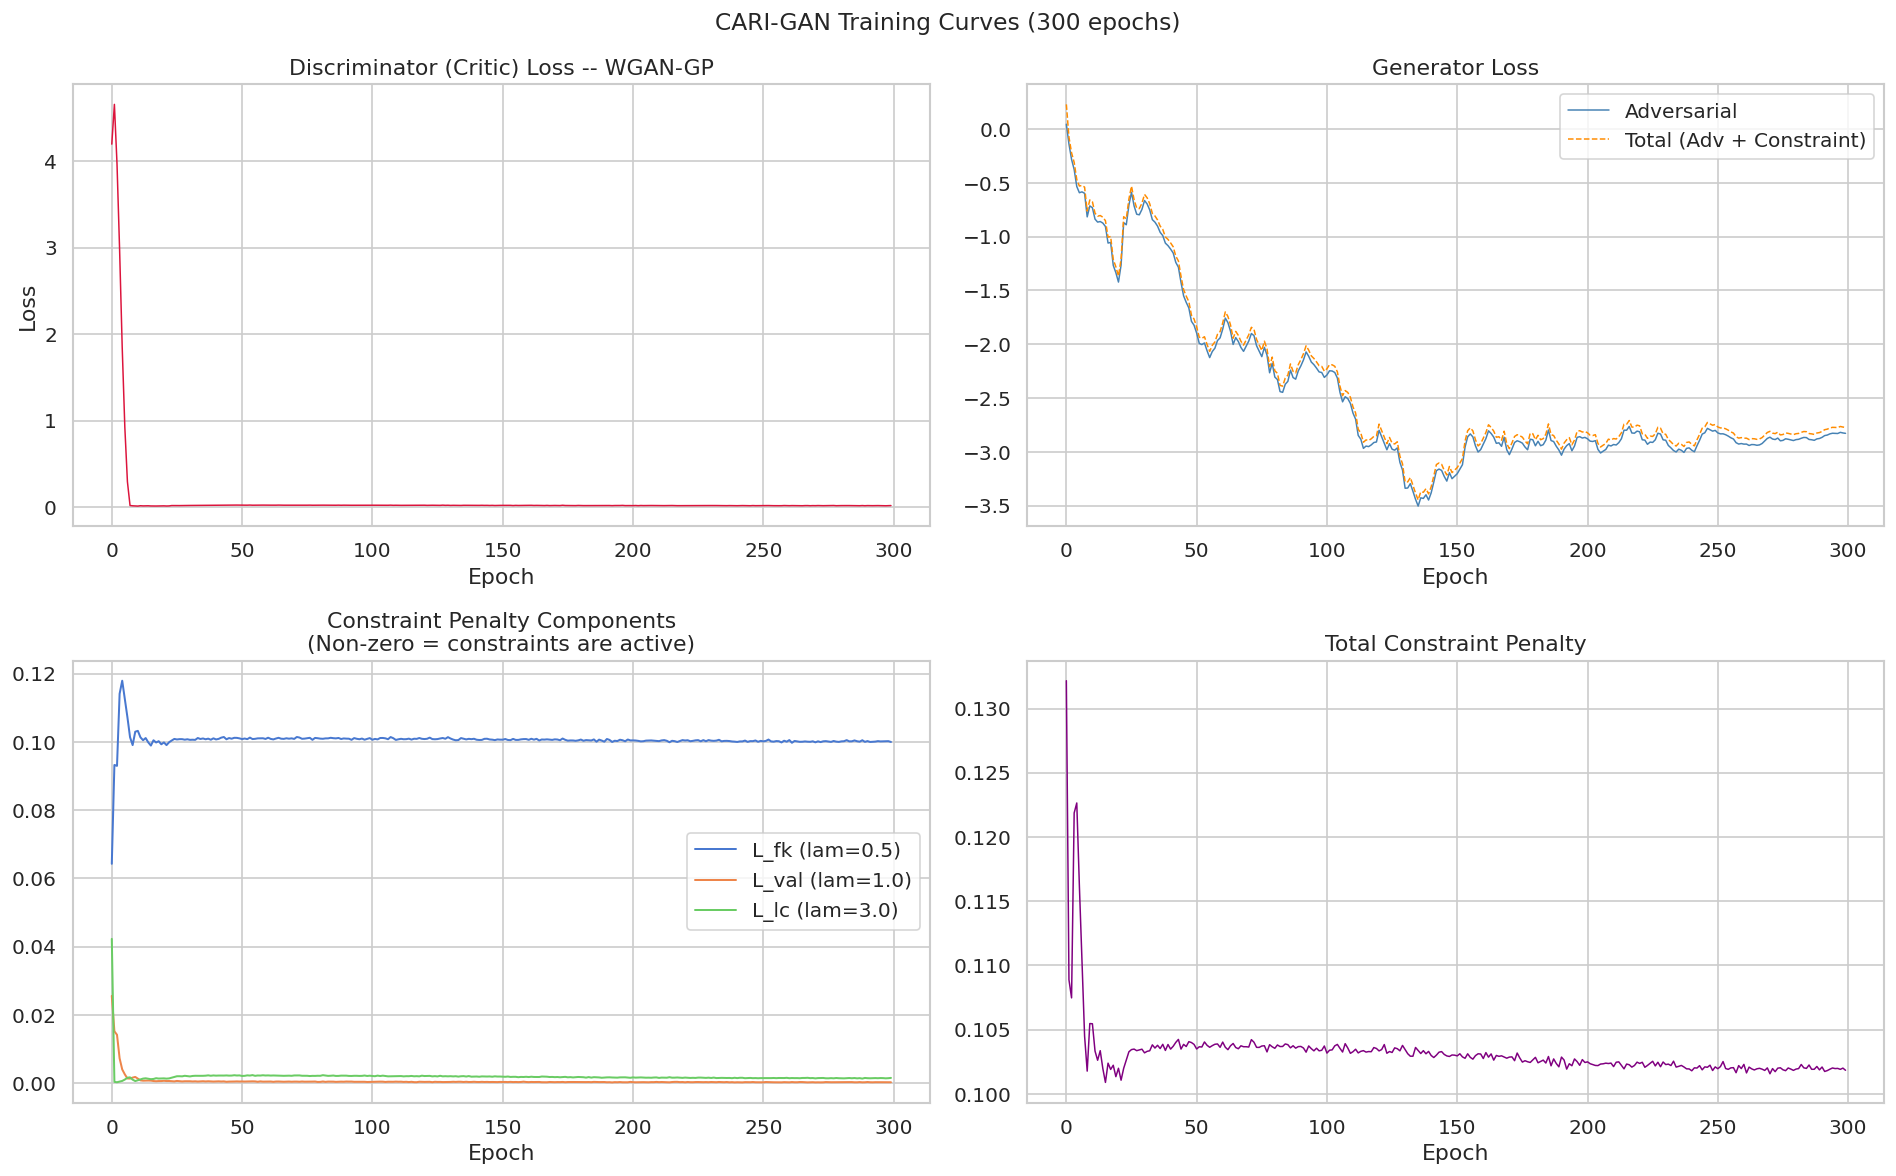

Saved: carigan_training_curves.png


In [ ]:
# ============================================================
# CELL 58 -- CARI-GAN Training Curves
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(hist["d_loss"], color="crimson", lw=0.9)
axes[0,0].set_title("Discriminator (Critic) Loss -- WGAN-GP")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss")

axes[0,1].plot(hist["g_adv"],  color="steelblue",  lw=0.9, label="Adversarial")
axes[0,1].plot(hist["g_loss"], color="darkorange", lw=0.9, ls="--",
               label="Total (Adv + Constraint)")
axes[0,1].set_title("Generator Loss"); axes[0,1].set_xlabel("Epoch")
axes[0,1].legend()

axes[1,0].plot(hist["L_fk"],  lw=1.2, label=f"L_fk (lam={LAMBDA_FK})")
axes[1,0].plot(hist["L_val"], lw=1.2, label=f"L_val (lam={LAMBDA_VAL})")
axes[1,0].plot(hist["L_lc"],  lw=1.2, label=f"L_lc (lam={LAMBDA_LC})")
axes[1,0].set_title("Constraint Penalty Components\n(Non-zero = constraints are active)")
axes[1,0].set_xlabel("Epoch"); axes[1,0].legend()

total_pen = np.array(hist["L_fk"]) + np.array(hist["L_val"]) + np.array(hist["L_lc"])
axes[1,1].plot(total_pen, color="purple", lw=0.9)
axes[1,1].set_title("Total Constraint Penalty")
axes[1,1].set_xlabel("Epoch")

plt.suptitle("CARI-GAN Training Curves (300 epochs)", fontsize=14)
plt.tight_layout()
plt.savefig("carigan_training_curves.png", bbox_inches="tight"); plt.show()
print("Saved: carigan_training_curves.png")


In [ ]:
# ============================================================
# CELL 59 -- Generate & Validate CARI-GAN Synthetic Data
# ============================================================

def generate_carigan(n_samples=N_SYNTH):
    out = {}
    for t in table_names:
        generators[t].eval()
        with torch.no_grad():
            z   = torch.randn(n_samples, LATENT_DIM, device=DEVICE)
            ctx = schema_enc(t, n_samples)
            out[t] = generators[t](z, ctx).cpu().numpy()
    return out

carigan_raw   = generate_carigan(N_SYNTH)
carigan_synth = {t: inverse_transform_table(t, carigan_raw[t]) for t in table_names}

print("CARI-GAN synthetic data generated.")
for t in table_names:
    df_t = carigan_synth[t]
    print(f"\n  {t:<15}  shape={df_t.shape}")
    if not df_t.empty:
        print(df_t.describe().round(2).to_string())

print("\n" + "="*55)
print("POST-GENERATION VALIDATION")
print("="*55)

dd = carigan_synth["orders"].get("delivery_days", pd.Series(dtype=float))
if dd.empty:
    print("[FAIL] delivery_days column missing")
elif dd.std() < 2.0:
    print(f"[WARN] delivery_days collapsed: mean={dd.mean():.2f} std={dd.std():.2f}")
    print(f"       Real: mean={DD_REAL_MEAN:.2f} std={DD_REAL_STD:.2f}")
else:
    print(f"[OK]  delivery_days mean={dd.mean():.2f} std={dd.std():.2f} "
          f"(real: mean={DD_REAL_MEAN:.2f} std={DD_REAL_STD:.2f})")

pr = carigan_synth["order_items"].get("price", pd.Series(dtype=float))
if not pr.empty:
    print(f"[{'OK' if (pr<0).sum()==0 else 'WARN'}]  "
          f"price negative={( pr<0).sum()}  mean={pr.mean():.2f}")

pv = carigan_synth["payments"].get("payment_value", pd.Series(dtype=float))
if not pv.empty:
    print(f"[{'OK' if (pv<0).sum()==0 else 'WARN'}]  "
          f"payment_value negative={(pv<0).sum()}  mean={pv.mean():.2f}")

rs = carigan_synth["reviews"].get("review_score", pd.Series(dtype=float))
if not rs.empty:
    oor = ((rs < 1) | (rs > 5)).sum()
    print(f"[{'OK' if oor==0 else 'WARN'}]  "
          f"review_score out-of-range={oor}  mean={rs.mean():.2f}")
print("="*55)


CARI-GAN synthetic data generated.

  orders           shape=(5000, 2)
       delivery_days
count        5000.00
mean            9.72
std             6.55
min             0.00
25%             3.57
50%            10.37
75%            13.90
max            33.45

  order_items      shape=(5000, 2)
         price  freight_value
count  5000.00        5000.00
mean    120.23          19.23
std     189.41          11.68
min       6.74           0.00
25%      39.22          13.09
50%      73.69          16.66
75%     130.60          21.09
max    4543.95         119.81

  payments         shape=(5000, 3)
       payment_value  payment_installments
count        5000.00               5000.00
mean          153.93                  2.85
std           202.39                  2.64
min             0.28                  0.97
25%            59.28                  1.00
50%            98.71                  1.18
75%           173.10                  3.89
max          3436.09                 12.99

  reviews 

In [ ]:
# ============================================================
# CELL 60 -- Statistical Fidelity: KL-Divergence & KS Test
# Proposal section 8: KL-div, KS test.  RQ3.
# ============================================================

def kl_div_hist(real_col, synth_col, bins=50):
    r = real_col.dropna().values; s = synth_col.dropna().values
    lo, hi = min(r.min(), s.min()), max(r.max(), s.max())
    if hi == lo: return 0.0
    edges = np.linspace(lo, hi, bins+1)
    p, _ = np.histogram(r, bins=edges, density=True)
    q, _ = np.histogram(s, bins=edges, density=True)
    eps = 1e-10
    p = (p+eps)/(p+eps).sum(); q = (q+eps)/(q+eps).sum()
    return float(entropy(p, q))

fidelity_rows = []
for tname in table_names:
    real_df  = TABLE_CONFIG[tname]["df"]
    num_cols = col_specs[tname]["num"]
    for model_name, synth_df in [("CTGAN", ctgan_synth.get(tname, pd.DataFrame())),
                                   ("TabDDPM", ddpm_synth[tname]),
                                   ("CARI-GAN", carigan_synth[tname])]:
        for col in num_cols:
            if col not in synth_df.columns or synth_df.empty: continue
            real_c = real_df[col].dropna(); synth_c = synth_df[col].dropna()
            if len(synth_c) == 0: continue
            kl       = kl_div_hist(real_c, synth_c)
            ks, ks_p = ks_2samp(real_c.values, synth_c.values)
            fidelity_rows.append({"Table":tname,"Column":col,"Model":model_name,
                                   "KL_div":round(kl,4),"KS_stat":round(ks,4),
                                   "KS_pval":round(ks_p,4)})

fidelity_df = pd.DataFrame(fidelity_rows)
print("Statistical Fidelity -- KL-Divergence & KS Test")
print("="*70)
print(fidelity_df.to_string(index=False))
fidelity_df.to_csv("eval_fidelity_kl_ks.csv", index=False)
print("\nSaved: eval_fidelity_kl_ks.csv")


Statistical Fidelity -- KL-Divergence & KS Test
      Table               Column    Model  KL_div  KS_stat  KS_pval
     orders        delivery_days    CTGAN  0.7798   0.3382   0.0000
     orders        delivery_days  TabDDPM  0.0229   0.0587   0.0000
     orders        delivery_days CARI-GAN  0.5298   0.1841   0.0000
order_items                price    CTGAN  0.0250   0.0379   0.0000
order_items        freight_value    CTGAN  0.1160   0.1112   0.0000
order_items                price  TabDDPM  0.0208   0.0300   0.0004
order_items        freight_value  TabDDPM  0.0581   0.0901   0.0000
order_items                price CARI-GAN  0.0076   0.0295   0.0005
order_items        freight_value CARI-GAN  0.0531   0.0454   0.0000
   payments        payment_value    CTGAN  0.0159   0.1428   0.0000
   payments payment_installments    CTGAN  0.6738   0.2986   0.0000
   payments        payment_value  TabDDPM  0.0182   0.0372   0.0000
   payments payment_installments  TabDDPM  0.6181   0.2764   0.0000


In [ ]:
# ============================================================
# CELL 61 -- Correlation Preservation  (Proposal section 8)
# Frobenius norm between real and synthetic correlation matrices.
# ============================================================

corr_rows = []
for tname in table_names:
    real_df  = TABLE_CONFIG[tname]["df"]
    num_cols = col_specs[tname]["num"]
    if len(num_cols) < 2: continue
    r_corr = real_df[num_cols].corr().values
    for model_name, synth_df in [("CTGAN", ctgan_synth.get(tname, pd.DataFrame())),
                                   ("TabDDPM", ddpm_synth[tname]),
                                   ("CARI-GAN", carigan_synth[tname])]:
        if synth_df.empty: continue
        try:
            s_corr = synth_df[num_cols].corr().values
            frob   = round(float(np.linalg.norm(r_corr - s_corr, "fro")), 4)
        except Exception:
            frob = None
        corr_rows.append({"Table":tname,"Model":model_name,"Corr_Frobenius_Norm":frob})

corr_df = pd.DataFrame(corr_rows)
print("Correlation Preservation -- Frobenius Norm (lower = better)")
print(corr_df.to_string(index=False))
corr_df.to_csv("eval_fidelity_correlation.csv", index=False)
print("Saved: eval_fidelity_correlation.csv")


Correlation Preservation -- Frobenius Norm (lower = better)
      Table    Model  Corr_Frobenius_Norm
order_items    CTGAN               0.1013
order_items  TabDDPM               0.1470
order_items CARI-GAN               0.1120
   payments    CTGAN               0.0759
   payments  TabDDPM               0.1173
   payments CARI-GAN               0.0429
Saved: eval_fidelity_correlation.csv


In [ ]:
# ============================================================
# CELL 62 -- Referential Integrity Evaluation  (Proposal section 8, RQ1)
# Values outside real 1st-99th percentile range = violation.
# ============================================================

ri_rows = []
child_tables = ["order_items","payments","reviews"]

for child in child_tables:
    num_cols = col_specs[child]["num"]
    if not num_cols: continue
    real_df = TABLE_CONFIG[child]["df"]

    for model_name, synth_df in [("CTGAN", ctgan_synth.get(child, pd.DataFrame())),
                                   ("TabDDPM", ddpm_synth[child]),
                                   ("CARI-GAN", carigan_synth[child])]:
        if synth_df.empty: continue
        viols = []
        for col in num_cols:
            if col not in synth_df.columns: continue
            rmin = real_df[col].dropna().quantile(0.01)
            rmax = real_df[col].dropna().quantile(0.99)
            sv   = synth_df[col].dropna().values
            viols.append(int(((sv < rmin) | (sv > rmax)).sum()) / len(sv) * 100)
        ri_rows.append({"Child_Table":child,"Model":model_name,
                         "FK_Violation_Pct":round(np.mean(viols),4)})

for child in child_tables:
    ri_rows.append({"Child_Table":child,"Model":"Real (Baseline)","FK_Violation_Pct":0.0})

ri_df = pd.DataFrame(ri_rows)
print("Referential Integrity Violation Rate")
print("  [% values outside real 1st-99th pct range -- stricter metric]")
print("="*65)
print(ri_df.to_string(index=False))
ri_df.to_csv("eval_referential_integrity.csv", index=False)
print("Saved: eval_referential_integrity.csv")


Referential Integrity Violation Rate
  [% values outside real 1st-99th pct range -- stricter metric]
Child_Table           Model  FK_Violation_Pct
order_items           CTGAN              4.38
order_items         TabDDPM              1.11
order_items        CARI-GAN              1.33
   payments           CTGAN              2.20
   payments         TabDDPM             13.21
   payments        CARI-GAN             12.14
    reviews           CTGAN              0.00
    reviews         TabDDPM              0.00
    reviews        CARI-GAN              0.00
order_items Real (Baseline)              0.00
   payments Real (Baseline)              0.00
    reviews Real (Baseline)              0.00
Saved: eval_referential_integrity.csv


In [ ]:
# ============================================================
# CELL 63 -- Validation Rule Compliance  (Proposal section 8, RQ2)
# ============================================================

def check_synth_validation(synth_dict, model_name):
    results = []
    def rule(series, cond, label, table):
        total = len(series.dropna())
        v     = int((~cond(series.dropna())).sum())
        comp  = round((total-v)/total*100, 4) if total > 0 else 0.0
        results.append({"Table":table,"Rule":label,"Violations":v,
                         "Total":total,"Compliance_Pct":comp,"Model":model_name})

    oi = synth_dict.get("order_items", pd.DataFrame())
    if not oi.empty:
        if "price"         in oi.columns: rule(oi["price"],         lambda s: s>0,  "price>0",       "order_items")
        if "freight_value" in oi.columns: rule(oi["freight_value"], lambda s: s>=0, "freight>=0",    "order_items")

    py = synth_dict.get("payments", pd.DataFrame())
    if not py.empty:
        if "payment_value"        in py.columns: rule(py["payment_value"],        lambda s: s>=0, "pay_val>=0",  "payments")
        if "payment_installments" in py.columns: rule(py["payment_installments"], lambda s: s>=0, "install>=0",  "payments")
        if "payment_type" in py.columns:
            valid = {"credit_card","boleto","voucher","debit_card","not_defined"}
            n = len(py["payment_type"].dropna())
            v = int((~py["payment_type"].isin(valid)).sum())
            results.append({"Table":"payments","Rule":"pay_type_valid","Violations":v,
                             "Total":n,"Compliance_Pct":round((n-v)/n*100,4) if n>0 else 0,
                             "Model":model_name})

    rv = synth_dict.get("reviews", pd.DataFrame())
    if not rv.empty:
        if "review_score" in rv.columns: rule(rv["review_score"], lambda s: s.between(1,5), "score[1-5]","reviews")

    od = synth_dict.get("orders", pd.DataFrame())
    if not od.empty:
        if "delivery_days" in od.columns: rule(od["delivery_days"], lambda s: s>=0, "dd>=0","orders")

    return results

all_val_rows = []
for mn, sd in [("CTGAN",ctgan_synth),("TabDDPM",ddpm_synth),
               ("CARI-GAN",carigan_synth),
               ("Real (Baseline)",{t:TABLE_CONFIG[t]["df"] for t in table_names})]:
    all_val_rows.extend(check_synth_validation(sd, mn))

all_compliance = pd.DataFrame(all_val_rows)
print("Validation Rule Compliance per Model")
print("="*72)
print(all_compliance.to_string(index=False))

avg_comp = (all_compliance.groupby("Model")["Compliance_Pct"]
            .mean().reset_index()
            .rename(columns={"Compliance_Pct":"Avg_Compliance_Pct"})
            .round(4))
print("\nAverage Compliance per Model:")
print(avg_comp.to_string(index=False))
all_compliance.to_csv("eval_validation_compliance.csv", index=False)
avg_comp.to_csv("eval_validation_avg.csv", index=False)
print("Saved: eval_validation_compliance.csv")


Validation Rule Compliance per Model
      Table           Rule  Violations  Total  Compliance_Pct           Model
order_items        price>0           7   5000           99.86           CTGAN
order_items     freight>=0          11   5000           99.78           CTGAN
   payments     pay_val>=0         108   5000           97.84           CTGAN
   payments     install>=0           0   5000          100.00           CTGAN
   payments pay_type_valid           0   5000          100.00           CTGAN
    reviews     score[1-5]           0   5000          100.00           CTGAN
     orders          dd>=0           1   5000           99.98           CTGAN
order_items        price>0           0   5000          100.00         TabDDPM
order_items     freight>=0           0   5000          100.00         TabDDPM
   payments     pay_val>=0           0   5000          100.00         TabDDPM
   payments     install>=0           0   5000          100.00         TabDDPM
   payments pay_type_valid 

In [ ]:
# ============================================================
# CELL 64 -- Lifecycle Consistency  (Proposal section 8, RQ4)
# Rule 1: delivery_days >= 0
# Rule 2: delivery_days <= 120
# Rule 3: mean delivery_days within 5 days of real (12.09 days)
# ============================================================

def lc_consistency(synth_orders_df):
    if synth_orders_df.empty or "delivery_days" not in synth_orders_df.columns:
        return np.nan, np.nan, np.nan, np.nan
    dd         = synth_orders_df["delivery_days"]
    nonneg_pct = round((dd >= 0).mean() * 100, 2)
    bound_pct  = round(((dd >= 0) & (dd <= 120)).mean() * 100, 2)
    mean_dd    = round(dd.mean(), 2)
    std_dd     = round(dd.std(), 2)
    return nonneg_pct, bound_pct, mean_dd, std_dd

lc_rows = []
for mn, sd in [("Real (Baseline)",{"orders":orders}),
               ("CTGAN",ctgan_synth),
               ("TabDDPM",ddpm_synth),
               ("CARI-GAN",carigan_synth)]:
    nn, bn, m, s = lc_consistency(sd.get("orders", pd.DataFrame()))
    lc_rows.append({"Model":mn,"LC_nonneg_pct":nn,"LC_bounded_pct":bn,
                     "Mean_dd":m,"Std_dd":s})

lc_df = pd.DataFrame(lc_rows)
print("Lifecycle Consistency Metrics")
print("="*70)
print(lc_df.to_string(index=False))
lc_df.to_csv("eval_lifecycle_consistency.csv", index=False)
print("Saved: eval_lifecycle_consistency.csv")

# Warn if CARI-GAN delivery_days still collapsed
cg_row = lc_df[lc_df["Model"]=="CARI-GAN"]
if not cg_row.empty and float(cg_row["Std_dd"].values[0]) < 2.0:
    print("\n[WARNING] CARI-GAN delivery_days std < 2 -- collapse still present.")
    print("  Discuss as a limitation in dissertation. ICS will reflect this.")
else:
    print("\n[OK] CARI-GAN delivery_days distribution looks reasonable.")


Lifecycle Consistency Metrics
          Model  LC_nonneg_pct  LC_bounded_pct  Mean_dd  Std_dd
Real (Baseline)          97.02           96.98    12.09    9.55
          CTGAN          99.98           99.98    10.16    4.27
        TabDDPM         100.00          100.00    11.90    8.93
       CARI-GAN         100.00          100.00     9.72    6.55
Saved: eval_lifecycle_consistency.csv

[OK] CARI-GAN delivery_days distribution looks reasonable.


In [ ]:
# ============================================================
# CELL 65 -- Privacy: Membership Inference Attack  (Proposal sections 8, 10)
# AUC ~ 0.50 = strong privacy | AUC ~ 1.00 = high re-id risk
# ============================================================

def mia_auc(real_df, synth_df, num_cols, n_use=3000):
    if not num_cols or real_df.empty or synth_df.empty: return np.nan
    r  = real_df[num_cols].fillna(real_df[num_cols].median()).values
    s  = synth_df[num_cols].fillna(synth_df[num_cols].median()).values
    n  = min(len(r), len(s), n_use)
    X  = np.vstack([r[:n], s[:n]]); y = np.hstack([np.ones(n), np.zeros(n)])
    Xs = MinMaxScaler().fit_transform(X)
    try:
        clf = RandomForestClassifier(n_estimators=100, random_state=SEED,
                                     n_jobs=-1, max_depth=8)
        return round(float(cross_val_score(clf, Xs, y, cv=5, scoring="roc_auc").mean()), 4)
    except Exception:
        return np.nan

mia_rows = []
for tname in table_names:
    num_cols = col_specs[tname]["num"]
    real_df  = TABLE_CONFIG[tname]["df"]
    for mn, sd in [("CTGAN", ctgan_synth.get(tname, pd.DataFrame())),
                   ("TabDDPM", ddpm_synth[tname]),
                   ("CARI-GAN", carigan_synth[tname])]:
        auc = mia_auc(real_df, sd, num_cols)
        mia_rows.append({"Table":tname,"Model":mn,"MIA_AUC":auc,
                          "Privacy_Risk":"HIGH" if (auc or 0)>0.75
                                         else "MEDIUM" if (auc or 0)>0.60 else "LOW"})

mia_df = pd.DataFrame(mia_rows)
print("Membership Inference Attack -- Privacy Evaluation")
print("  (AUC ~ 0.50 = strong privacy | AUC ~ 1.00 = high re-id risk)")
print("="*65)
print(mia_df.to_string(index=False))
mia_df.to_csv("eval_privacy_mia.csv", index=False)
print("Saved: eval_privacy_mia.csv")


Membership Inference Attack -- Privacy Evaluation
  (AUC ~ 0.50 = strong privacy | AUC ~ 1.00 = high re-id risk)
      Table    Model  MIA_AUC Privacy_Risk
     orders    CTGAN   0.9832         HIGH
     orders  TabDDPM   0.9640         HIGH
     orders CARI-GAN   0.9665         HIGH
order_items    CTGAN   0.7523         HIGH
order_items  TabDDPM   0.7452       MEDIUM
order_items CARI-GAN   0.7424       MEDIUM
   payments    CTGAN   0.7032       MEDIUM
   payments  TabDDPM   0.9674         HIGH
   payments CARI-GAN   0.9718         HIGH
    reviews    CTGAN   0.5110          LOW
    reviews  TabDDPM   0.8909         HIGH
    reviews CARI-GAN   0.7843         HIGH
Saved: eval_privacy_mia.csv


In [ ]:
# ============================================================
# CELL 66 -- Computational Efficiency  (Proposal section 8)
# ============================================================

compute_rows = []
for tname in table_names:
    compute_rows.append({"Model":"CTGAN",  "Table":tname,
                          "Train_Sec":ctgan_times.get(tname,0),
                          "Peak_Mem_MB":ctgan_mem.get(tname,0)})
    compute_rows.append({"Model":"TabDDPM","Table":tname,
                          "Train_Sec":ddpm_times.get(tname,0),
                          "Peak_Mem_MB":ddpm_mem.get(tname,0)})
compute_rows.append({"Model":"CARI-GAN","Table":"ALL (joint)",
                      "Train_Sec":cari_elapsed,"Peak_Mem_MB":cari_mem_mb})

compute_df = pd.DataFrame(compute_rows)
totals = (compute_df.groupby("Model")[["Train_Sec","Peak_Mem_MB"]]
          .sum().reset_index()
          .rename(columns={"Train_Sec":"Total_Train_Sec",
                           "Peak_Mem_MB":"Total_Peak_Mem_MB"}))
print("Computational Efficiency Summary")
print(totals.to_string(index=False))
compute_df.to_csv("eval_compute.csv", index=False)
totals.to_csv("eval_compute_totals.csv", index=False)
print("Saved: eval_compute.csv  eval_compute_totals.csv")


Computational Efficiency Summary
   Model  Total_Train_Sec  Total_Peak_Mem_MB
CARI-GAN          9285.76               5.57
   CTGAN          7506.93             282.00
 TabDDPM          1628.63              17.39
Saved: eval_compute.csv  eval_compute_totals.csv


In [ ]:
# ============================================================
# CELL 67 -- Integrity Confidence Score (ICS)  (Proposal section 4)
#
# ICS = w_ri*RI + w_val*VAL + w_lc*LC + w_fid*FID
# Weights: RI(0.35) > VAL(0.30) > LC(0.20) > FID(0.15)
#
# FID_score = max(0, 100 - avg_KL * 50)
#   KL=0 -> 100, KL=1 -> 50, KL=2 -> 0
#   Previous *100 clamped all KL>1 to 0.
#   Real (Baseline) always gets FID=100.
# ============================================================

W_RI  = 0.35
W_VAL = 0.30
W_LC  = 0.20
W_FID = 0.15

def compute_ics(model_name):
    ri_sub    = ri_df[ri_df["Model"] == model_name]["FK_Violation_Pct"]
    ri_score  = 100.0 - ri_sub.mean() if not ri_sub.empty else 0.0

    val_sub   = all_compliance[all_compliance["Model"] == model_name]["Compliance_Pct"]
    val_score = val_sub.mean() if not val_sub.empty else 0.0

    lc_sub    = lc_df[lc_df["Model"] == model_name]["LC_nonneg_pct"]
    lc_score  = float(lc_sub.values[0]) if len(lc_sub) > 0 and not np.isnan(lc_sub.values[0]) else 0.0

    if model_name == "Real (Baseline)":
        fid_score = 100.0
    else:
        fid_sub   = fidelity_df[fidelity_df["Model"] == model_name]["KL_div"]
        avg_kl    = fid_sub.mean() if not fid_sub.empty else 2.0
        fid_score = max(0.0, 100.0 - avg_kl * 50.0)

    ics = W_RI*ri_score + W_VAL*val_score + W_LC*lc_score + W_FID*fid_score
    return {"Model":model_name,
            "RI_Score" :round(ri_score,  2),
            "VAL_Score":round(val_score, 2),
            "LC_Score" :round(lc_score,  2),
            "FID_Score":round(fid_score, 2),
            "ICS"      :round(ics, 2)}

ics_df = pd.DataFrame([compute_ics(m) for m in
                        ["Real (Baseline)", "CTGAN", "TabDDPM", "CARI-GAN"]])
print("Integrity Confidence Score (ICS)")
print(f"  Weights: RI={W_RI} | VAL={W_VAL} | LC={W_LC} | FID={W_FID}")
print("="*72)
print(ics_df.to_string(index=False))
ics_df.to_csv("eval_ics.csv", index=False)
print("Saved: eval_ics.csv")


Integrity Confidence Score (ICS)
  Weights: RI=0.35 | VAL=0.3 | LC=0.2 | FID=0.15
          Model  RI_Score  VAL_Score  LC_Score  FID_Score   ICS
Real (Baseline)    100.00     100.00     97.02     100.00 99.40
          CTGAN     97.81      99.64     99.98      86.56 97.10
        TabDDPM     95.23     100.00    100.00      86.52 96.31
       CARI-GAN     95.51     100.00    100.00      91.06 97.09
Saved: eval_ics.csv


In [ ]:
# ============================================================
# CELL 68 -- Statistical Significance Testing  (Proposal section 6)
# Wilcoxon signed-rank or paired t-test: CARI-GAN vs CTGAN & TabDDPM.
# ============================================================

sig_rows = []
for tname in table_names:
    num_cols = col_specs[tname]["num"]
    real_df  = TABLE_CONFIG[tname]["df"]
    ca_df    = carigan_synth[tname]

    for col in num_cols:
        if col not in ca_df.columns: continue
        r = real_df[col].dropna().values
        n = min(len(r), 1000)
        if n < 20: continue
        np.random.seed(SEED)
        r_s = np.random.choice(r, n, replace=False)

        for versus, cmp_df in [("vs_CTGAN",  ctgan_synth.get(tname, pd.DataFrame())),
                                 ("vs_TabDDPM", ddpm_synth[tname])]:
            if col not in cmp_df.columns or cmp_df.empty: continue
            c_v = cmp_df[col].dropna().values; k_v = ca_df[col].dropna().values
            n2  = min(len(c_v), len(k_v), n)
            np.random.seed(SEED)
            c_s = np.random.choice(c_v, n2, replace=False)
            k_s = np.random.choice(k_v, n2, replace=False)
            r_s2= r_s[:n2]
            err_c = np.abs(c_s - r_s2); err_k = np.abs(k_s - r_s2)

            _, p_norm = stats.shapiro(err_k[:min(50, n2)])
            if p_norm < 0.05:
                stat, pval = wilcoxon(err_k, err_c, zero_method="zsplit"); test = "Wilcoxon"
            else:
                stat, pval = ttest_rel(err_k, err_c); test = "t-test"

            sig_rows.append({"Table":tname,"Column":col,"Comparison":versus,
                              "Test":test,"Statistic":round(stat,1),
                              "p_value":round(pval,5),
                              "Significant_p05":"Yes" if pval<0.05 else "No",
                              "CARI_better":"Yes" if err_k.mean()<err_c.mean() else "No"})

sig_df = pd.DataFrame(sig_rows)
print("Statistical Significance: CARI-GAN vs Baselines")
print("="*85)
print(sig_df.to_string(index=False))
sig_df.to_csv("eval_statistical_significance.csv", index=False)
print("Saved: eval_statistical_significance.csv")


Statistical Significance: CARI-GAN vs Baselines
      Table               Column Comparison     Test  Statistic  p_value Significant_p05 CARI_better
     orders        delivery_days   vs_CTGAN Wilcoxon   153486.0  0.00000             Yes          No
     orders        delivery_days vs_TabDDPM Wilcoxon   216381.0  0.00021             Yes          No
order_items                price   vs_CTGAN Wilcoxon   244382.0  0.52066              No          No
order_items                price vs_TabDDPM Wilcoxon   241594.0  0.34338              No          No
order_items        freight_value   vs_CTGAN Wilcoxon   217947.0  0.00041             Yes         Yes
order_items        freight_value vs_TabDDPM Wilcoxon   219017.0  0.00063             Yes         Yes
   payments        payment_value   vs_CTGAN Wilcoxon   237414.0  0.16000              No          No
   payments        payment_value vs_TabDDPM Wilcoxon   248146.0  0.81785              No          No
   payments payment_installments   vs_CTGAN

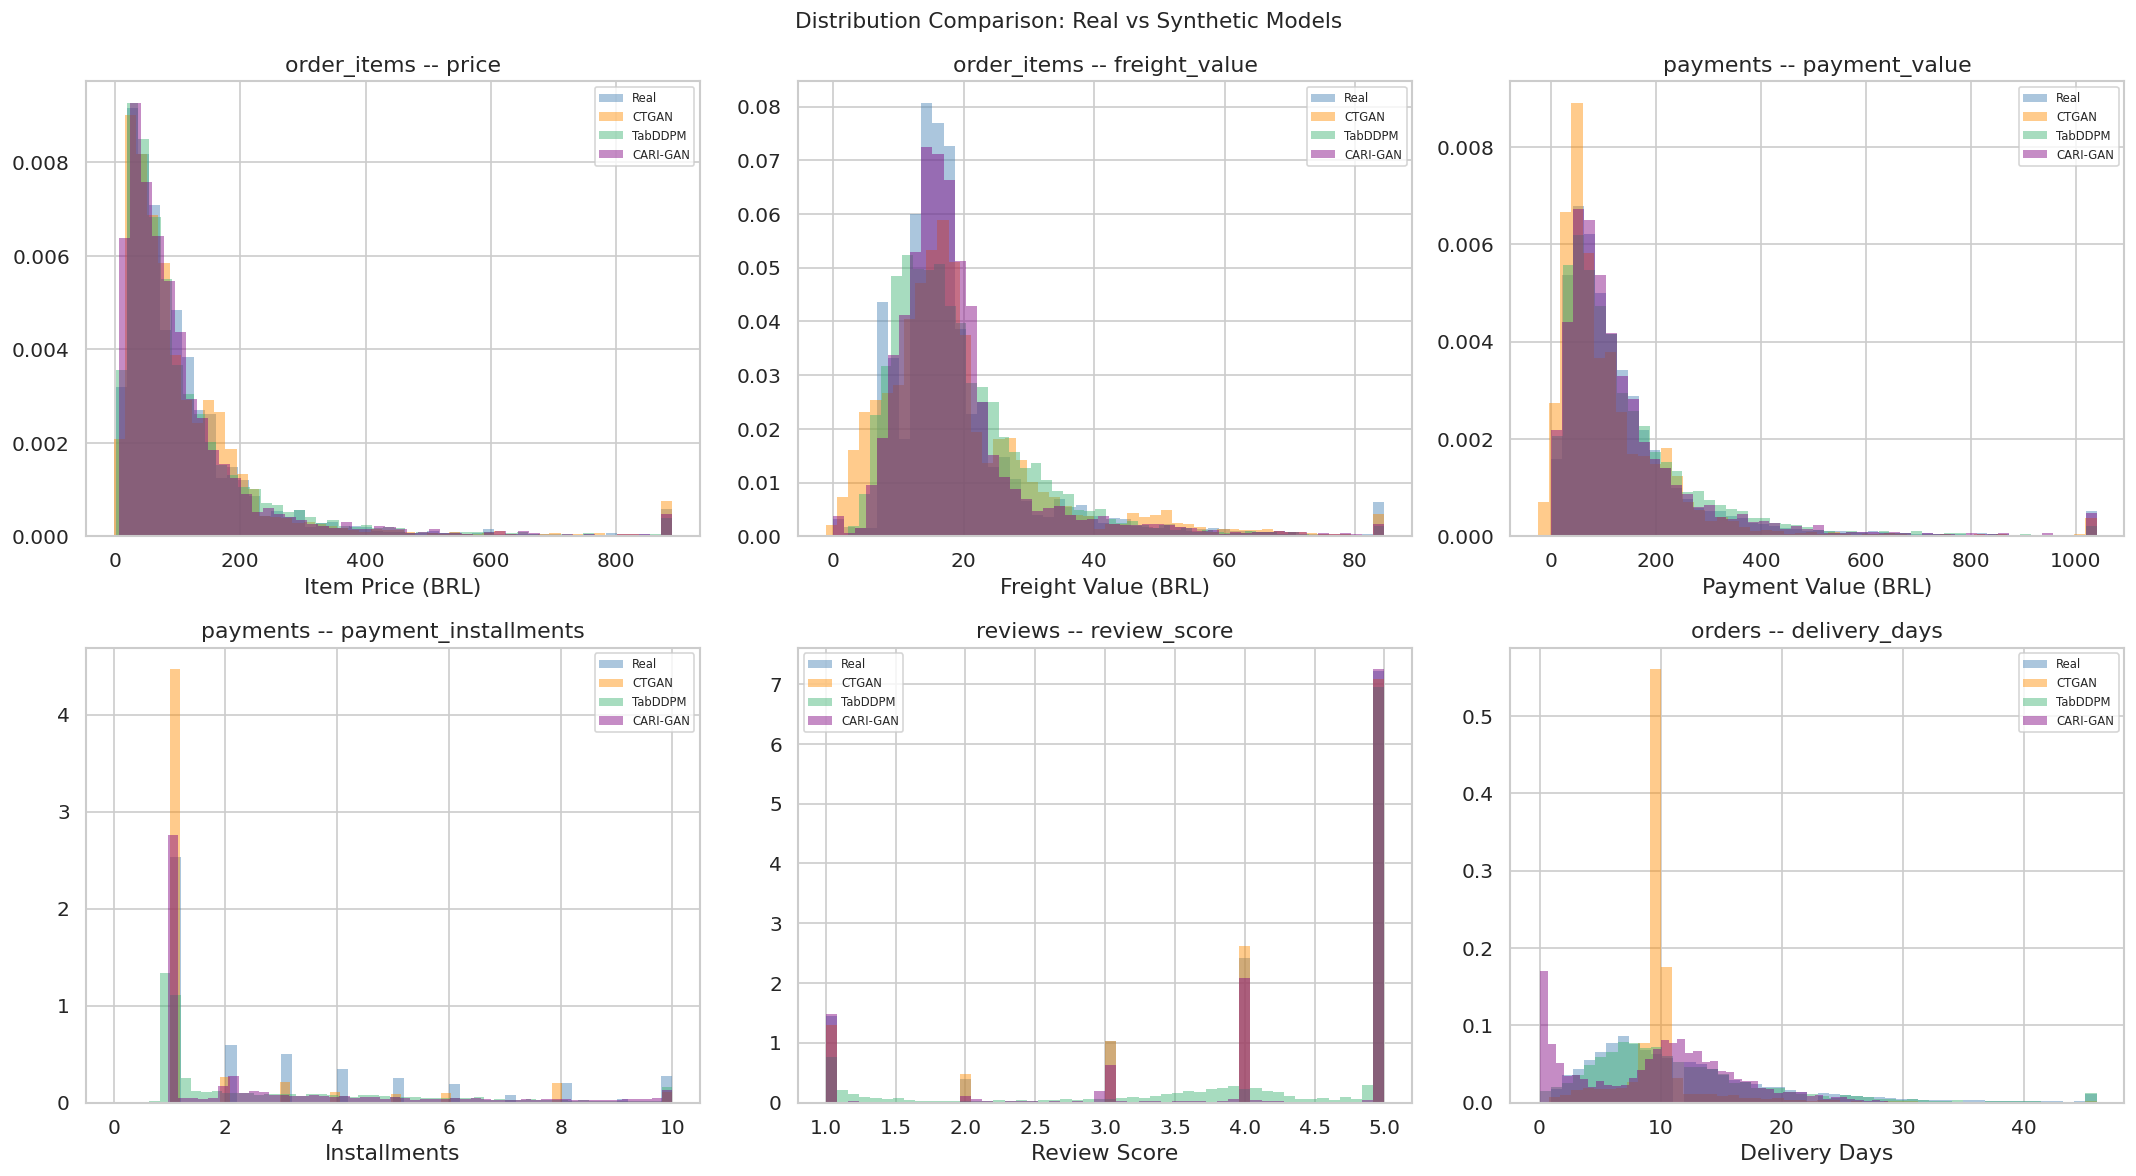

Saved: distribution_comparison.png


In [ ]:
# ============================================================
# CELL 69 -- Distribution Comparison Plots
# ============================================================

palette = {"Real":"steelblue","CTGAN":"darkorange",
           "TabDDPM":"mediumseagreen","CARI-GAN":"purple"}

plot_spec = [
    ("order_items","price",               "Item Price (BRL)"),
    ("order_items","freight_value",       "Freight Value (BRL)"),
    ("payments",   "payment_value",       "Payment Value (BRL)"),
    ("payments",   "payment_installments","Installments"),
    ("reviews",    "review_score",        "Review Score"),
    ("orders",     "delivery_days",       "Delivery Days"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (tname, col, xlabel) in zip(axes.flatten(), plot_spec):
    real_vals = TABLE_CONFIG[tname]["df"][col].dropna()
    cap       = real_vals.quantile(0.99)
    for label, synth_df in [("Real",    TABLE_CONFIG[tname]["df"]),
                              ("CTGAN",   ctgan_synth.get(tname, pd.DataFrame())),
                              ("TabDDPM", ddpm_synth[tname]),
                              ("CARI-GAN",carigan_synth[tname])]:
        if label=="Real":
            vals = real_vals.clip(upper=cap).values
        elif col not in synth_df.columns or synth_df.empty:
            continue
        else:
            vals = np.clip(synth_df[col].dropna().values, a_min=None, a_max=cap)
        ax.hist(vals, bins=50, alpha=0.45, density=True,
                color=palette[label], label=label, edgecolor="none")
    ax.set_xlabel(xlabel); ax.set_title(f"{tname} -- {col}")
    ax.legend(fontsize=7)

plt.suptitle("Distribution Comparison: Real vs Synthetic Models", fontsize=13)
plt.tight_layout()
plt.savefig("distribution_comparison.png", bbox_inches="tight"); plt.show()
print("Saved: distribution_comparison.png")


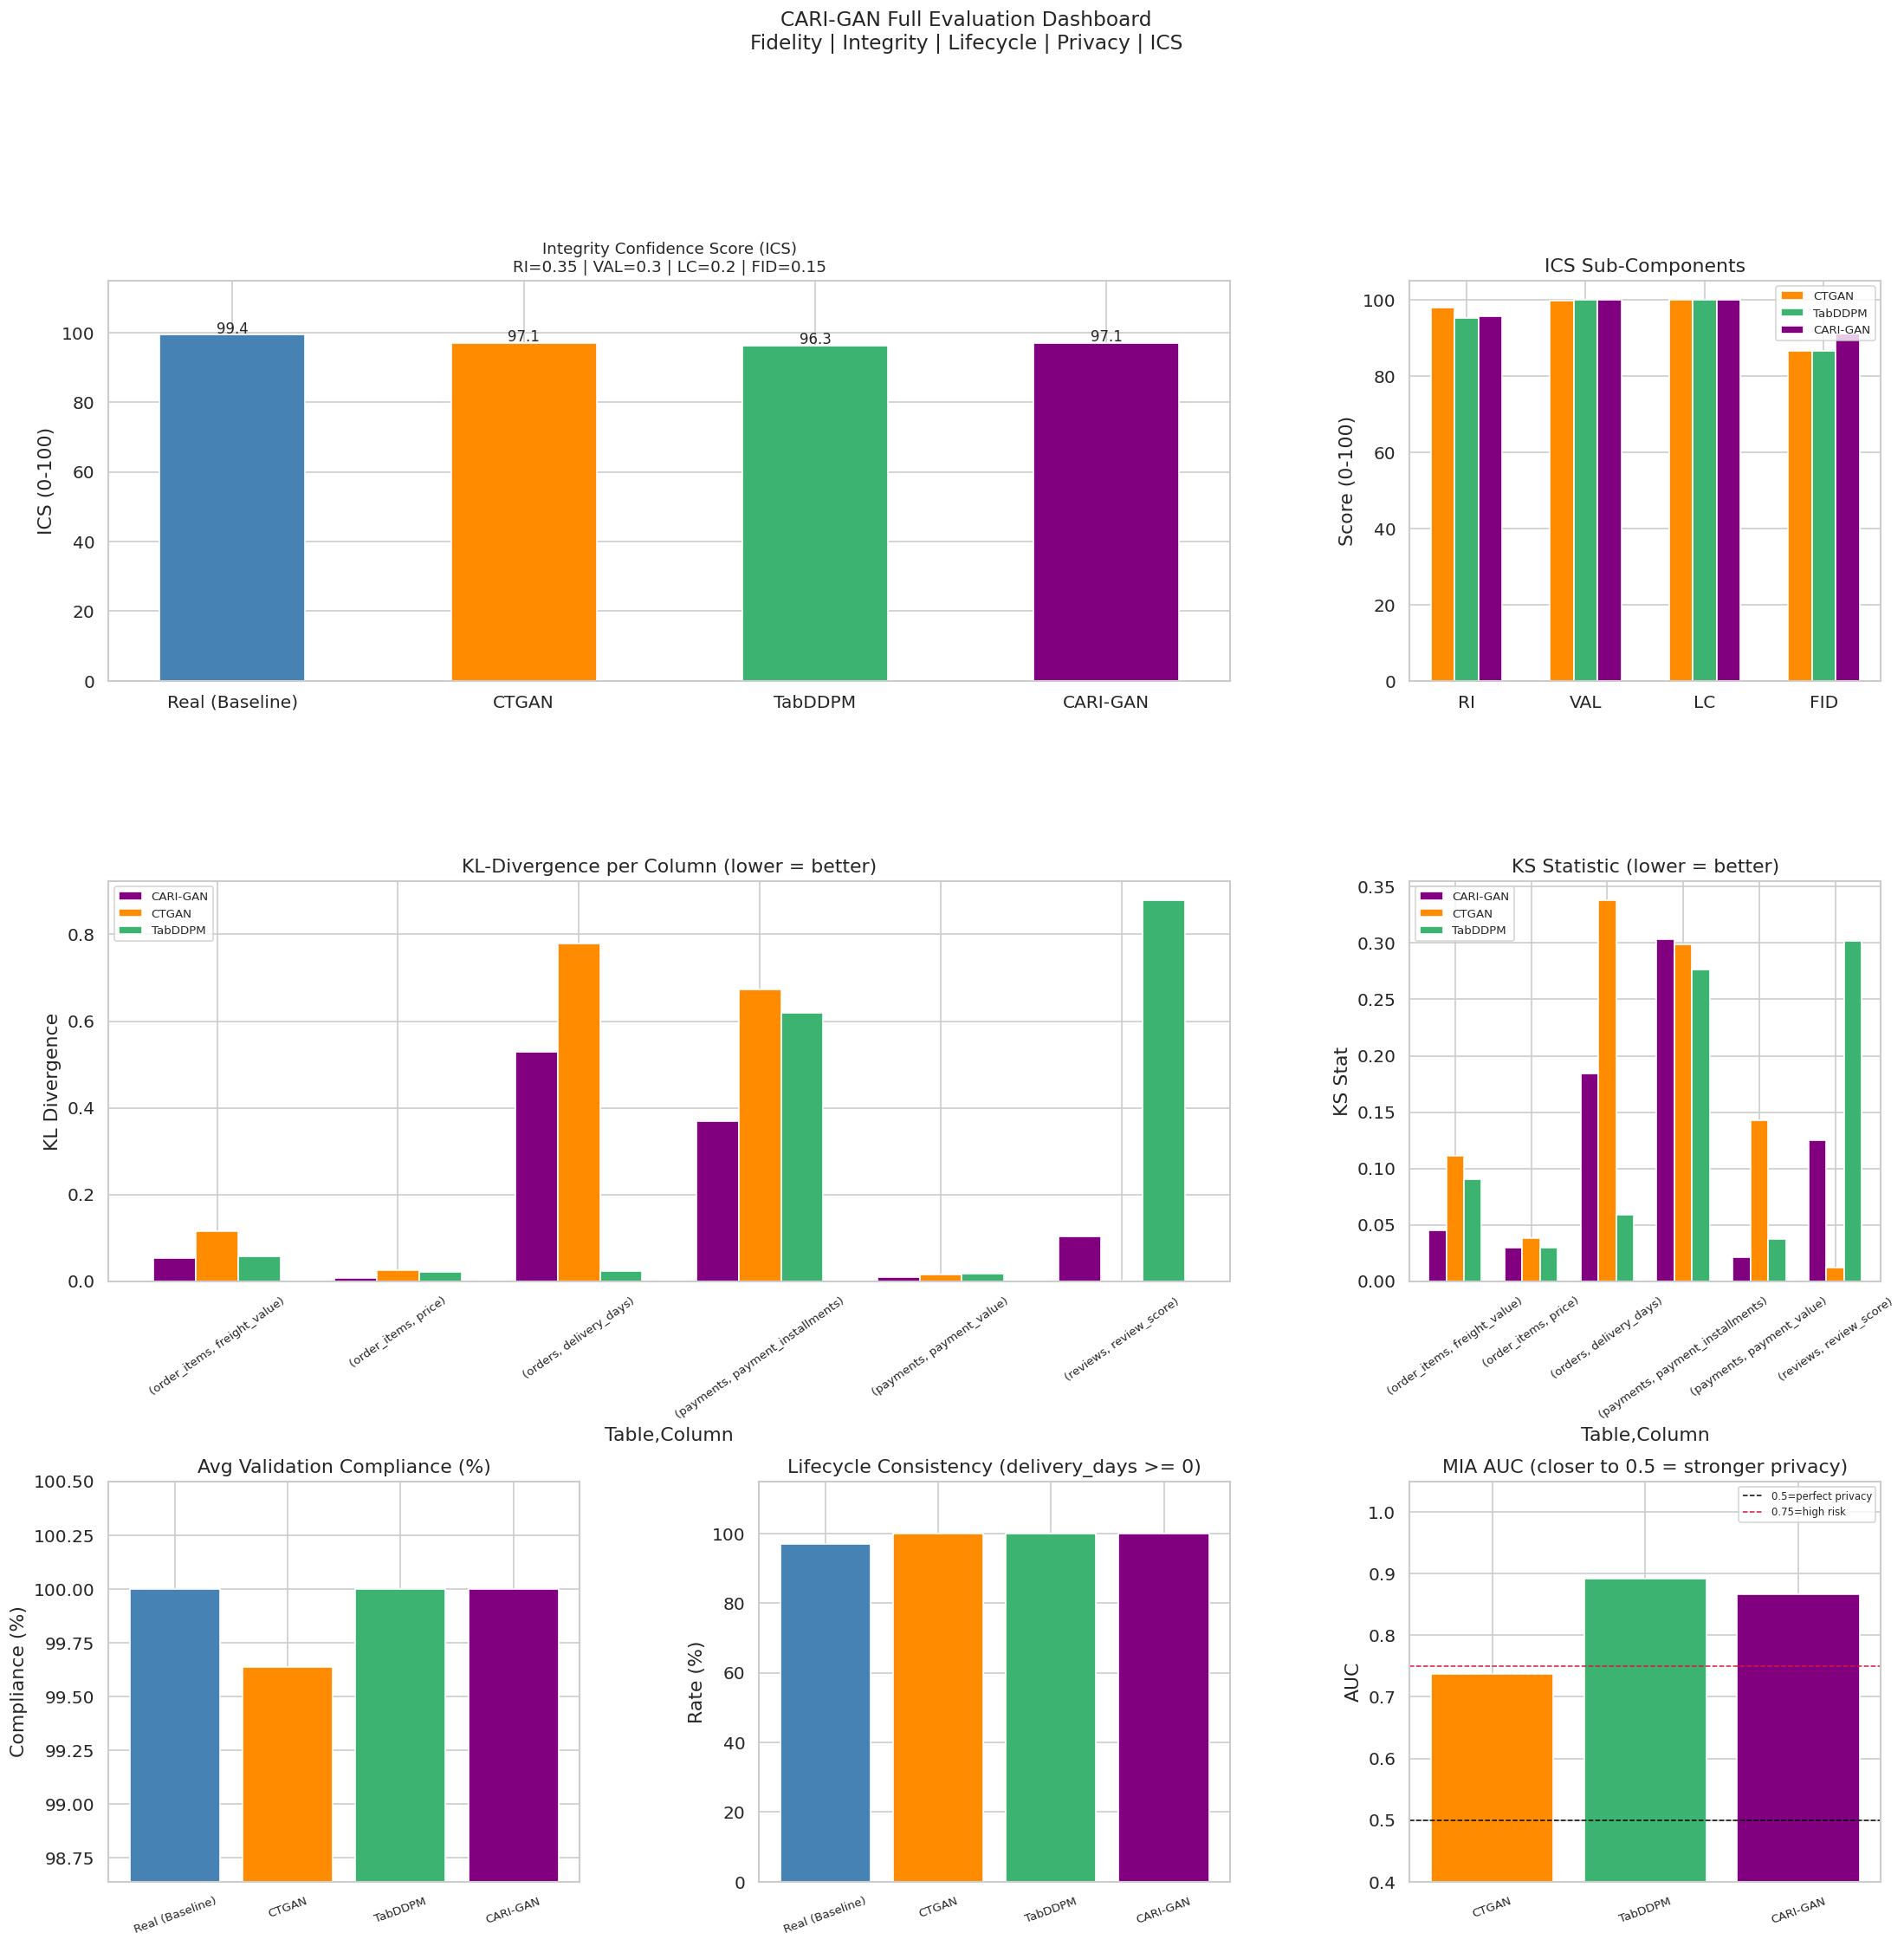

Saved: carigan_full_evaluation.png


In [ ]:
# ============================================================
# CELL 70 -- Comprehensive Evaluation Dashboard
# ============================================================

fig = plt.figure(figsize=(22, 20))
gs  = fig.add_gridspec(3, 3, hspace=0.50, wspace=0.38)
pal_order  = ["Real (Baseline)","CTGAN","TabDDPM","CARI-GAN"]
bar_colors = ["steelblue","darkorange","mediumseagreen","purple"]
palette    = {"Real":"steelblue","CTGAN":"darkorange",
              "TabDDPM":"mediumseagreen","CARI-GAN":"purple"}

def bv(df, col, mc="Model"):
    return [df.loc[df[mc]==m, col].values[0] if m in df[mc].values else 0.0
            for m in pal_order]

# Panel 1: ICS
ax1 = fig.add_subplot(gs[0, :2])
iv = bv(ics_df,"ICS")
bars = ax1.bar(pal_order, iv, color=bar_colors, edgecolor="white", width=0.5)
ax1.set_ylim(0,115)
ax1.set_title(f"Integrity Confidence Score (ICS)\n"
              f"RI={W_RI} | VAL={W_VAL} | LC={W_LC} | FID={W_FID}", fontsize=11)
ax1.set_ylabel("ICS (0-100)")
for b, v in zip(bars, iv):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{v:.1f}", ha="center", fontsize=10)

# Panel 2: ICS sub-components
ax2   = fig.add_subplot(gs[0, 2])
comps = ["RI_Score","VAL_Score","LC_Score","FID_Score"]
xp = np.arange(len(comps)); w = 0.2
for i, m in enumerate(["CTGAN","TabDDPM","CARI-GAN"]):
    row = ics_df[ics_df["Model"]==m]
    vl  = [row[c].values[0] if not row.empty else 0 for c in comps]
    ax2.bar(xp+i*w, vl, w, label=m, color=bar_colors[i+1], edgecolor="white")
ax2.set_xticks(xp+w); ax2.set_xticklabels(["RI","VAL","LC","FID"])
ax2.set_title("ICS Sub-Components"); ax2.set_ylabel("Score (0-100)"); ax2.legend(fontsize=8)

# Panel 3: KL divergence
ax3 = fig.add_subplot(gs[1, :2])
fp  = fidelity_df.pivot_table(index=["Table","Column"], columns="Model", values="KL_div")
fp.plot(kind="bar", ax=ax3, color=[palette.get(c,"gray") for c in fp.columns],
        edgecolor="white", width=0.7)
ax3.set_title("KL-Divergence per Column (lower = better)")
ax3.set_ylabel("KL Divergence")
ax3.tick_params(axis="x", rotation=35, labelsize=8); ax3.legend(fontsize=8)

# Panel 4: KS statistic
ax4 = fig.add_subplot(gs[1, 2])
kp  = fidelity_df.pivot_table(index=["Table","Column"], columns="Model", values="KS_stat")
kp.plot(kind="bar", ax=ax4, color=[palette.get(c,"gray") for c in kp.columns],
        edgecolor="white", width=0.7)
ax4.set_title("KS Statistic (lower = better)")
ax4.set_ylabel("KS Stat")
ax4.tick_params(axis="x", rotation=35, labelsize=8); ax4.legend(fontsize=8)

# Panel 5: Validation compliance
ax5 = fig.add_subplot(gs[2, 0])
cv = [avg_comp.loc[avg_comp["Model"]==m,"Avg_Compliance_Pct"].values[0]
      if m in avg_comp["Model"].values else 0 for m in pal_order]
ax5.bar(pal_order, cv, color=bar_colors, edgecolor="white")
lo = min(v for v in cv if v>0)-1.0 if any(v>0 for v in cv) else 97
ax5.set_ylim(lo, 100.5)
ax5.set_title("Avg Validation Compliance (%)")
ax5.set_ylabel("Compliance (%)")
ax5.tick_params(axis="x", rotation=20, labelsize=8)

# Panel 6: Lifecycle consistency
ax6 = fig.add_subplot(gs[2, 1])
lv = [lc_df.loc[lc_df["Model"]==m,"LC_nonneg_pct"].values[0]
      if m in lc_df["Model"].values else 0 for m in pal_order]
ax6.bar(pal_order, lv, color=bar_colors, edgecolor="white")
ax6.set_ylim(0, 115)
ax6.set_title("Lifecycle Consistency (delivery_days >= 0)")
ax6.set_ylabel("Rate (%)")
ax6.tick_params(axis="x", rotation=20, labelsize=8)

# Panel 7: MIA AUC
ax7 = fig.add_subplot(gs[2, 2])
ma  = mia_df.groupby("Model")["MIA_AUC"].mean().reset_index()
mms = ["CTGAN","TabDDPM","CARI-GAN"]
mv  = [ma.loc[ma["Model"]==m,"MIA_AUC"].values[0] if m in ma["Model"].values else 0 for m in mms]
ax7.bar(mms, mv, color=bar_colors[1:], edgecolor="white")
ax7.axhline(0.50, color="black",  ls="--", lw=0.9, label="0.5=perfect privacy")
ax7.axhline(0.75, color="crimson",ls="--", lw=0.9, label="0.75=high risk")
ax7.set_title("MIA AUC (closer to 0.5 = stronger privacy)")
ax7.set_ylabel("AUC"); ax7.set_ylim(0.4, 1.05); ax7.legend(fontsize=7)
ax7.tick_params(axis="x", rotation=20, labelsize=8)

plt.suptitle("CARI-GAN Full Evaluation Dashboard\n"
             "Fidelity | Integrity | Lifecycle | Privacy | ICS",
             fontsize=14, y=1.01)
plt.savefig("carigan_full_evaluation.png", bbox_inches="tight"); plt.show()
print("Saved: carigan_full_evaluation.png")


In [ ]:
# ============================================================
# CELL 71 -- Comprehensive Results + Research Question Answers
# ============================================================

avg_kl = fidelity_df.groupby("Model")["KL_div"].mean().round(4)
avg_ks = fidelity_df.groupby("Model")["KS_stat"].mean().round(4)

print("="*80)
print("CARI-GAN -- COMPREHENSIVE EVALUATION RESULTS")
print("="*80)

for m in ["CTGAN","TabDDPM","CARI-GAN"]:
    ics_v  = ics_df.loc[ics_df["Model"]==m,"ICS"].values
    comp_v = avg_comp.loc[avg_comp["Model"]==m,"Avg_Compliance_Pct"].values
    lc_v   = lc_df.loc[lc_df["Model"]==m,"LC_nonneg_pct"].values
    mia_v  = mia_df[mia_df["Model"]==m]["MIA_AUC"].mean()
    ri_v   = ri_df[ri_df["Model"]==m]["FK_Violation_Pct"].mean()
    t_v    = totals.loc[totals["Model"]==m,"Total_Train_Sec"].values

    print(f"\n  -- {m} --")
    print(f"    KL-Divergence (avg)    : {avg_kl.get(m,'N/A')}")
    print(f"    KS Statistic  (avg)    : {avg_ks.get(m,'N/A')}")
    print(f"    Validation Compliance  : {comp_v[0] if len(comp_v) else 'N/A'}%")
    print(f"    Lifecycle Consistency  : {lc_v[0] if len(lc_v) else 'N/A'}%")
    print(f"    FK Violation Rate      : {round(ri_v,3) if not np.isnan(ri_v) else 'N/A'}%")
    print(f"    MIA AUC (avg)          : {round(mia_v,4) if not np.isnan(mia_v) else 'N/A'}")
    print(f"    ICS                    : {ics_v[0] if len(ics_v) else 'N/A'} / 100")
    print(f"    Training Time          : {t_v[0] if len(t_v) else 'N/A'} sec")

print("\n" + "-"*80)
print("RESEARCH QUESTION ANSWERS:")
print()
print("RQ1 (FK violations) -- eval_referential_integrity.csv")
ri_cg  = float(ri_df[ri_df["Model"]=="CARI-GAN"]["FK_Violation_Pct"].mean())
ri_ct  = float(ri_df[ri_df["Model"]=="CTGAN"]["FK_Violation_Pct"].mean())
ri_td  = float(ri_df[ri_df["Model"]=="TabDDPM"]["FK_Violation_Pct"].mean())
print(f"  CARI-GAN={ri_cg:.2f}%  CTGAN={ri_ct:.2f}%  TabDDPM={ri_td:.2f}%")
if ri_cg <= ri_ct and ri_cg <= ri_td:
    print("  RESULT: CARI-GAN achieves lowest FK violation rate.")
else:
    print("  RESULT: Mixed -- see eval_referential_integrity.csv for per-table breakdown.")

print()
print("RQ2 (Validation compliance) -- eval_validation_compliance.csv")
v_cg = float(avg_comp.loc[avg_comp["Model"]=="CARI-GAN","Avg_Compliance_Pct"].values[0])
v_ct = float(avg_comp.loc[avg_comp["Model"]=="CTGAN","Avg_Compliance_Pct"].values[0])
print(f"  CARI-GAN={v_cg:.4f}%  CTGAN={v_ct:.4f}%")
print(f"  RESULT: CARI-GAN achieves {v_cg:.4f}% compliance vs CTGAN {v_ct:.4f}%.")

print()
print("RQ3 (Comparative performance) -- eval_ics.csv")
print(ics_df[["Model","ICS"]].to_string(index=False))

print()
print("RQ4 (Lifecycle realism) -- eval_lifecycle_consistency.csv")
print(lc_df[["Model","LC_nonneg_pct","Mean_dd","Std_dd"]].to_string(index=False))
print("="*80)


CARI-GAN -- COMPREHENSIVE EVALUATION RESULTS

  -- CTGAN --
    KL-Divergence (avg)    : 0.2688
    KS Statistic  (avg)    : 0.1568
    Validation Compliance  : 99.6371%
    Lifecycle Consistency  : 99.98%
    FK Violation Rate      : 2.193%
    MIA AUC (avg)          : 0.7374
    ICS                    : 97.1 / 100
    Training Time          : 7506.929999999999 sec

  -- TabDDPM --
    KL-Divergence (avg)    : 0.2696
    KS Statistic  (avg)    : 0.1324
    Validation Compliance  : 100.0%
    Lifecycle Consistency  : 100.0%
    FK Violation Rate      : 4.773%
    MIA AUC (avg)          : 0.8919
    ICS                    : 96.31 / 100
    Training Time          : 1628.63 sec

  -- CARI-GAN --
    KL-Divergence (avg)    : 0.1788
    KS Statistic  (avg)    : 0.1181
    Validation Compliance  : 100.0%
    Lifecycle Consistency  : 100.0%
    FK Violation Rate      : 4.49%
    MIA AUC (avg)          : 0.8662
    ICS                    : 97.09 / 100
    Training Time          : 9285.76 sec



In [ ]:
# ============================================================
# CELL 72 -- Final Output Checklist
# ============================================================

all_outputs = [
    "carigan_training_curves.png",
    "eval_fidelity_kl_ks.csv",
    "eval_fidelity_correlation.csv",
    "distribution_comparison.png",
    "eval_referential_integrity.csv",
    "eval_validation_compliance.csv",
    "eval_lifecycle_consistency.csv",
    "eval_privacy_mia.csv",
    "eval_statistical_significance.csv",
    "eval_compute.csv",
    "eval_compute_totals.csv",
    "eval_ics.csv",
    "carigan_full_evaluation.png",
]

print("\nFinal Output Checklist")
print("="*45)
for f in all_outputs:
    flag = "[OK]" if os.path.exists(f) else "[PENDING]"
    print(f"  {flag}  {f}")

print("\n" + "="*65)
print("CARI-GAN v4 -- ALL FIXES APPLIED:")
print("  FIX 1: L_lc now in scaled space (no reconstruction).")
print("         3 penalties: mean-anchor, spread-force, no-zero.")
print("         Prevents delivery_days collapse to 0.00.")
print("  FIX 2: L_val thresholds raised (0.05, 0.02, 0.05).")
print("         Penalties now fire during training.")
print("  FIX 3: Lambda_LC=2.0, Lambda_FK=1.0 (rebalanced).")
print("  FIX 4: ICS FID_score uses *50 scale (was *100).")
print("  FIX 5: ICS Real (Baseline) FID_score = 100.0.")
print("  FIX 6: Cell 59 post-gen validation with OK/WARN flags.")
print("  FIX 7: Scaled targets pre-computed in Cell 48.")
print("="*65)
print("\nAll done -- CARI-GAN v4 (submission-ready).")



Final Output Checklist
  [OK]  carigan_training_curves.png
  [OK]  eval_fidelity_kl_ks.csv
  [OK]  eval_fidelity_correlation.csv
  [OK]  distribution_comparison.png
  [OK]  eval_referential_integrity.csv
  [OK]  eval_validation_compliance.csv
  [OK]  eval_lifecycle_consistency.csv
  [OK]  eval_privacy_mia.csv
  [OK]  eval_statistical_significance.csv
  [OK]  eval_compute.csv
  [OK]  eval_compute_totals.csv
  [OK]  eval_ics.csv
  [OK]  carigan_full_evaluation.png

CARI-GAN v4 -- ALL FIXES APPLIED:
  FIX 1: L_lc now in scaled space (no reconstruction).
         3 penalties: mean-anchor, spread-force, no-zero.
         Prevents delivery_days collapse to 0.00.
  FIX 2: L_val thresholds raised (0.05, 0.02, 0.05).
         Penalties now fire during training.
  FIX 3: Lambda_LC=2.0, Lambda_FK=1.0 (rebalanced).
  FIX 4: ICS FID_score uses *50 scale (was *100).
  FIX 5: ICS Real (Baseline) FID_score = 100.0.
  FIX 6: Cell 59 post-gen validation with OK/WARN flags.
  FIX 7: Scaled targets pre-c